In [31]:
from pathlib import Path
import requests

OUT_DIR = Path("./pm25_raw")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def download_year(year: int):
    # AQS daily files are typically named like: daily_88101_2010.zip
    url_zip = f"https://aqs.epa.gov/aqsweb/airdata/daily_88101_{year}.zip"
    out_zip = OUT_DIR / f"daily_88101_{year}.zip"

    if out_zip.exists() and out_zip.stat().st_size > 0:
        print(f"skip {year} (exists)")
        return

    print(f"downloading {year}: {url_zip}")
    r = requests.get(url_zip, stream=True, timeout=180)
    r.raise_for_status()

    with open(out_zip, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

for y in range(2010, 2024):
    download_year(y)


skip 2010 (exists)
skip 2011 (exists)
skip 2012 (exists)
skip 2013 (exists)
skip 2014 (exists)
skip 2015 (exists)
skip 2016 (exists)
skip 2017 (exists)
skip 2018 (exists)
skip 2019 (exists)
skip 2020 (exists)
skip 2021 (exists)
skip 2022 (exists)
skip 2023 (exists)


In [32]:
import zipfile
import pandas as pd
from pathlib import Path
import re

RAW_DIR = Path("./pm25_raw")
OUT_DIR = Path("./pm25_out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_COUNTY = OUT_DIR / "pm25_county_month_year_2010_2023.csv"
OUT_STATE  = OUT_DIR / "pm25_state_month_year_2010_2023.csv"

def pick_col(cols, candidates):
    norm = {}
    for c in cols:
        k = re.sub(r"[^a-z0-9]+", " ", str(c).strip().lower()).strip()
        norm[k] = c
    for cand in candidates:
        ck = re.sub(r"[^a-z0-9]+", " ", cand.strip().lower()).strip()
        if ck in norm:
            return norm[ck]
    return None

def parse_date_series(s: pd.Series) -> pd.Series:
    x = s.astype(str).str.strip()
    out = pd.Series(pd.NaT, index=x.index)

    m8 = x.str.fullmatch(r"\d{8}", na=False)
    if m8.any():
        out.loc[m8] = pd.to_datetime(x.loc[m8], format="%Y%m%d", errors="coerce")

    mdash = (~m8) & x.str.contains("-", na=False)
    if mdash.any():
        out.loc[mdash] = pd.to_datetime(x.loc[mdash], format="%Y-%m-%d", errors="coerce")

    mslash = (~m8) & (~mdash) & x.str.contains("/", na=False)
    if mslash.any():
        out.loc[mslash] = pd.to_datetime(x.loc[mslash], format="%m/%d/%Y", errors="coerce")

    mrest = out.isna() & x.ne("nan")
    if mrest.any():
        out.loc[mrest] = pd.to_datetime(x.loc[mrest], errors="coerce")

    return out

def read_and_normalize_zip(zip_path: Path) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path, "r") as z:
        csv_names = [n for n in z.namelist() if n.lower().endswith(".csv")]
        if not csv_names:
            raise ValueError(f"No CSV inside {zip_path}")
        name = csv_names[0]
        with z.open(name) as f:
            df = pd.read_csv(f, low_memory=False)

    df.columns = [c.strip() for c in df.columns]
    df["_source"] = zip_path.name

    date_col = pick_col(df.columns, ["Date Local", "date_local", "date local"])
    state_code_col = pick_col(df.columns, ["State Code", "state code", "state_code"])
    county_code_col = pick_col(df.columns, ["County Code", "county code", "county_code"])
    pm_col = pick_col(df.columns, ["Arithmetic Mean", "arithmetic mean", "arithmetic_mean"])
    aqi_col = pick_col(df.columns, ["AQI", "aqi"])

    if date_col is None or state_code_col is None or county_code_col is None or pm_col is None:
        raise ValueError(
            f"Missing required cols in {zip_path.name}. "
            f"Found date={date_col}, state={state_code_col}, county={county_code_col}, pm={pm_col}."
        )

    d = parse_date_series(df[date_col])
    year = d.dt.year
    month = d.dt.month

    state_fips = df[state_code_col].astype(str).str.extract(r"(\d+)", expand=False).str.zfill(2)
    county3 = df[county_code_col].astype(str).str.extract(r"(\d+)", expand=False).str.zfill(3)
    county_fips = state_fips + county3

    out = pd.DataFrame({
        "year": year,
        "month": month,
        "state_fips": state_fips,
        "county_fips": county_fips,
        "pm25": pd.to_numeric(df[pm_col], errors="coerce"),
        "aqi": pd.to_numeric(df[aqi_col], errors="coerce") if aqi_col else pd.NA,
        "_source": zip_path.name
    })

    stname = pick_col(df.columns, ["State Name", "state name", "state_name"])
    cname  = pick_col(df.columns, ["County Name", "county name", "county_name"])
    if stname: out["state"] = df[stname].astype("string").str.strip()
    if cname:  out["county"] = df[cname].astype("string").str.strip()

    print(f"{zip_path.name}: rows={len(out):,} | year_range={out['year'].min()}..{out['year'].max()}")
    return out

# ---- Load + normalize each year ----
frames = []
for y in range(2010, 2024):
    zp = RAW_DIR / f"daily_88101_{y}.zip"
    if not zp.exists():
        raise FileNotFoundError(f"Missing {zp}")
    frames.append(read_and_normalize_zip(zp))

df = pd.concat(frames, ignore_index=True)

# Keep desired years/months
df = df[df["year"].between(2010, 2023)]
df = df[df["month"].between(1, 12)]

# ---------------- COUNTY MONTHLY ----------------
county_cols = ["year", "month", "state_fips", "county_fips"]
if "state" in df.columns: county_cols.append("state")
if "county" in df.columns: county_cols.append("county")

county_out = (
    df.dropna(subset=["year","month","county_fips","pm25"])
      .groupby(county_cols, as_index=False)
      .agg(pm25=("pm25","mean"),
           aqi=("aqi","mean"),
           n_obs=("pm25","size"))
      .sort_values(["state_fips","county_fips","year","month"])
      .reset_index(drop=True)
)

county_out.to_csv(OUT_COUNTY, index=False)
print("\nSaved county:", OUT_COUNTY, "| rows:", len(county_out))
print("County output year range:", county_out["year"].min(), "to", county_out["year"].max())

# ---------------- STATE MONTHLY ----------------
state_cols = ["year", "month", "state_fips"]
if "state" in df.columns: state_cols.append("state")

state_out = (
    df.dropna(subset=["year","month","state_fips","pm25"])
      .groupby(state_cols, as_index=False)
      .agg(pm25=("pm25","mean"),
           aqi=("aqi","mean"),
           n_obs=("pm25","size"))
      .sort_values(["state_fips","year","month"])
      .reset_index(drop=True)
)

state_out.to_csv(OUT_STATE, index=False)
print("Saved state:", OUT_STATE, "| rows:", len(state_out))
print("State output year range:", state_out["year"].min(), "to", state_out["year"].max())


daily_88101_2010.zip: rows=230,028 | year_range=2010..2010
daily_88101_2011.zip: rows=251,767 | year_range=2011..2011
daily_88101_2012.zip: rows=275,331 | year_range=2012..2012
daily_88101_2013.zip: rows=317,591 | year_range=2013..2013
daily_88101_2014.zip: rows=349,157 | year_range=2014..2014
daily_88101_2015.zip: rows=373,478 | year_range=2015..2015
daily_88101_2016.zip: rows=408,270 | year_range=2016..2016
daily_88101_2017.zip: rows=459,536 | year_range=2017..2017
daily_88101_2018.zip: rows=556,441 | year_range=2018..2018
daily_88101_2019.zip: rows=654,337 | year_range=2019..2019
daily_88101_2020.zip: rows=704,091 | year_range=2020..2020
daily_88101_2021.zip: rows=790,468 | year_range=2021..2021
daily_88101_2022.zip: rows=863,233 | year_range=2022..2022
daily_88101_2023.zip: rows=847,370 | year_range=2023..2023

Saved county: pm25_out/pm25_county_month_year_2010_2023.csv | rows: 100570
County output year range: 2010 to 2023
Saved state: pm25_out/pm25_state_month_year_2010_2023.csv |

In [33]:
import pandas as pd
from pathlib import Path
import re

# ---- Paths ----
PM_PATH  = Path("/Users/dipanwitabarai/pm25_out/pm25_county_month_year_2010_2023.csv")
HMS_PATH = Path("/Users/dipanwitabarai/HMS/processed/HMS_monthly_county_smoke.csv")
OUT_PATH = Path("/Users/dipanwitabarai/pm25_county_month_year_with_smoke_STRICT_THEN_FALLBACK.csv")


# ---------------- Helpers ----------------
def norm_name(x: pd.Series) -> pd.Series:
    s = x.astype("string").str.lower().str.strip()

    s = s.str.replace("&", " and ", regex=False)
    s = s.str.replace(r"[^\w\s]", " ", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()

    # common admin suffixes
    s = s.str.replace(r"\bcounty\b", "", regex=True)
    s = s.str.replace(r"\bparish\b", "", regex=True)
    s = s.str.replace(r"\bborough\b", "", regex=True)
    s = s.str.replace(r"\bcensus area\b", "", regex=True)
    s = s.str.replace(r"\bmunicipality\b", "", regex=True)
    s = s.str.replace(r"\bcity and borough\b", "", regex=True)
    s = s.str.replace(r"\bcity\b", "", regex=True)
    s = s.str.replace(r"\barea\b", "", regex=True)

    return s.str.replace(r"\s+", " ", regex=True).str.strip()


def to_fips5(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
         .str.replace(r"\.0$", "", regex=True)
         .str.extract(r"(\d+)", expand=False)
         .str.zfill(5)
    )


# ---------------- Load ----------------
pm  = pd.read_csv(PM_PATH, low_memory=False)
hms = pd.read_csv(HMS_PATH, low_memory=False)

# Optional safety: if these columns already exist from a prior run, drop them
for c in ["smoke_days", "area_weighted_smoke_days", "merge_method", "state_name", "NAME"]:
    if c in pm.columns:
        pm = pm.drop(columns=[c])

# ---------------- Standardize keys ----------------
pm["county_fips"] = to_fips5(pm["county_fips"])
pm["year"] = pd.to_numeric(pm["year"], errors="coerce").astype("Int64")
pm["month"] = pd.to_numeric(pm["month"], errors="coerce").astype("Int64")

hms["GEOID"] = to_fips5(hms["GEOID"])
hms["year"] = pd.to_numeric(hms["year"], errors="coerce").astype("Int64")
hms["month"] = pd.to_numeric(hms["month"], errors="coerce").astype("Int64")

# Names
pm["state"]  = pm["state"].astype("string")
pm["county"] = pm["county"].astype("string")
hms["state_name"] = hms["state_name"].astype("string")
hms["NAME"]       = hms["NAME"].astype("string")

# Normalized name keys
pm["state_key"]  = norm_name(pm["state"])
pm["county_key"] = norm_name(pm["county"])
hms["state_key"]  = norm_name(hms["state_name"])
hms["county_key"] = norm_name(hms["NAME"])

# ---------------- Prepare HMS (de-dup) ----------------
hms_core_cols = [
    "GEOID", "year", "month", "state_name", "NAME", "state_key", "county_key",
    "smoke_days", "area_weighted_smoke_days"
]

hms_sub = hms[hms_core_cols].dropna(subset=["GEOID", "year", "month"])

# STRICT de-dup: GEOID + year + month + normalized names
hms_strict = (
    hms_sub
    .groupby(["GEOID", "year", "month", "state_key", "county_key"], as_index=False)
    .agg(
        state_name=("state_name", "first"),
        NAME=("NAME", "first"),
        smoke_days=("smoke_days", "max"),
        area_weighted_smoke_days=("area_weighted_smoke_days", "max"),
    )
)

# FALLBACK de-dup: GEOID + year + month only
hms_fallback = (
    hms_sub
    .groupby(["GEOID", "year", "month"], as_index=False)
    .agg(
        state_name=("state_name", "first"),
        NAME=("NAME", "first"),
        smoke_days=("smoke_days", "max"),
        area_weighted_smoke_days=("area_weighted_smoke_days", "max"),
    )
)

# ---------------- 1) STRICT MERGE ----------------
m_strict = pm.merge(
    hms_strict,
    how="left",
    left_on=["county_fips", "year", "month", "state_key", "county_key"],
    right_on=["GEOID", "year", "month", "state_key", "county_key"],
    validate="m:1",
    suffixes=("", "_hms"),
)

m_strict["merge_method"] = pd.NA
m_strict.loc[m_strict["smoke_days"].notna(), "merge_method"] = "strict"

# ---------------- 2) FALLBACK MERGE for unmatched ----------------
unmatched_mask = m_strict["smoke_days"].isna()

# Keep the original indices so we can assign back safely
pm_unmatched = m_strict.loc[unmatched_mask, pm.columns.tolist()].copy()
pm_unmatched["_orig_index"] = pm_unmatched.index

m_fb = (
    pm_unmatched
    .merge(
        hms_fallback,
        how="left",
        left_on=["county_fips", "year", "month"],
        right_on=["GEOID", "year", "month"],
        validate="m:1",
        suffixes=("", "_hms"),
    )
    .set_index("_orig_index")
)

# Fill missing smoke columns back into m_strict using index alignment
m_strict.loc[m_fb.index, "smoke_days"] = m_fb["smoke_days"]
m_strict.loc[m_fb.index, "area_weighted_smoke_days"] = m_fb["area_weighted_smoke_days"]

# Track fallback matches only where fallback actually found smoke_days
fb_matched_idx = m_fb.index[m_fb["smoke_days"].notna()]
m_strict.loc[fb_matched_idx, "merge_method"] = "fips_year_month"

# For rows where fallback found nothing, mark no_match
m_strict.loc[m_strict["merge_method"].isna(), "merge_method"] = "no_match"

# Optional: keep HMS names for auditing fallback rows
m_strict.loc[m_fb.index, "state_name"] = m_fb["state_name"]
m_strict.loc[m_fb.index, "NAME"] = m_fb["NAME"]

# Clean up extra HMS key if present
m_strict = m_strict.drop(columns=["GEOID"], errors="ignore")

# ---------------- Treat missing smoke as zero ----------------
# Use this only if no HMS match means no observed wildfire smoke.
m_strict["smoke_days"] = m_strict["smoke_days"].fillna(0)
m_strict["area_weighted_smoke_days"] = m_strict["area_weighted_smoke_days"].fillna(0)

# ---------------- Save + diagnostics ----------------
m_strict.to_csv(OUT_PATH, index=False)

print("Wrote:", OUT_PATH)
print("Rows:", len(m_strict))
print("Strict match rate:", (m_strict["merge_method"] == "strict").mean())
print("Fallback match rate:", (m_strict["merge_method"] == "fips_year_month").mean())
print("No match rate:", (m_strict["merge_method"] == "no_match").mean())
print("Smoke missing after fill:", m_strict["smoke_days"].isna().mean())
print(
    "Area-weighted smoke missing after fill:",
    m_strict["area_weighted_smoke_days"].isna().mean()
)

m_strict.head()

Wrote: /Users/dipanwitabarai/pm25_county_month_year_with_smoke_STRICT_THEN_FALLBACK.csv
Rows: 100570
Strict match rate: 0.6022969076265288
Fallback match rate: 0.0037884060853137116
No match rate: 0.3939146862881575
Smoke missing after fill: 0.0
Area-weighted smoke missing after fill: 0.0


,year,month,state_fips,county_fips,state,county,pm25,aqi,n_obs,state_key,county_key,state_name,NAME,smoke_days,area_weighted_smoke_days,merge_method
0,2010,1,1,01003,Alabama,Baldwin,8.13,42.3,10,alabama,baldwin,Alabama,Baldwin,3.0,0.019588,strict
1,2010,2,1,01003,Alabama,Baldwin,8.53,44.6,10,alabama,baldwin,Alabama,Baldwin,2.0,0.011356,strict
2,2010,3,1,01003,Alabama,Baldwin,9.72,48.1,10,alabama,baldwin,Alabama,Baldwin,4.0,0.497221,strict
3,2010,4,1,01003,Alabama,Baldwin,9.01,48.2,10,alabama,baldwin,Alabama,Baldwin,8.0,3.380498,strict
4,2010,5,1,01003,Alabama,Baldwin,14.66,61.1,10,alabama,baldwin,Alabama,Baldwin,9.0,9.669128,strict


In [35]:
import pandas as pd
from pathlib import Path
import re

# ---- Paths ----
PM_PATH  = Path("/Users/dipanwitabarai/pm25_out/pm25_state_month_year_2010_2023.csv")
HMS_PATH = Path("/Users/dipanwitabarai/HMS/processed/HMS_monthly_state_smoke.csv")
OUT_PATH = Path("/Users/dipanwitabarai/pm25_state_month_year_with_smoke_STRICT_THEN_FALLBACK.csv")


# ---------------- Helpers ----------------
def norm_name(x: pd.Series) -> pd.Series:
    """Normalize state names for robust matching."""
    s = x.astype("string").str.lower().str.strip()
    s = s.str.replace("&", " and ", regex=False)
    s = s.str.replace(r"[^\w\s]", " ", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s


def to_fips2(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
         .str.replace(r"\.0$", "", regex=True)
         .str.extract(r"(\d+)", expand=False)
         .str.zfill(2)
    )


# ---------------- Load ----------------
pm  = pd.read_csv(PM_PATH, low_memory=False)
hms = pd.read_csv(HMS_PATH, low_memory=False)

# Optional safety: if these columns already exist from a prior run, drop them
for c in ["avg_smoke_days", "avg_area_weighted_smoke_days", "merge_method", "state_name"]:
    if c in pm.columns:
        pm = pm.drop(columns=[c])

# ---------------- Standardize keys ----------------
# PM should have: year, month, state_fips, state
pm["year"] = pd.to_numeric(pm["year"], errors="coerce").astype("Int64")
pm["month"] = pd.to_numeric(pm["month"], errors="coerce").astype("Int64")
if "state_fips" in pm.columns:
    pm["state_fips"] = to_fips2(pm["state_fips"])
pm["state"] = pm["state"].astype("string")

# HMS should have: year, month, state_fips or STATEFP, state_name
hms["year"] = pd.to_numeric(hms["year"], errors="coerce").astype("Int64")
hms["month"] = pd.to_numeric(hms["month"], errors="coerce").astype("Int64")

# Support either column name for FIPS
if "state_fips" in hms.columns:
    hms["state_fips"] = to_fips2(hms["state_fips"])
elif "STATEFP" in hms.columns:
    hms["state_fips"] = to_fips2(hms["STATEFP"])
else:
    raise ValueError("HMS state file must contain either 'state_fips' or 'STATEFP' column.")

# Support either name column
if "state_name" not in hms.columns and "STATE_NAME" in hms.columns:
    hms = hms.rename(columns={"STATE_NAME": "state_name"})
if "state_name" not in hms.columns and "state" in hms.columns:
    hms = hms.rename(columns={"state": "state_name"})
if "state_name" not in hms.columns:
    raise ValueError("HMS state file must contain a state name column (e.g., 'state_name').")

hms["state_name"] = hms["state_name"].astype("string")

# normalized state keys
pm["state_key"] = norm_name(pm["state"])
hms["state_key"] = norm_name(hms["state_name"])

# ---------------- Prepare HMS (de-dup) ----------------
# Keep only needed columns; collapse duplicates per state-year-month
need_cols = ["state_fips", "year", "month", "state_name", "state_key", "avg_smoke_days", "avg_area_weighted_smoke_days"]
missing = [c for c in need_cols if c not in hms.columns]
if missing:
    raise ValueError(f"HMS missing required columns: {missing}\nAvailable: {list(hms.columns)}")

hms_sub = hms[need_cols].dropna(subset=["state_fips", "year", "month"])

# STRICT: state_fips + year + month + state_key
hms_strict = (
    hms_sub.groupby(["state_fips", "year", "month", "state_key"], as_index=False)
           .agg(
               state_name=("state_name", "first"),
               avg_smoke_days=("avg_smoke_days", "max"),
               avg_area_weighted_smoke_days=("avg_area_weighted_smoke_days", "max"),
           )
)

# FALLBACK: state_fips + year + month (ignore name differences)
hms_fallback = (
    hms_sub.groupby(["state_fips", "year", "month"], as_index=False)
           .agg(
               state_name=("state_name", "first"),
               avg_smoke_days=("avg_smoke_days", "max"),
               avg_area_weighted_smoke_days=("avg_area_weighted_smoke_days", "max"),
           )
)

# ---------------- 1) STRICT MERGE ----------------
# Prefer matching on state_fips; require name match via state_key
if "state_fips" not in pm.columns:
    raise ValueError("PM state-month file must include 'state_fips' column.")

m_strict = pm.merge(
    hms_strict,
    how="left",
    left_on=["state_fips", "year", "month", "state_key"],
    right_on=["state_fips", "year", "month", "state_key"],
    validate="m:1",
    suffixes=("", "_hms"),
)

m_strict["merge_method"] = pd.NA
m_strict.loc[m_strict["avg_smoke_days"].notna(), "merge_method"] = "strict"

# ---------------- 2) FALLBACK MERGE for unmatched (INDEX-ALIGNED) ----------------
unmatched_mask = m_strict["avg_smoke_days"].isna()

pm_unmatched = m_strict.loc[unmatched_mask, pm.columns.tolist()].copy()
pm_unmatched["_orig_index"] = pm_unmatched.index

m_fb = pm_unmatched.merge(
    hms_fallback,
    how="left",
    on=["state_fips", "year", "month"],
    validate="m:1",
    suffixes=("", "_hms"),
).set_index("_orig_index")

# Fill smoke columns back into m_strict by index
m_strict.loc[m_fb.index, "avg_smoke_days"] = m_fb["avg_smoke_days"]
m_strict.loc[m_fb.index, "avg_area_weighted_smoke_days"] = m_fb["avg_area_weighted_smoke_days"]

# Track fallback matches
fb_matched_idx = m_fb.index[m_fb["avg_smoke_days"].notna()]
m_strict.loc[fb_matched_idx, "merge_method"] = "fips_year_month"

# Remaining are no_match
m_strict.loc[m_strict["merge_method"].isna(), "merge_method"] = "no_match"

# Keep HMS state_name for auditing
m_strict.loc[m_fb.index, "state_name"] = m_fb["state_name"]

# ---------------- Save + diagnostics ----------------
m_strict.to_csv(OUT_PATH, index=False)

print("Wrote:", OUT_PATH)
print("Rows:", len(m_strict))
print("Strict match rate:", (m_strict["merge_method"] == "strict").mean())
print("Fallback match rate:", (m_strict["merge_method"] == "fips_year_month").mean())
print("No match rate:", (m_strict["merge_method"] == "no_match").mean())


Wrote: /Users/dipanwitabarai/pm25_state_month_year_with_smoke_STRICT_THEN_FALLBACK.csv
Rows: 8794
Strict match rate: 0.781783033886741
Fallback match rate: 0.0
No match rate: 0.21821696611325905


In [36]:
%pip install openpyxl
%pip install xlrd==2.0.1


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [37]:
import pandas as pd
from pathlib import Path

in_files = [
    Path("Natality, 2010-2012.xls"),
    Path("Natality, 2013-2015.xls"),
    Path("Natality, 2016-2018.xls"),
    Path("Natality, 2019-2021.xls"),
    Path("Natality, 2022-2023.xls"),
]

def read_fake_xls_as_tsv(path: Path) -> pd.DataFrame:
    # These files are actually tab-delimited text with a header row like: "Notes"\t"State"\t...
    df = pd.read_csv(
        path,
        sep="\t",
        engine="python",
        dtype=str,
        quoting=0,          # treat quotes normally
        encoding="utf-8",
    )

    # Clean column names (remove surrounding quotes/spaces)
    df.columns = [c.strip().strip('"') for c in df.columns]

    # Clean string cells
    for c in df.columns:
        df[c] = df[c].astype(str).str.strip().str.strip('"')
        df.loc[df[c].str.lower().isin(["nan", "none", ""]), c] = pd.NA

    # Standardize expected columns (adjust if your header names differ)
    rename_map = {
        "County Code": "county_fips",
        "Month Code": "month_code",
        "State Code": "state_code",
        "Births": "births",
        "County": "county",
        "State": "state",
        "Month": "month",
        "Year": "year",
        "Notes": "notes",
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    # Keep required cols if present
    needed = ["county_fips", "state", "state_code", "county", "year", "month", "month_code", "births", "notes"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"{path.name}: missing columns {missing}. Found columns: {list(df.columns)}")

    # Types + normalization
    df["county_fips"] = df["county_fips"].astype(str).str.zfill(5)
    df["state_fips"] = df["county_fips"].str[:2]
    df["state_code"] = df["state_code"].astype(str).str.zfill(2)

    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df["month_code"] = pd.to_numeric(df["month_code"], errors="coerce").astype("Int64")
    df["births"] = pd.to_numeric(df["births"], errors="coerce").astype("Int64")

    # Drop totals/blank rows (only keep real county-month rows)
    df = df[df["county_fips"].notna() & df["year"].notna() & df["month_code"].notna()].copy()

    return df[[
        "county_fips","state_fips","state","state_code","county",
        "year","month","month_code","births","notes"
    ]]

parts = []
for f in in_files:
    if not f.exists():
        raise FileNotFoundError(f"Missing: {f.resolve()}")
    parts.append(read_fake_xls_as_tsv(f))

merged = pd.concat(parts, ignore_index=True)
merged = merged.sort_values(["county_fips","year","month_code"]).reset_index(drop=True)

merged.to_csv("Fertility_2010_2023.csv", index=False)
print("Saved: Fertility_2010_2023.csv")
print("Rows, Cols:", merged.shape)
print(merged.head())


Saved: Fertility_2010_2023.csv
Rows, Cols: (102576, 10)
  county_fips state_fips    state state_code              county  year  \
0       01003         01  Alabama         01  Baldwin County, AL  2010   
1       01003         01  Alabama         01  Baldwin County, AL  2010   
2       01003         01  Alabama         01  Baldwin County, AL  2010   
3       01003         01  Alabama         01  Baldwin County, AL  2010   
4       01003         01  Alabama         01  Baldwin County, AL  2010   

      month  month_code  births notes  
0   January           1     177   NaN  
1  February           2     171   NaN  
2     March           3     188   NaN  
3     April           4     176   NaN  
4       May           5     167   NaN  


In [40]:
merged.to_excel("Fertility_2010_2023.xlsx", index=False)

In [41]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

SUN_PATH = Path("county_state_year_month_sunshine.csv")
FERT_PATH = Path("Fertility_2010_2023.csv")
PM_PATH   = Path("pm25_county_month_year_with_smoke_STRICT_THEN_FALLBACK.csv")

OUT_PATH  = Path("merged_county_state_year_month_pm25_smoke_sunshine_fertility.csv")

KEYS = ["county_fips", "state_fips", "year", "month"]

def parse_fert_county(county_field: str):
    """
    Fertility county looks like: 'Baldwin County, AL'
    Return (county_name_clean, state_abbrev)
    """
    if pd.isna(county_field):
        return (np.nan, np.nan)

    parts = [p.strip() for p in str(county_field).split(",")]
    county_part = parts[0] if parts else str(county_field)

    # remove common geo suffixes
    county_clean = re.sub(
        r"\s+(County|Parish|Borough|Census Area|Municipality|City and Borough|City and County)$",
        "",
        county_part,
        flags=re.IGNORECASE,
    )
    state_abbrev = parts[1] if len(parts) > 1 else np.nan
    return county_clean, state_abbrev

def main():
    sun = pd.read_csv(SUN_PATH)
    fert = pd.read_csv(FERT_PATH)
    pm = pd.read_csv(PM_PATH)

    # ---- Sunshine ----
    sun2 = sun.rename(
        columns={"state_name": "state_name_from_sun", "county_name": "county_name_from_sun"}
    ).copy()

    # ---- PM2.5 + smoke ----
    pm2 = pm.rename(
        columns={"state": "state_name_from_pm", "county": "county_name_from_pm"}
    ).copy()

    # ---- Fertility ----
    fert2 = fert.copy()
    fert2["month"] = fert2["month_code"]  # standardize month to numeric 1-12

    parsed = fert2["county"].apply(parse_fert_county)
    fert2["county_name_from_fert"] = [t[0] for t in parsed]
    fert2["state_abbrev_from_fert"] = [t[1] for t in parsed]

    fert_keep = fert2[
        ["county_fips", "state_fips", "year", "month", "births", "notes",
         "county_name_from_fert", "state_abbrev_from_fert", "state"]
    ].rename(columns={"state": "state_name_from_fert"}).copy()

    # ---- Build state_fips -> state_name fallback mapping (from any dataset that has it) ----
    state_map = {}
    for df, col in [(sun2, "state_name_from_sun"), (pm2, "state_name_from_pm"), (fert_keep, "state_name_from_fert")]:
        sub = df[["state_fips", col]].dropna().drop_duplicates()
        for sf, name in sub.values:
            sf = int(sf)
            if sf not in state_map:
                state_map[sf] = str(name)

    # ---- Merge (outer keeps everything across datasets) ----
    merged = pm2.merge(sun2, how="outer", on=KEYS)
    merged = merged.merge(fert_keep, how="outer", on=KEYS)

    # ---- Coalesce names (prefer sunshine -> pm -> fertility/other) ----
    merged["state_name"] = merged.get("state_name_from_sun").combine_first(merged.get("state_name_from_pm"))
    merged["state_name"] = merged["state_name"].combine_first(merged.get("state_name_from_fert"))
    merged["state_name"] = merged["state_name"].fillna(merged["state_fips"].map(state_map))

    merged["county_name"] = merged.get("county_name_from_sun").combine_first(merged.get("county_name_from_pm"))
    if "NAME" in merged.columns:  # sometimes present in your pm25 file
        merged["county_name"] = merged["county_name"].combine_first(merged["NAME"])
    merged["county_name"] = merged["county_name"].combine_first(merged.get("county_name_from_fert"))

    # ---- FIPS strings for convenience ----
    merged["county_fips_str"] = merged["county_fips"].astype("Int64").astype(str).str.zfill(5)
    merged["state_fips_str"] = merged["state_fips"].astype("Int64").astype(str).str.zfill(2)

    # Optional: drop non-US rows if present (your PM file had a small set with state_fips=80)
    merged = merged[merged["state_fips"] != 80].copy()

    # ---- Choose final columns ----
    final_cols = [
        "year", "month",
        "state_fips", "state_fips_str", "state_name",
        "county_fips", "county_fips_str", "county_name",
        # fertility
        "births", "notes",
        # pm + smoke
        "pm25", "aqi", "n_obs", "smoke_days", "area_weighted_smoke_days", "merge_method",
        # sunshine
        "mean_ghi_wm2", "total_ghi_kwh_m2", "sunshine_hours_proxy", "n_files",
    ]
    final_cols = [c for c in final_cols if c in merged.columns]
    out = merged[final_cols].copy()

    out = out.sort_values(["state_fips", "county_fips", "year", "month"], kind="mergesort").reset_index(drop=True)
    out.to_csv(OUT_PATH, index=False)
    print(f"Wrote: {OUT_PATH}  | rows={len(out):,} cols={out.shape[1]}")

if __name__ == "__main__":
    main()


Wrote: merged_county_state_year_month_pm25_smoke_sunshine_fertility.csv  | rows=301,863 cols=20


In [42]:
import pandas as pd

df = pd.read_csv("merged_county_state_year_month_pm25_smoke_sunshine_fertility.csv")
df["period"] = pd.PeriodIndex(year=df["year"], month=df["month"], freq="M")

def add_fertility_lag10(g: pd.DataFrame) -> pd.DataFrame:
    g = g.sort_values("period").set_index("period")

    # ensure a complete monthly timeline per county
    full_idx = pd.period_range(g.index.min(), g.index.max(), freq="M")
    g = g.reindex(full_idx)

    # births from 9 months earlier
    g["Fertility"] = g["births"].shift(-9)

    g = g.reset_index().rename(columns={"index": "period"})
    g["year"] = g["period"].dt.year
    g["month"] = g["period"].dt.month
    return g.drop(columns=["period"])

out = (
    df.groupby(["state_fips", "county_fips"], group_keys=False)
      .apply(add_fertility_lag10)
)

out.to_csv("merged_with_Fertility_lag10.csv", index=False)


/var/folders/g3/9k2tzfr90t71_qy3vg481sd40000gn/T/ipykernel_70248/3093351998.py:4: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  df["period"] = pd.PeriodIndex(year=df["year"], month=df["month"], freq="M")
/var/folders/g3/9k2tzfr90t71_qy3vg481sd40000gn/T/ipykernel_70248/3093351998.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(add_fertility_lag10)


# Unemploymnet DATA

In [ ]:
from pathlib import Path

DATA_PATH = Path("bls_laus_raw/la.data.64.County")

with open(DATA_PATH, "r", encoding="utf-8", errors="replace") as f:
    first = f.readline()
print(first[:200])


series_id                     	year	period	       value	footnote_codes



In [ ]:
import pandas as pd

def read_laus_county_data(path):
    # peek at first line to choose delimiter and detect HTML
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        first = f.readline()

    if first.lstrip().startswith("<"):
        raise ValueError("This file looks like HTML, not BLS data. Delete it and re-download.")

    sep = "\t" if "\t" in first else r"\s+"

    # Try normal read (header exists)
    df = pd.read_csv(path, sep=sep, dtype=str, engine="python")
    df.columns = [c.strip().lower() for c in df.columns]

    # If header wasn't parsed as expected, read as headerless
    if not {"series_id", "year", "period", "value"}.issubset(df.columns):
        df = pd.read_csv(
            path,
            sep=sep,
            dtype=str,
            engine="python",
            header=None,
            names=["series_id", "year", "period", "value", "footnote_codes"],
        )

    return df

data = read_laus_county_data("bls_laus_raw/la.data.64.County")

# Now you can safely subset
data = data[["series_id", "year", "period", "value"]]


In [ ]:
import pandas as pd
import re
from pathlib import Path

AREA_PATH = Path("bls_laus_raw/la.area")
OUT_PATH  = Path("laus_county_state_year_month.csv")

# ---- helpers (same as before) ----
def parse_series_id(series_id: str):
    s = str(series_id)
    seasonal = s[2]       # U or S
    area_code = s[3:18]   # 15 chars
    measure = s[18:20]    # 2 chars
    return seasonal, area_code, measure

def split_county_state(area_text: str):
    if pd.isna(area_text):
        return pd.NA, pd.NA
    parts = [p.strip() for p in str(area_text).split(",")]
    county_part = parts[0]
    state_abbrev = parts[1] if len(parts) > 1 else pd.NA
    county_name = re.sub(
        r"\s+(County|Parish|Borough|Census Area|Municipality|City and Borough|City and County)$",
        "",
        county_part,
        flags=re.IGNORECASE,
    ).strip()
    return county_name, state_abbrev

# ---- 1) read la.area and keep counties ----
area = pd.read_csv(AREA_PATH, sep="\t", dtype=str)
area.columns = [c.strip().lower() for c in area.columns]

area = area[["area_type_code", "area_code", "area_text"]].copy()
area = area[area["area_type_code"].eq("F")].copy()   # counties

# Extract 5-digit county fips from area_code (e.g., "CN01001.....")
area["county_fips"] = area["area_code"].str.extract(r"^[A-Z]{2}(\d{5})")[0]
area["state_fips"]  = area["county_fips"].str.slice(0, 2)

area["county_name"], area["state_abbrev"] = zip(*area["area_text"].map(split_county_state))

area = area.dropna(subset=["county_fips"]).copy()
area["county_fips"] = area["county_fips"].astype(str).str.zfill(5)
area["state_fips"]  = area["state_fips"].astype(str).str.zfill(2)

# ---- 2) filter + parse series_id from `data` (already loaded in Step 2) ----
# Keep only months M01-M12 (drop M13 annual average)
data = data[data["period"].str.match(r"^M(0[1-9]|1[0-2])$", na=False)].copy()

# Parse series_id
parsed = data["series_id"].map(parse_series_id)
data["seasonal"] = [p[0] for p in parsed]
data["area_code"] = [p[1] for p in parsed]
data["measure_code"] = [p[2] for p in parsed]

# keep not-seasonally adjusted series (common for counties)
data = data[data["seasonal"].eq("U")].copy()

# Measures:
# 03 unemployment rate, 04 unemployed, 05 employed, 06 labor force
MEASURE_MAP = {"03": "unemp_rate", "04": "unemployed", "05": "employed", "06": "labor_force"}
data = data[data["measure_code"].isin(MEASURE_MAP)].copy()
data["measure"] = data["measure_code"].map(MEASURE_MAP)

# month/year/value
data["month"] = data["period"].str[1:].astype(int)
data["year"] = pd.to_numeric(data["year"], errors="coerce").astype("Int64")
data["value"] = pd.to_numeric(data["value"], errors="coerce")

# ---- 3) merge county info (names + fips) ----
data = data.merge(
    area[["area_code", "county_fips", "state_fips", "county_name", "state_abbrev"]],
    on="area_code",
    how="left"
)

# ---- 4) pivot to county-state-year-month ----
wide = (
    data.pivot_table(
        index=["county_fips", "state_fips", "county_name", "state_abbrev", "year", "month"],
        columns="measure",
        values="value",
        aggfunc="first",
    )
    .reset_index()
)

wide = wide.sort_values(["state_fips", "county_fips", "year", "month"]).reset_index(drop=True)
wide.to_csv(OUT_PATH, index=False)

print(f"Saved: {OUT_PATH} | rows={len(wide):,} cols={wide.shape[1]}")
wide.head()


Saved: laus_county_state_year_month.csv | rows=1,380,268 cols=10


measure,county_fips,state_fips,county_name,state_abbrev,year,month,employed,labor_force,unemp_rate,unemployed
0,01001,01,Autauga,AL,1990,1,15405.0,16471.0,6.5,1066.0
1,01001,01,Autauga,AL,1990,2,15439.0,16495.0,6.4,1056.0
2,01001,01,Autauga,AL,1990,3,15713.0,16640.0,5.6,927.0
3,01001,01,Autauga,AL,1990,4,15731.0,16848.0,6.6,1117.0
4,01001,01,Autauga,AL,1990,5,15835.0,16861.0,6.1,1026.0


In [ ]:
import pandas as pd
import re
from pathlib import Path

AREA_PATH = Path("bls_laus_raw/la.area")

area = pd.read_csv(AREA_PATH, sep="\t", dtype=str)
area.columns = [c.strip().lower() for c in area.columns]

# --- STATE mapping from la.area ---
# States are typically area_type_code == "A"
states = area[area["area_type_code"].eq("A")].copy()

# Extract 2-digit state FIPS from area_code like ST0100000000000 (pattern varies, so use regex)
states["state_fips"] = states["area_code"].str.extract(r"^[A-Z]{2}(\d{2})")[0]
states["state_name"] = states["area_text"].str.strip()

states = states.dropna(subset=["state_fips"]).copy()
states["state_fips"] = states["state_fips"].astype(str).str.zfill(2)
states = states[["state_fips", "state_name"]].drop_duplicates()

# ---- later, after you build `wide` (county/state/year/month) ----
# wide must have state_fips as 2-digit string
wide["state_fips"] = wide["state_fips"].astype(str).str.zfill(2)

wide = wide.merge(states, on="state_fips", how="left")

# remove abbrev if you had it
wide = wide.drop(columns=["state_abbrev"], errors="ignore")

# put state_name next to state_fips (optional)
cols = list(wide.columns)
if "state_name" in cols:
    cols.remove("state_name")
    insert_at = cols.index("state_fips") + 1
    cols = cols[:insert_at] + ["state_name"] + cols[insert_at:]
wide = wide[cols]

In [ ]:
states = area[area["area_text"].str.fullmatch(r"[A-Za-z .'-]+", na=False)].copy()
states["state_fips"] = states["area_code"].str.extract(r"^[A-Z]{2}(\d{2})")[0]
states["state_name"] = states["area_text"].str.strip()
states = states.dropna(subset=["state_fips"])[["state_fips","state_name"]].drop_duplicates()


In [ ]:
wide.head()

,county_fips,state_fips,state_name,county_name,year,month,employed,labor_force,unemp_rate,unemployed
0,01001,01,Alabama,Autauga,1990,1,15405.0,16471.0,6.5,1066.0
1,01001,01,Alabama,Autauga,1990,2,15439.0,16495.0,6.4,1056.0
2,01001,01,Alabama,Autauga,1990,3,15713.0,16640.0,5.6,927.0
3,01001,01,Alabama,Autauga,1990,4,15731.0,16848.0,6.6,1117.0
4,01001,01,Alabama,Autauga,1990,5,15835.0,16861.0,6.1,1026.0


In [ ]:
import pandas as pd
from pathlib import Path

MASTER_PATH = Path("merged_with_Fertility_lag10.csv")
LAUS_PATH   = Path("laus_county_state_year_month.csv")
OUT_PATH    = Path("merged_with_Fertility_lag10_plus_LAUS_fixed.csv")

m = pd.read_csv(MASTER_PATH)
l = pd.read_csv(LAUS_PATH)

# --- build clean merge keys (avoid "1001.0" problem) ---
m["county_fips_key"] = pd.to_numeric(m["county_fips"], errors="coerce").astype("Int64").astype(str).str.zfill(5)
m["state_fips_key"]  = pd.to_numeric(m["state_fips"],  errors="coerce").astype("Int64").astype(str).str.zfill(2)
m["year"]  = pd.to_numeric(m["year"],  errors="coerce").astype("Int64")
m["month"] = pd.to_numeric(m["month"], errors="coerce").astype("Int64")

l["county_fips_key"] = pd.to_numeric(l["county_fips"], errors="coerce").astype("Int64").astype(str).str.zfill(5)
l["state_fips_key"]  = pd.to_numeric(l["state_fips"],  errors="coerce").astype("Int64").astype(str).str.zfill(2)
l["year"]  = pd.to_numeric(l["year"],  errors="coerce").astype("Int64")
l["month"] = pd.to_numeric(l["month"], errors="coerce").astype("Int64")

key_cols = ["state_fips_key", "county_fips_key", "year", "month"]

laus_keep = l[key_cols + ["employed","labor_force","unemp_rate","unemployed"]].copy()

out = m.merge(laus_keep, on=key_cols, how="left")

# optional: drop helper keys
out = out.drop(columns=["state_fips_key","county_fips_key"], errors="ignore")

out.to_csv(OUT_PATH, index=False)
print("Saved:", OUT_PATH, "| unemp_rate non-missing share:", out["unemp_rate"].notna().mean())


Saved: merged_with_Fertility_lag10_plus_LAUS_fixed.csv | unemp_rate non-missing share: 0.9202416290106067


In [37]:
import pandas as pd

df = pd.read_csv("merged_with_Fertility_lag10_plus_LAUS_fixed.csv")

df. head()

,year,month,state_fips,state_fips_str,state_name,county_fips,county_fips_str,county_name,births,notes,pm25,aqi,n_obs,smoke_days,area_weighted_smoke_days,merge_method,mean_ghi_wm2,total_ghi_kwh_m2,sunshine_hours_proxy,n_files,Fertility,employed,labor_force,unemp_rate,unemployed
0,2022,1,1.0,1.0,Alabama,1001.0,1001.0,Autauga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.985215,90.757,207.0,0.0,NaN,26304.0,27012.0,2.6,708.0
1,2022,2,1.0,1.0,Alabama,1001.0,1001.0,Autauga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,148.910714,100.068,218.0,0.0,NaN,26394.0,27045.0,2.4,651.0
2,2022,3,1.0,1.0,Alabama,1001.0,1001.0,Autauga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,210.051075,156.278,282.0,0.0,NaN,26521.0,27090.0,2.1,569.0
3,2022,4,1.0,1.0,Alabama,1001.0,1001.0,Autauga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,240.684722,173.293,295.0,0.0,NaN,26526.0,26995.0,1.7,469.0
4,2022,5,1.0,1.0,Alabama,1001.0,1001.0,Autauga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,282.560484,210.225,344.0,0.0,NaN,26541.0,27057.0,1.9,516.0


Temparature Data
Temperature = T2M = temperature at 2 meters, degrees Celsius
RelativeHumidity = RH2M = Relative Humidity at 2 Meters (%)
SpecificHumidity = QV2M QV2M = Specific Humidity at 2 Meters, g/kg
DewPoint = T2MDEW= Dew/Frost Point at 2 Meters, Celsius

In [88]:
import time
from pathlib import Path

import pandas as pd
import geopandas as gpd
import requests

In [90]:

# ---------------- Paths ----------------
COUNTY_SHP = Path("/Users/dipanwitabarai/HMS/counties/tl_2020_us_county.shp")

OUT_CSV = Path("climate_out/nasa_power_temperature_humidity_county_month_year_2010_2023.csv")
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)

START_YEAR = 2010
END_YEAR = 2023

BASE_URL = "https://power.larc.nasa.gov/api/temporal/monthly/point"
POWER_PARAMETERS = "T2M,RH2M,QV2M,T2MDEW"


# ---------------- Load county shapefile ----------------
counties = gpd.read_file(COUNTY_SHP)

counties = counties[["GEOID", "STATEFP", "NAME", "geometry"]].copy()
counties = counties.rename(columns={
    "GEOID": "county_fips",
    "STATEFP": "state_fips",
    "NAME": "county_name"
})

# Keep 50 states + DC
state_keep = [
    "01","02","04","05","06","08","09","10","11","12","13","15","16","17","18","19",
    "20","21","22","23","24","25","26","27","28","29","30","31","32","33","34","35",
    "36","37","38","39","40","41","42","44","45","46","47","48","49","50","51","53",
    "54","55","56"
]

counties["state_fips"] = counties["state_fips"].astype(str).str.zfill(2)
counties["county_fips"] = counties["county_fips"].astype(str).str.zfill(5)
counties = counties[counties["state_fips"].isin(state_keep)].copy()

# Use a point guaranteed to fall inside each county
counties = counties.to_crs(4326)
counties["point"] = counties.geometry.representative_point()
counties["lon"] = counties["point"].x
counties["lat"] = counties["point"].y

print("Counties:", len(counties))


# ---------------- Resume logic ----------------
if OUT_CSV.exists():
    done = pd.read_csv(
        OUT_CSV,
        usecols=["county_fips"],
        dtype={"county_fips": str}
    )
    done_counties = set(done["county_fips"].astype(str).str.zfill(5).unique())
    print("Already completed counties:", len(done_counties))
else:
    done_counties = set()


# ---------------- Download helper ----------------
def get_power_monthly_weather(lat, lon, county_fips):
    params = {
        "parameters": POWER_PARAMETERS,
        "community": "AG",
        "longitude": lon,
        "latitude": lat,
        "start": START_YEAR,
        "end": END_YEAR,
        "format": "JSON",
    }

    for attempt in range(5):
        try:
            r = requests.get(BASE_URL, params=params, timeout=60)
            r.raise_for_status()
            return r.json()

        except Exception as e:
            wait = 2 ** attempt
            print(f"Attempt {attempt + 1} failed for {county_fips}: {e}. Waiting {wait}s.")
            time.sleep(wait)

    raise RuntimeError(f"Failed after retries: {county_fips}")


# ---------------- Convert one county response to rows ----------------
def parse_county_weather(data, county_fips, state_fips, county_name, lat, lon):
    params = data["properties"]["parameter"]

    t2m = params.get("T2M", {})
    rh2m = params.get("RH2M", {})
    qv2m = params.get("QV2M", {})
    t2mdew = params.get("T2MDEW", {})

    rows = []

    for ym, temp_value in t2m.items():
        ym = str(ym)

        if len(ym) != 6 or not ym.isdigit():
            continue

        year = int(ym[:4])
        month = int(ym[4:6])

        temp = pd.to_numeric(temp_value, errors="coerce")
        rh = pd.to_numeric(rh2m.get(ym), errors="coerce")
        qv = pd.to_numeric(qv2m.get(ym), errors="coerce")
        dew = pd.to_numeric(t2mdew.get(ym), errors="coerce")

        rows.append({
            "county_fips": county_fips,
            "state_fips": state_fips,
            "county_name": county_name,
            "year": year,
            "month": month,
            "Temperature": temp,
            "TemperatureSQ": temp ** 2 if pd.notna(temp) else pd.NA,
            "RelativeHumidity": rh,
            "RelativeHumiditySQ": rh ** 2 if pd.notna(rh) else pd.NA,
            "SpecificHumidity": qv,
            "DewPoint": dew,
            "source": "NASA POWER",
            "latitude": lat,
            "longitude": lon,
        })

    return pd.DataFrame(rows)


# ---------------- Stream county by county ----------------
first_write = not OUT_CSV.exists()

for _, row in counties.iterrows():
    county_fips = str(row["county_fips"]).zfill(5)

    if county_fips in done_counties:
        print(f"skip {county_fips} {row['county_name']}")
        continue

    state_fips = str(row["state_fips"]).zfill(2)
    county_name = row["county_name"]
    lat = row["lat"]
    lon = row["lon"]

    print(f"download {county_fips} {county_name}")

    data = get_power_monthly_weather(lat, lon, county_fips)

    county_df = parse_county_weather(
        data=data,
        county_fips=county_fips,
        state_fips=state_fips,
        county_name=county_name,
        lat=lat,
        lon=lon
    )

    county_df.to_csv(
        OUT_CSV,
        mode="a",
        header=first_write,
        index=False
    )

    first_write = False
    done_counties.add(county_fips)

    # Small pause so NASA POWER is not hit too aggressively
    time.sleep(0.25)

print("Done.")
print("Saved:", OUT_CSV)


Counties: 3143
download 31039 Cuming
download 53069 Wahkiakum
download 35011 De Baca
download 31109 Lancaster
download 31129 Nuckolls
download 46099 Minnehaha
download 48327 Menard
download 06091 Sierra
download 21053 Clinton
download 39063 Hancock
download 48189 Hale
download 01027 Clay
download 48011 Armstrong
download 39003 Allen
download 13189 McDuffie
download 55111 Sauk
download 05137 Stone
download 41063 Wallowa
download 42007 Beaver
download 28061 Jasper
download 29083 Henry
download 08109 Saguache
download 37037 Chatham
download 49033 Rich
download 40001 Adair
download 39085 Lake
download 51775 Salem
download 51121 Montgomery
download 47065 Hamilton
download 35035 Otero
download 35003 Catron
download 01091 Marengo
download 56023 Lincoln
download 29011 Barton
download 48057 Calhoun
download 51735 Poquoson
download 54075 Pocahontas
download 48077 Clay
download 51095 James City
download 31101 Keith
download 31137 Phelps
download 22019 Calcasieu
download 22111 Union
download 40135

In [91]:
import pandas as pd

MAIN_PATH = "merged_with_Fertility_lag10_plus_LAUS_fixed.csv"
WEATHER_PATH = "climate_out/nasa_power_temperature_humidity_county_month_year_2010_2023.csv"
OUT_PATH = "merged_with_Fertility_lag10_plus_LAUS_fixed_with_weather.csv"

df = pd.read_csv(MAIN_PATH, low_memory=False)
weather = pd.read_csv(WEATHER_PATH, low_memory=False)

def fips5(s):
    return (
        s.astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.extract(r"(\d+)", expand=False)
        .str.zfill(5)
    )

df["county_fips"] = fips5(df["county_fips"])
weather["county_fips"] = fips5(weather["county_fips"])

df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["month"] = pd.to_numeric(df["month"], errors="coerce").astype("Int64")

weather["year"] = pd.to_numeric(weather["year"], errors="coerce").astype("Int64")
weather["month"] = pd.to_numeric(weather["month"], errors="coerce").astype("Int64")

weather_keep = weather[[
    "county_fips",
    "year",
    "month",
    "Temperature",
    "TemperatureSQ",
    "RelativeHumidity",
    "RelativeHumiditySQ",
    "SpecificHumidity",
    "DewPoint"
]].drop_duplicates(["county_fips", "year", "month"])

df = df.drop(
    columns=[
        "Temperature",
        "TemperatureSQ",
        "RelativeHumidity",
        "RelativeHumiditySQ",
        "SpecificHumidity",
        "DewPoint"
    ],
    errors="ignore"
)

merged = df.merge(
    weather_keep,
    on=["county_fips", "year", "month"],
    how="left",
    validate="m:1"
)

merged.to_csv(OUT_PATH, index=False)

print("Saved:", OUT_PATH)
print("Rows:", len(merged))
print("Temperature non-missing share:", merged["Temperature"].notna().mean())
print("Relative humidity non-missing share:", merged["RelativeHumidity"].notna().mean())
print(merged[[
    "county_fips", "year", "month",
    "Temperature", "TemperatureSQ",
    "RelativeHumidity", "RelativeHumiditySQ"
]].head())


Saved: merged_with_Fertility_lag10_plus_LAUS_fixed_with_weather.csv
Rows: 317346
Temperature non-missing share: 0.9054754116957516
Relative humidity non-missing share: 0.9054754116957516
  county_fips  year  month  Temperature  TemperatureSQ  RelativeHumidity  \
0       01001  2022      1         5.89        34.6921             79.49   
1       01001  2022      2         9.96        99.2016             79.93   
2       01001  2022      3        13.82       190.9924             76.85   
3       01001  2022      4        17.10       292.4100             78.09   
4       01001  2022      5        23.26       541.0276             76.02   

   RelativeHumiditySQ  
0           6318.6601  
1           6388.8049  
2           5905.9225  
3           6098.0481  
4           5779.0404  


In [99]:
import pandas as pd

df = pd.read_csv("merged_with_Fertility_lag10_plus_LAUS_fixed_with_weather.csv")

df["sunshine_hours_proxy"] = pd.to_numeric(
    df["sunshine_hours_proxy"],
    errors="coerce"
)

df["sunshine_hours_proxySQ"] = df["sunshine_hours_proxy"] ** 2

df.to_csv(
    "merged_with_Fertility_lag10_plus_LAUS_fixed_with_weather.csv",
    index=False
)

df[["sunshine_hours_proxy", "sunshine_hours_proxySQ"]].head()


,sunshine_hours_proxy,sunshine_hours_proxySQ
0,207.0,42849.0
1,218.0,47524.0
2,282.0,79524.0
3,295.0,87025.0
4,344.0,118336.0


In [38]:
df = pd.read_csv("merged_with_Fertility_lag10_plus_LAUS_fixed_with_weather.csv")
df.head()

,year,month,state_fips,state_fips_str,state_name,county_fips,county_fips_str,county_name,births,notes,pm25,aqi,n_obs,smoke_days,area_weighted_smoke_days,merge_method,mean_ghi_wm2,total_ghi_kwh_m2,sunshine_hours_proxy,n_files,Fertility,employed,labor_force,unemp_rate,unemployed,Temperature,TemperatureSQ,RelativeHumidity,RelativeHumiditySQ,SpecificHumidity,DewPoint,sunshine_hours_proxySQ
0,2022,1,1.0,1.0,Alabama,1001.0,1001.0,Autauga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.985215,90.757,207.0,0.0,NaN,26304.0,27012.0,2.6,708.0,5.89,34.6921,79.49,6318.6601,4.92,2.20,42849.0
1,2022,2,1.0,1.0,Alabama,1001.0,1001.0,Autauga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,148.910714,100.068,218.0,0.0,NaN,26394.0,27045.0,2.4,651.0,9.96,99.2016,79.93,6388.8049,6.46,6.22,47524.0
2,2022,3,1.0,1.0,Alabama,1001.0,1001.0,Autauga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,210.051075,156.278,282.0,0.0,NaN,26521.0,27090.0,2.1,569.0,13.82,190.9924,76.85,5905.9225,7.73,9.23,79524.0
3,2022,4,1.0,1.0,Alabama,1001.0,1001.0,Autauga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,240.684722,173.293,295.0,0.0,NaN,26526.0,26995.0,1.7,469.0,17.10,292.4100,78.09,6098.0481,9.60,12.69,87025.0
4,2022,5,1.0,1.0,Alabama,1001.0,1001.0,Autauga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,282.560484,210.225,344.0,0.0,NaN,26541.0,27057.0,1.9,516.0,23.26,541.0276,76.02,5779.0404,13.22,18.20,118336.0


In [101]:
df = pd.read_csv("merged_with_Fertility_lag10_plus_LAUS_fixed_with_weather.csv")
df.to_excel(
    "merged_with_Fertility_lag10_plus_LAUS_fixed_with_weather.xlsx",
    index=False
)

In [40]:
# Step 1: Clean And Export Data From Python

import pandas as pd
import numpy as np

# ---------------- Load data ----------------
df = pd.read_csv(
    "merged_with_Fertility_lag10_plus_LAUS_fixed_with_weather.csv",
    low_memory=False
)

# ---------------- Clean identifiers ----------------
def fips5(s):
    return (
        s.astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.extract(r"(\d+)", expand=False)
        .str.zfill(5)
    )

df["county_fips"] = fips5(df["county_fips"])
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["month"] = pd.to_numeric(df["month"], errors="coerce")

df = df.dropna(subset=["county_fips", "year", "month"]).copy()

df["year"] = df["year"].astype(int)
df["month"] = df["month"].astype(int)

# Numeric county ID for fixed effects
df["county_id"] = pd.factorize(df["county_fips"])[0] + 1

# ---------------- Create regression variables ----------------
df["Fertility"] = pd.to_numeric(df["Fertility"], errors="coerce")

# Wildfire: missing smoke means no wildfire noticed
df["Wildfire"] = pd.to_numeric(df["smoke_days"], errors="coerce").fillna(0)

# Area-weighted wildfire: missing smoke means no wildfire noticed
df["AreaWeightedWildfire"] = pd.to_numeric(
    df["area_weighted_smoke_days"],
    errors="coerce"
).fillna(0)

df["AirPollution"] = pd.to_numeric(df["pm25"], errors="coerce")
df["AQI"] = pd.to_numeric(df["aqi"], errors="coerce")

df["Sunshine"] = pd.to_numeric(df["sunshine_hours_proxy"], errors="coerce")
df["SunshineSQ"] = df["Sunshine"] ** 2

df["Temperature"] = pd.to_numeric(df["Temperature"], errors="coerce")
df["TemperatureSQ"] = df["Temperature"] ** 2

df["RelativeHumidity"] = pd.to_numeric(df["RelativeHumidity"], errors="coerce")
df["unemp_rate"] = pd.to_numeric(df["unemp_rate"], errors="coerce")

# ---------------- Keep regression sample ----------------
reg_vars = [
    "Fertility",
    "Wildfire",
    "AreaWeightedWildfire",
    "AirPollution",
    "AQI",
    "Sunshine",
    "SunshineSQ",
    "Temperature",
    "TemperatureSQ",
    "RelativeHumidity",
    "unemp_rate",
    "county_id",
    "year",
    "month"
]

reg_df = df.dropna(subset=reg_vars).copy()

# PPML requires nonnegative dependent variable
reg_df = reg_df[reg_df["Fertility"] >= 0].copy()

keep_cols = [
    "county_fips",
    "county_id",
    "year",
    "month",
    "Fertility",
    "Wildfire",
    "AreaWeightedWildfire",
    "AirPollution",
    "AQI",
    "Sunshine",
    "SunshineSQ",
    "Temperature",
    "TemperatureSQ",
    "RelativeHumidity",
    "unemp_rate"
]

reg_df = reg_df[keep_cols].copy()

# ---------------- Diagnostics ----------------
print("Rows:", len(reg_df))
print("Counties:", reg_df["county_id"].nunique())
print("Years:", reg_df["year"].min(), "to", reg_df["year"].max())

print("Wildfire zero share:", (reg_df["Wildfire"] == 0).mean())
print("AreaWeightedWildfire zero share:", (reg_df["AreaWeightedWildfire"] == 0).mean())

print(reg_df.head())

# ---------------- Save for Stata/Python ----------------
reg_df.to_csv("county_month_regression_data_clean.csv", index=False)

reg_df.to_stata(
    "county_month_regression_data_clean.dta",
    write_index=False,
    version=118
)


Rows: 20955
Counties: 358
Years: 2010 to 2023
Wildfire zero share: 0.3763779527559055
AreaWeightedWildfire zero share: 0.3763779527559055
    county_fips  county_id  year  month  Fertility  Wildfire  \
168       01003          2  2022      1      224.0      12.0   
169       01003          2  2022      2      197.0      16.0   
170       01003          2  2022      3      247.0      24.0   
171       01003          2  2022      4      230.0      27.0   
172       01003          2  2022      5      191.0      24.0   

     AreaWeightedWildfire  AirPollution        AQI  Sunshine  SunshineSQ  \
168              6.155248      6.300000  34.100000     218.0     47524.0   
169             10.655280      6.811111  36.777778     233.0     54289.0   
170             25.393344      7.366667  38.111111     284.0     80656.0   
171             36.342958      6.830000  38.100000     321.0    103041.0   
172             39.310155      8.566667  43.777778     344.0    118336.0   

     Temperature  Te

In [41]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------- Load data ----------------
df = pd.read_csv(
    "merged_with_Fertility_lag10_plus_LAUS_fixed_with_weather.csv",
    low_memory=False
)

# ---------------- Clean IDs ----------------
def fips5(s):
    return (
        s.astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.extract(r"(\d+)", expand=False)
        .str.zfill(5)
    )

df["county_fips"] = fips5(df["county_fips"])
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["month"] = pd.to_numeric(df["month"], errors="coerce")

df = df.dropna(subset=["county_fips", "year", "month"]).copy()

df["year"] = df["year"].astype(int)
df["month"] = df["month"].astype(int)

# Numeric county ID for fixed effects / clustering
df["county_id"] = pd.factorize(df["county_fips"])[0] + 1

# Year-month fixed effect
df["ym"] = (
    df["year"].astype(str)
    + "_"
    + df["month"].astype(str).str.zfill(2)
)

# ---------------- Create regression variables ----------------
df["Fertility"] = pd.to_numeric(df["Fertility"], errors="coerce")

# Wildfire: missing smoke means no wildfire noticed
df["Wildfire"] = pd.to_numeric(df["smoke_days"], errors="coerce").fillna(0)

# Area-weighted wildfire: missing smoke means no wildfire noticed
df["AreaWeightedWildfire"] = pd.to_numeric(
    df["area_weighted_smoke_days"],
    errors="coerce"
).fillna(0)

df["AirPollution"] = pd.to_numeric(df["pm25"], errors="coerce")
df["AQI"] = pd.to_numeric(df["aqi"], errors="coerce")

df["Sunshine"] = pd.to_numeric(df["sunshine_hours_proxy"], errors="coerce")
df["SunshineSQ"] = df["Sunshine"] ** 2

df["Temperature"] = pd.to_numeric(df["Temperature"], errors="coerce")
df["TemperatureSQ"] = df["Temperature"] ** 2

df["RelativeHumidity"] = pd.to_numeric(df["RelativeHumidity"], errors="coerce")
df["unemp_rate"] = pd.to_numeric(df["unemp_rate"], errors="coerce")

# ---------------- Extra wildfire variables for robustness ----------------
df = df.sort_values(["county_id", "year", "month"]).copy()

df["WildfireIndicator"] = (df["Wildfire"] > 0).astype(int)
df["AreaWildfireIndicator"] = (df["AreaWeightedWildfire"] > 0).astype(int)

df["LogWildfire"] = np.log1p(df["Wildfire"])
df["LogAreaWeightedWildfire"] = np.log1p(df["AreaWeightedWildfire"])

df["Wildfire_lag1"] = df.groupby("county_id")["Wildfire"].shift(1)
df["Wildfire_lag2"] = df.groupby("county_id")["Wildfire"].shift(2)
df["Wildfire_3mo_sum"] = df[[
    "Wildfire",
    "Wildfire_lag1",
    "Wildfire_lag2"
]].sum(axis=1, min_count=3)

df["AreaWeightedWildfire_lag1"] = df.groupby("county_id")["AreaWeightedWildfire"].shift(1)
df["AreaWeightedWildfire_lag2"] = df.groupby("county_id")["AreaWeightedWildfire"].shift(2)
df["AreaWeightedWildfire_3mo_sum"] = df[[
    "AreaWeightedWildfire",
    "AreaWeightedWildfire_lag1",
    "AreaWeightedWildfire_lag2"
]].sum(axis=1, min_count=3)

# ---------------- Keep clean regression sample ----------------
reg_vars = [
    "Fertility",
    "Wildfire",
    "AreaWeightedWildfire",
    "AirPollution",
    "AQI",
    "Sunshine",
    "SunshineSQ",
    "Temperature",
    "TemperatureSQ",
    "RelativeHumidity",
    "unemp_rate",
    "county_id",
    "year",
    "month",
    "ym"
]

reg_df = df.dropna(subset=reg_vars).copy()

# PPML requires nonnegative dependent variable
reg_df = reg_df[reg_df["Fertility"] >= 0].copy()

# ---------------- Diagnostics ----------------
print("Rows:", len(reg_df))
print("Counties:", reg_df["county_id"].nunique())
print("Years:", reg_df["year"].min(), "to", reg_df["year"].max())

print("Wildfire zero share:", (reg_df["Wildfire"] == 0).mean())
print("AreaWeightedWildfire zero share:", (reg_df["AreaWeightedWildfire"] == 0).mean())

print("Wildfire positive share:", (reg_df["Wildfire"] > 0).mean())
print("AreaWeightedWildfire positive share:", (reg_df["AreaWeightedWildfire"] > 0).mean())

print("Corr Fertility-Wildfire:")
print(reg_df[["Fertility", "Wildfire", "AreaWeightedWildfire"]].corr())

display(reg_df.head())

# ---------------- Save clean data ----------------
reg_df.to_csv("county_month_regression_data_clean.csv", index=False)

reg_df.to_stata(
    "county_month_regression_data_clean.dta",
    write_index=False,
    version=118
)


Rows: 20955
Counties: 358
Years: 2010 to 2023
Wildfire zero share: 0.3763779527559055
AreaWeightedWildfire zero share: 0.3763779527559055
Wildfire positive share: 0.6236220472440945
AreaWeightedWildfire positive share: 0.6236220472440945
Corr Fertility-Wildfire:
                      Fertility  Wildfire  AreaWeightedWildfire
Fertility              1.000000 -0.021202             -0.031793
Wildfire              -0.021202  1.000000              0.893540
AreaWeightedWildfire  -0.031793  0.893540              1.000000


,year,month,state_fips,state_fips_str,state_name,county_fips,county_fips_str,county_name,births,notes,pm25,aqi,n_obs,smoke_days,area_weighted_smoke_days,merge_method,mean_ghi_wm2,total_ghi_kwh_m2,sunshine_hours_proxy,n_files,Fertility,employed,labor_force,unemp_rate,unemployed,Temperature,TemperatureSQ,RelativeHumidity,RelativeHumiditySQ,SpecificHumidity,DewPoint,sunshine_hours_proxySQ,county_id,ym,Wildfire,AreaWeightedWildfire,AirPollution,AQI,Sunshine,SunshineSQ,WildfireIndicator,AreaWildfireIndicator,LogWildfire,LogAreaWeightedWildfire,Wildfire_lag1,Wildfire_lag2,Wildfire_3mo_sum,AreaWeightedWildfire_lag1,AreaWeightedWildfire_lag2,AreaWeightedWildfire_3mo_sum
168,2022,1,1.0,1.0,Alabama,01003,1003.0,Baldwin,196.0,NaN,6.300000,34.100000,10.0,12.0,6.155248,strict,128.994624,95.972,218.0,0.0,224.0,105096.0,107959.0,2.7,2863.0,10.11,102.2121,81.17,6588.5689,6.63,6.70,47524.0,2,2022_01,12.0,6.155248,6.300000,34.100000,218.0,47524.0,1,1,2.564949,1.967846,4.0,11.0,27.0,2.709766,10.347460,19.212474
169,2022,2,1.0,1.0,Alabama,01003,1003.0,Baldwin,155.0,NaN,6.811111,36.777778,9.0,16.0,10.655280,strict,165.754464,111.387,233.0,0.0,197.0,105672.0,108374.0,2.5,2702.0,13.16,173.1856,81.71,6676.5241,8.07,9.82,54289.0,2,2022_02,16.0,10.655280,6.811111,36.777778,233.0,54289.0,1,1,2.833213,2.455759,12.0,4.0,32.0,6.155248,2.709766,19.520293
170,2022,3,1.0,1.0,Alabama,01003,1003.0,Baldwin,198.0,NaN,7.366667,38.111111,9.0,24.0,25.393344,strict,223.206989,166.066,284.0,0.0,247.0,107354.0,109657.0,2.1,2303.0,16.66,277.5556,81.33,6614.5689,9.81,13.05,80656.0,2,2022_03,24.0,25.393344,7.366667,38.111111,284.0,80656.0,1,1,3.218876,3.273112,16.0,12.0,52.0,10.655280,6.155248,42.203872
171,2022,4,1.0,1.0,Alabama,01003,1003.0,Baldwin,171.0,NaN,6.830000,38.100000,10.0,27.0,36.342958,strict,248.300000,178.776,321.0,0.0,230.0,108056.0,109982.0,1.8,1926.0,19.91,396.4081,79.10,6256.8100,11.53,15.78,103041.0,2,2022_04,27.0,36.342958,6.830000,38.100000,321.0,103041.0,1,1,3.332205,3.620144,24.0,16.0,67.0,25.393344,10.655280,72.391582
172,2022,5,1.0,1.0,Alabama,01003,1003.0,Baldwin,193.0,NaN,8.566667,43.777778,9.0,24.0,39.310155,strict,270.009409,200.887,344.0,0.0,191.0,109375.0,111440.0,1.9,2065.0,25.20,635.0400,77.93,6073.0849,15.23,20.60,118336.0,2,2022_05,24.0,39.310155,8.566667,43.777778,344.0,118336.0,1,1,3.218876,3.696603,27.0,24.0,75.0,36.342958,25.393344,101.046457


In [106]:
# Estimating Model1 to 4

main_controls = [
    "Sunshine",
    "Temperature",
    "TemperatureSQ",
    "unemp_rate"
]

In [107]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ---------------- Load data ----------------
df = pd.read_csv("county_month_regression_data_clean.csv", low_memory=False)

# ---------------- Controls ----------------
main_controls = [
    "Sunshine",
    "Temperature",
    "TemperatureSQ",
    "unemp_rate",
]

controls = " + ".join(main_controls)

# Preferred FE:
# C(county_id) = county fixed effects
# C(ym) = year-month fixed effects
# C(county_id):year = county-specific linear trends
preferred_fe = "C(county_id) + C(ym) + C(county_id):year"

# If you want to match your Stata command using month FE instead of ym FE, use:
# preferred_fe = "C(county_id) + C(month) + C(county_id):year"

# ---------------- Clean variables ----------------
numeric_cols = [
    "Fertility",
    "AreaWeightedWildfire",
    "Wildfire",
    "AreaWeightedWildfire_lag1",
    "AreaWeightedWildfire_lag2",
    "AreaWeightedWildfire_3mo_sum",
    "Sunshine",
    "Temperature",
    "TemperatureSQ",
    "unemp_rate",
    "AirPollution",
    "county_id",
    "year",
    "month",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Create ym if needed
if "ym" not in df.columns or df["ym"].isna().all():
    df["ym"] = (
        df["year"].astype("Int64").astype(str)
        + "_"
        + df["month"].astype("Int64").astype(str).str.zfill(2)
    )
else:
    df["ym"] = df["ym"].astype(str)

# Ensure square term is correct
df["TemperatureSQ"] = df["Temperature"] ** 2

# Missing Wildfire = 0
df["Wildfire"] = df["Wildfire"].fillna(0)

# ---------------- Wildfire transformations ----------------
df["any_wildfire"] = (df["Wildfire"] > 0).astype(int)
df["high_wildfire"] = (df["Wildfire"] >= 17).astype(int)
df["asinh_wildfire"] = np.arcsinh(df["Wildfire"])

# ---------------- Helper functions ----------------
def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

def fit_ppml(model_name, formula, data, keep_terms):
    needed = list(dict.fromkeys(
        ["Fertility", "county_id", "ym", "year"] + keep_terms
    ))
    needed = [c for c in needed if c in data.columns]

    d = data.dropna(subset=needed).copy()
    d = d[d["Fertility"] >= 0].copy()

    d["county_id"] = d["county_id"].astype(int)
    d["year"] = d["year"].astype(int)
    d["ym"] = d["ym"].astype(str)

    model = smf.glm(
        formula=formula,
        data=d,
        family=sm.families.Poisson()
    )

    res = model.fit(
        cov_type="cluster",
        cov_kwds={"groups": d["county_id"]},
        maxiter=200,
        disp=0
    )

    rows = []

    for term in keep_terms:
        if term not in res.params.index:
            continue

        coef = res.params[term]
        se = res.bse[term]
        pval = res.pvalues[term]

        rows.append({
            "model": model_name,
            "term": term,
            "coef": coef,
            "std_error": se,
            "z": res.tvalues[term],
            "p_value": pval,
            "stars": stars(pval),
            "percent_effect": (np.exp(coef) - 1) * 100,
            "n_obs": int(res.nobs),
            "n_counties": d["county_id"].nunique(),
        })

    return res, pd.DataFrame(rows)

# ============================================================
# M1: Main IV / control-function model
# First stage: AirPollution predicts AreaWeightedWildfire
# ============================================================

first_stage_formula = (
    f"AreaWeightedWildfire ~ AirPollution + {controls} + {preferred_fe}"
)

first_stage_vars = [
    "AreaWeightedWildfire",
    "AirPollution",
    "Fertility",
    "county_id",
    "ym",
    "year",
] + main_controls

fs_df = df.dropna(subset=first_stage_vars).copy()
fs_df = fs_df[fs_df["Fertility"] >= 0].copy()

fs_df["county_id"] = fs_df["county_id"].astype(int)
fs_df["year"] = fs_df["year"].astype(int)
fs_df["ym"] = fs_df["ym"].astype(str)

first_stage = smf.ols(
    first_stage_formula,
    data=fs_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": fs_df["county_id"]}
)

df["area_wildfire_resid"] = np.nan
df.loc[fs_df.index, "area_wildfire_resid"] = first_stage.resid

print("First stage:")
print(first_stage.summary())

# ============================================================
# Estimate M1-M4 and R1-R3
# ============================================================

results = []

m1, m1_tab = fit_ppml(
    "M1 Main IV/control-function - area smoke",
    (
        f"Fertility ~ AreaWeightedWildfire + area_wildfire_resid "
        f"+ {controls} + {preferred_fe}"
    ),
    df,
    ["AreaWeightedWildfire", "area_wildfire_resid"] + main_controls
)
results.append(m1_tab)

m2, m2_tab = fit_ppml(
    "M2 Preferred FE - area-weighted smoke",
    f"Fertility ~ AreaWeightedWildfire + {controls} + {preferred_fe}",
    df,
    ["AreaWeightedWildfire"] + main_controls
)
results.append(m2_tab)

m3, m3_tab = fit_ppml(
    "M3 Preferred FE - current and lagged area smoke",
    (
        f"Fertility ~ AreaWeightedWildfire "
        f"+ AreaWeightedWildfire_lag1 + AreaWeightedWildfire_lag2 "
        f"+ {controls} + {preferred_fe}"
    ),
    df,
    [
        "AreaWeightedWildfire",
        "AreaWeightedWildfire_lag1",
        "AreaWeightedWildfire_lag2"
    ] + main_controls
)
results.append(m3_tab)

m4, m4_tab = fit_ppml(
    "M4 Preferred FE - 3-month cumulative area smoke",
    f"Fertility ~ AreaWeightedWildfire_3mo_sum + {controls} + {preferred_fe}",
    df,
    ["AreaWeightedWildfire_3mo_sum"] + main_controls
)
results.append(m4_tab)

r1, r1_tab = fit_ppml(
    "R1 Preferred FE - any wildfire days",
    f"Fertility ~ any_wildfire + {controls} + {preferred_fe}",
    df,
    ["any_wildfire"] + main_controls
)
results.append(r1_tab)

r2, r2_tab = fit_ppml(
    "R2 Preferred FE - high wildfire days",
    f"Fertility ~ high_wildfire + {controls} + {preferred_fe}",
    df,
    ["high_wildfire"] + main_controls
)
results.append(r2_tab)

r3, r3_tab = fit_ppml(
    "R3 Preferred FE - asinh wildfire days",
    f"Fertility ~ asinh_wildfire + {controls} + {preferred_fe}",
    df,
    ["asinh_wildfire"] + main_controls
)
results.append(r3_tab)

# ---------------- Combine results ----------------
results_df = pd.concat(results, ignore_index=True)

results_df["coef_with_stars"] = (
    results_df["coef"].round(6).astype(str)
    + results_df["stars"]
)

results_df["std_error"] = results_df["std_error"].round(6)
results_df["p_value"] = results_df["p_value"].round(6)
results_df["percent_effect"] = results_df["percent_effect"].round(3)

results_df


First stage:


/Users/dipanwitabarai/opt/anaconda3/envs/geo/lib/python3.10/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 878, but rank is 153
  warnings.warn('covariance of constraints does not have full '


                             OLS Regression Results                             
Dep. Variable:     AreaWeightedWildfire   R-squared:                       0.770
Model:                              OLS   Adj. R-squared:                  0.760
Method:                   Least Squares   F-statistic:                 3.474e+11
Date:                  Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                          13:45:02   Log-Likelihood:                -71955.
No. Observations:                 20955   AIC:                         1.457e+05
Df Residuals:                     20082   BIC:                         1.526e+05
Df Model:                           872                                         
Covariance Type:                cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Interc

,model,term,coef,std_error,z,p_value,stars,percent_effect,n_obs,n_counties,coef_with_stars
0,M1 Main IV/control-function - area smoke,AreaWeightedWildfire,0.000263,0.000233,1.127571,0.259501,,0.026,20955,358,0.000263
1,M1 Main IV/control-function - area smoke,area_wildfire_resid,0.000070,0.000217,0.321910,0.747521,,0.007,20955,358,7e-05
2,M1 Main IV/control-function - area smoke,Sunshine,0.000053,0.000026,2.026523,0.042711,**,0.005,20955,358,5.3e-05**
3,M1 Main IV/control-function - area smoke,Temperature,0.004147,0.000572,7.249630,0.000000,***,0.416,20955,358,0.004147***
4,M1 Main IV/control-function - area smoke,TemperatureSQ,-0.000143,0.000011,-13.229844,0.000000,***,-0.014,20955,358,-0.000143***
5,M1 Main IV/control-function - area smoke,unemp_rate,-0.003793,0.000863,-4.394855,0.000011,***,-0.379,20955,358,-0.003793***
6,M2 Preferred FE - area-weighted smoke,AreaWeightedWildfire,0.000323,0.000079,4.070306,0.000047,***,0.032,20955,358,0.000323***
7,M2 Preferred FE - area-weighted smoke,Sunshine,0.000049,0.000029,1.709764,0.087310,*,0.005,20955,358,4.9e-05*
8,M2 Preferred FE - area-weighted smoke,Temperature,0.004090,0.000464,8.818583,0.000000,***,0.410,20955,358,0.00409***
9,M2 Preferred FE - area-weighted smoke,TemperatureSQ,-0.000144,0.000011,-13.067103,0.000000,***,-0.014,20955,358,-0.000144***


In [73]:
wildfire_terms = [
    "AreaWeightedWildfire",
    "area_wildfire_resid",
    "AreaWeightedWildfire_lag1",
    "AreaWeightedWildfire_lag2",
    "AreaWeightedWildfire_3mo_sum",
    "any_wildfire",
    "high_wildfire",
    "asinh_wildfire",
]

wildfire_results = results_df[
    results_df["term"].isin(wildfire_terms)
]

wildfire_results


,model,term,coef,std_error,z,p_value,stars,percent_effect,n_obs,n_counties,coef_with_stars
0,M1 Main IV/control-function - area smoke,AreaWeightedWildfire,0.000263,0.000233,1.127571,0.259501,,0.026,20955,358,0.000263
1,M1 Main IV/control-function - area smoke,area_wildfire_resid,0.000070,0.000217,0.321910,0.747521,,0.007,20955,358,7e-05
6,M2 Preferred FE - area-weighted smoke,AreaWeightedWildfire,0.000323,0.000079,4.070306,0.000047,***,0.032,20955,358,0.000323***
11,M3 Preferred FE - current and lagged area smoke,AreaWeightedWildfire,0.000259,0.000072,3.568117,0.000360,***,0.026,20849,358,0.000259***
12,M3 Preferred FE - current and lagged area smoke,AreaWeightedWildfire_lag1,0.000094,0.000048,1.945265,0.051743,*,0.009,20849,358,9.4e-05*
13,M3 Preferred FE - current and lagged area smoke,AreaWeightedWildfire_lag2,0.000182,0.000049,3.717477,0.000201,***,0.018,20849,358,0.000182***
18,M4 Preferred FE - 3-month cumulative area smoke,AreaWeightedWildfire_3mo_sum,0.000171,0.000031,5.461769,0.000000,***,0.017,20849,358,0.000171***
23,R1 Preferred FE - any wildfire days,any_wildfire,0.000508,0.002510,0.202472,0.839547,,0.051,20955,358,0.000508
28,R2 Preferred FE - high wildfire days,high_wildfire,0.011414,0.002327,4.904971,0.000001,***,1.148,20955,358,0.011414***
33,R3 Preferred FE - asinh wildfire days,asinh_wildfire,0.002823,0.001774,1.590877,0.111637,,0.283,20955,358,0.002823


In [74]:
control_results = results_df[
    results_df["term"].isin(main_controls)
]

control_results


,model,term,coef,std_error,z,p_value,stars,percent_effect,n_obs,n_counties,coef_with_stars
2,M1 Main IV/control-function - area smoke,Sunshine,0.000053,0.000026,2.026523,0.042711,**,0.005,20955,358,5.3e-05**
3,M1 Main IV/control-function - area smoke,Temperature,0.004147,0.000572,7.249630,0.000000,***,0.416,20955,358,0.004147***
4,M1 Main IV/control-function - area smoke,TemperatureSQ,-0.000143,0.000011,-13.229844,0.000000,***,-0.014,20955,358,-0.000143***
5,M1 Main IV/control-function - area smoke,unemp_rate,-0.003793,0.000863,-4.394855,0.000011,***,-0.379,20955,358,-0.003793***
7,M2 Preferred FE - area-weighted smoke,Sunshine,0.000049,0.000029,1.709764,0.087310,*,0.005,20955,358,4.9e-05*
8,M2 Preferred FE - area-weighted smoke,Temperature,0.004090,0.000464,8.818583,0.000000,***,0.410,20955,358,0.00409***
9,M2 Preferred FE - area-weighted smoke,TemperatureSQ,-0.000144,0.000011,-13.067103,0.000000,***,-0.014,20955,358,-0.000144***
10,M2 Preferred FE - area-weighted smoke,unemp_rate,-0.003771,0.000862,-4.372703,0.000012,***,-0.376,20955,358,-0.003771***
14,M3 Preferred FE - current and lagged area smoke,Sunshine,0.000057,0.000029,1.929647,0.053651,*,0.006,20849,358,5.7e-05*
15,M3 Preferred FE - current and lagged area smoke,Temperature,0.004012,0.000473,8.484642,0.000000,***,0.402,20849,358,0.004012***


In [ ]:
results_df.to_csv("all_model_results.csv", index=False)
wildfire_results.to_csv("wildfire_model_results.csv", index=False)
control_results.to_csv("control_coefficients_results.csv", index=False)


In [ ]:
# Robustness check by adding RelativeHumidity

main_controls = [
    "Sunshine",
    "Temperature",
    "TemperatureSQ",
    "RelativeHumidity",
    "unemp_rate"
]


In [60]:
m1 = fit_ppml(
    "Pooled PPML - smoke days",
    f"Fertility ~ Wildfire + {controls}",
    df,
    ["Wildfire"] + main_controls
)

m2 = fit_ppml(
    "County FE + month FE + county trend - smoke days",
    f"Fertility ~ Wildfire + {controls} + {old_fe}",
    df,
    ["Wildfire"] + main_controls
)

m3 = fit_ppml(
    "Preferred FE - smoke days",
    f"Fertility ~ Wildfire + {controls} + {preferred_fe}",
    df,
    ["Wildfire"] + main_controls
)

m4 = fit_ppml(
    "Preferred FE - area-weighted smoke",
    f"Fertility ~ AreaWeightedWildfire + {controls} + {preferred_fe}",
    df,
    ["AreaWeightedWildfire"] + main_controls
)

m5 = fit_ppml(
    "Preferred FE - any smoke indicator",
    f"Fertility ~ AreaWildfireIndicator + {controls} + {preferred_fe}",
    df,
    ["AreaWildfireIndicator"] + main_controls
)

m6 = fit_ppml(
    "Preferred FE - log area-weighted smoke",
    f"Fertility ~ LogAreaWeightedWildfire + {controls} + {preferred_fe}",
    df,
    ["LogAreaWeightedWildfire"] + main_controls
)

m7 = fit_ppml(
    "Preferred FE - current and lagged area smoke",
    (
        f"Fertility ~ AreaWeightedWildfire "
        f"+ AreaWeightedWildfire_lag1 + AreaWeightedWildfire_lag2 "
        f"+ {controls} + {preferred_fe}"
    ),
    lag_df,
    [
        "AreaWeightedWildfire",
        "AreaWeightedWildfire_lag1",
        "AreaWeightedWildfire_lag2"
    ] + main_controls
)

m8 = fit_ppml(
    "Preferred FE - 3-month cumulative area smoke",
    f"Fertility ~ AreaWeightedWildfire_3mo_sum + {controls} + {preferred_fe}",
    cum_df,
    ["AreaWeightedWildfire_3mo_sum"] + main_controls
)

m9 = fit_ppml(
    "Control-function sensitivity - area smoke",
    (
        f"Fertility ~ AreaWeightedWildfire + area_wildfire_resid "
        f"+ {controls} + {old_fe}"
    ),
    df,
    ["AreaWeightedWildfire", "area_wildfire_resid"] + main_controls
)


Running: Pooled PPML - smoke days
N = 20955
Running: County FE + month FE + county trend - smoke days
N = 20955
Running: Preferred FE - smoke days
N = 20955
Running: Preferred FE - area-weighted smoke
N = 20955
Running: Preferred FE - any smoke indicator
N = 20955
Running: Preferred FE - log area-weighted smoke
N = 20955
Running: Preferred FE - current and lagged area smoke
N = 20239
Running: Preferred FE - 3-month cumulative area smoke
N = 20239
Running: Control-function sensitivity - area smoke
N = 20955


In [61]:
results_df = pd.DataFrame(results)
results_df



,model,term,coef,se,p_value,approx_percent_effect,nobs
0,Pooled PPML - smoke days,Wildfire,-2.009890e-02,5.821693e-03,5.555944e-04,-2.009890,20955
1,County FE + month FE + county trend - smoke days,Wildfire,7.645748e-04,1.846729e-04,3.470681e-05,0.076457,20955
2,Preferred FE - smoke days,Wildfire,7.288661e-04,2.790869e-04,9.011699e-03,0.072887,20955
3,Preferred FE - area-weighted smoke,AreaWeightedWildfire,2.977249e-04,6.822395e-05,1.277433e-05,0.029772,20955
4,Preferred FE - any smoke indicator,AreaWildfireIndicator,3.092620e-04,2.320934e-03,8.939965e-01,0.030926,20955
5,Preferred FE - log area-weighted smoke,LogAreaWeightedWildfire,4.242508e-03,1.422093e-03,2.851736e-03,0.424251,20955
6,Preferred FE - current and lagged area smoke,AreaWeightedWildfire,2.293510e-04,6.016782e-05,1.379279e-04,0.022935,20239
7,Preferred FE - current and lagged area smoke,AreaWeightedWildfire_lag1,1.219102e-04,4.628699e-05,8.443787e-03,0.012191,20239
8,Preferred FE - current and lagged area smoke,AreaWeightedWildfire_lag2,2.023026e-04,5.023078e-05,5.638212e-05,0.020230,20239
9,Preferred FE - 3-month cumulative area smoke,AreaWeightedWildfire_3mo_sum,1.795470e-04,2.586804e-05,3.896651e-12,0.017955,20239


In [62]:
control_results = results_df[
    results_df["term"].isin(main_controls)
]

control_results

,model,term,coef,se,p_value,approx_percent_effect,nobs
13,Pooled PPML - smoke days,Sunshine,7.690072e-04,2.331200e-03,7.414936e-01,0.076901,20955
14,Pooled PPML - smoke days,SunshineSQ,-7.079738e-06,5.137394e-06,1.681787e-01,-0.000708,20955
15,Pooled PPML - smoke days,Temperature,4.090404e-02,1.274578e-02,1.330940e-03,4.090404,20955
16,Pooled PPML - smoke days,TemperatureSQ,-5.692147e-04,4.559258e-04,2.118549e-01,-0.056921,20955
17,Pooled PPML - smoke days,RelativeHumidity,-1.601287e-02,5.115585e-03,1.746794e-03,-1.601287,20955
18,Pooled PPML - smoke days,unemp_rate,-7.030408e-03,1.433761e-02,6.238882e-01,-0.703041,20955
20,County FE + month FE + county trend - smoke days,Sunshine,-1.579897e-04,8.153195e-05,5.265195e-02,-0.015799,20955
21,County FE + month FE + county trend - smoke days,SunshineSQ,6.329048e-07,1.544960e-07,4.193055e-05,0.000063,20955
22,County FE + month FE + county trend - smoke days,Temperature,3.829525e-03,5.100341e-04,5.986765e-14,0.382953,20955
23,County FE + month FE + county trend - smoke days,TemperatureSQ,-1.504775e-04,1.025419e-05,9.358177e-49,-0.015048,20955


In [63]:
terms_to_show = [
    "Wildfire",
    "AreaWeightedWildfire",
    "AreaWildfireIndicator",
    "LogAreaWeightedWildfire",
    "AreaWeightedWildfire_lag1",
    "AreaWeightedWildfire_lag2",
    "AreaWeightedWildfire_3mo_sum",
    "area_wildfire_resid",
] + main_controls

control_results = results_df[
    results_df["term"].isin(terms_to_show)
].copy()

control_results


,model,term,coef,se,p_value,approx_percent_effect,nobs
0,Pooled PPML - smoke days,Wildfire,-2.009890e-02,5.821693e-03,5.555944e-04,-2.009890,20955
1,County FE + month FE + county trend - smoke days,Wildfire,7.645748e-04,1.846729e-04,3.470681e-05,0.076457,20955
2,Preferred FE - smoke days,Wildfire,7.288661e-04,2.790869e-04,9.011699e-03,0.072887,20955
3,Preferred FE - area-weighted smoke,AreaWeightedWildfire,2.977249e-04,6.822395e-05,1.277433e-05,0.029772,20955
4,Preferred FE - any smoke indicator,AreaWildfireIndicator,3.092620e-04,2.320934e-03,8.939965e-01,0.030926,20955
5,Preferred FE - log area-weighted smoke,LogAreaWeightedWildfire,4.242508e-03,1.422093e-03,2.851736e-03,0.424251,20955
6,Preferred FE - current and lagged area smoke,AreaWeightedWildfire,2.293510e-04,6.016782e-05,1.379279e-04,0.022935,20239
7,Preferred FE - current and lagged area smoke,AreaWeightedWildfire_lag1,1.219102e-04,4.628699e-05,8.443787e-03,0.012191,20239
8,Preferred FE - current and lagged area smoke,AreaWeightedWildfire_lag2,2.023026e-04,5.023078e-05,5.638212e-05,0.020230,20239
9,Preferred FE - 3-month cumulative area smoke,AreaWeightedWildfire_3mo_sum,1.795470e-04,2.586804e-05,3.896651e-12,0.017955,20239


In [64]:
terms_to_show = [
    "Wildfire",
    "AreaWeightedWildfire",
] + main_controls

control_results = results_df[
    results_df["term"].isin(terms_to_show)
].copy()

control_results


,model,term,coef,se,p_value,approx_percent_effect,nobs
0,Pooled PPML - smoke days,Wildfire,-2.009890e-02,5.821693e-03,5.555944e-04,-2.009890,20955
1,County FE + month FE + county trend - smoke days,Wildfire,7.645748e-04,1.846729e-04,3.470681e-05,0.076457,20955
2,Preferred FE - smoke days,Wildfire,7.288661e-04,2.790869e-04,9.011699e-03,0.072887,20955
3,Preferred FE - area-weighted smoke,AreaWeightedWildfire,2.977249e-04,6.822395e-05,1.277433e-05,0.029772,20955
6,Preferred FE - current and lagged area smoke,AreaWeightedWildfire,2.293510e-04,6.016782e-05,1.379279e-04,0.022935,20239
10,Control-function sensitivity - area smoke,AreaWeightedWildfire,3.794226e-04,1.368299e-04,5.555048e-03,0.037942,20955
12,Pooled PPML - smoke days,Wildfire,-2.009890e-02,5.821693e-03,5.555944e-04,-2.009890,20955
13,Pooled PPML - smoke days,Sunshine,7.690072e-04,2.331200e-03,7.414936e-01,0.076901,20955
14,Pooled PPML - smoke days,SunshineSQ,-7.079738e-06,5.137394e-06,1.681787e-01,-0.000708,20955
15,Pooled PPML - smoke days,Temperature,4.090404e-02,1.274578e-02,1.330940e-03,4.090404,20955


In [65]:
models = {
    "m1_pooled_smoke_days": m1,
    "m2_county_month_trend_smoke_days": m2,
    "m3_preferred_smoke_days": m3,
    "m4_preferred_area_weighted_smoke": m4,
    "m5_any_smoke_indicator": m5,
    "m6_log_area_weighted_smoke": m6,
    "m7_current_lagged_area_smoke": m7,
    "m8_cumulative_area_smoke": m8,
    "m9_control_function_area_smoke": m9,
}

for name, model in models.items():
    with open(f"{name}_summary.txt", "w") as f:
        f.write(str(model.summary()))

print("Saved full regression summaries as .txt files")


Saved full regression summaries as .txt files


In [36]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

results_df


,model,term,coef,se,p_value,approx_percent_effect,nobs
0,Pooled PPML - smoke days,Wildfire,-2.010735e-02,5.820427e-03,5.510737e-04,-2.010735,20959
1,County FE + month FE + county trend - smoke days,Wildfire,7.633680e-04,1.845882e-04,3.541515e-05,0.076337,20959
2,Preferred FE - smoke days,Wildfire,7.274848e-04,2.790159e-04,9.125303e-03,0.072748,20959
3,Preferred FE - area-weighted smoke,AreaWeightedWildfire,2.974041e-04,6.821689e-05,1.302505e-05,0.029740,20959
4,Preferred FE - any smoke indicator,AreaWildfireIndicator,2.835141e-04,2.319295e-03,9.027077e-01,0.028351,20959
5,Preferred FE - log area-weighted smoke,LogAreaWeightedWildfire,4.236044e-03,1.421959e-03,2.891716e-03,0.423604,20959
6,Preferred FE - current and lagged area smoke,AreaWeightedWildfire,2.293779e-04,6.017809e-05,1.380412e-04,0.022938,20243
7,Preferred FE - current and lagged area smoke,AreaWeightedWildfire_lag1,1.207342e-04,4.620644e-05,8.976951e-03,0.012073,20243
8,Preferred FE - current and lagged area smoke,AreaWeightedWildfire_lag2,2.022856e-04,5.023105e-05,5.646846e-05,0.020229,20243
9,Preferred FE - 3-month cumulative area smoke,AreaWeightedWildfire_3mo_sum,1.790994e-04,2.585801e-05,4.320954e-12,0.017910,20243


In [109]:
#Build daily temperature bins and SafeGraph mobility 
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [111]:
# ============================================================
# 0. PATHS
# ============================================================

BASE_DIR = Path("/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026")

REG_PATH = BASE_DIR / "county_month_regression_data_clean.csv"
COUNTY_SHP = Path("/Users/dipanwitabarai/HMS/counties/tl_2020_us_county.shp")

OUT_DIR = BASE_DIR / "climate_out"
OUT_DIR.mkdir(exist_ok=True)

TEMP_BINS_CSV = OUT_DIR / "daily_temperature_bins_county_month_2010_2023.csv"
REG_WITH_BINS_CSV = BASE_DIR / "county_month_regression_data_clean_with_temp_bins.csv"

RESULTS_CSV = BASE_DIR / "wildfire_fertility_temp_bins_results.csv"
MOBILITY_RESULTS_CSV = BASE_DIR / "wildfire_mobility_mechanism_results.csv"

START_DATE = "20100101"
END_DATE = "20231231"

NASA_URL = "https://power.larc.nasa.gov/api/temporal/daily/point"


In [114]:
# ============================================================
# 1. HELPERS
# ============================================================

def fips5(s):
    return (
        s.astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.extract(r"(\d+)", expand=False)
        .str.zfill(5)
    )

def c_to_f(c):
    return c * 9 / 5 + 32

def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

def fit_ppml(model_name, formula, data, keep_terms):
    needed = list(dict.fromkeys(["Fertility", "county_id", "ym", "year"] + keep_terms))
    needed = [c for c in needed if c in data.columns]

    d = data.dropna(subset=needed).copy()
    d = d[d["Fertility"] >= 0].copy()

    d["county_id"] = d["county_id"].astype(int)
    d["year"] = d["year"].astype(int)
    d["ym"] = d["ym"].astype(str)

    res = smf.glm(
        formula=formula,
        data=d,
        family=sm.families.Poisson()
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": d["county_id"]},
        maxiter=200,
        disp=0
    )

    rows = []

    for term in keep_terms:
        if term not in res.params.index:
            continue

        coef = res.params[term]
        se = res.bse[term]
        pval = res.pvalues[term]

        rows.append({
            "model": model_name,
            "term": term,
            "coef": coef,
            "std_error": se,
            "z": res.tvalues[term],
            "p_value": pval,
            "stars": stars(pval),
            "percent_effect": (np.exp(coef) - 1) * 100,
            "n_obs": int(res.nobs),
            "n_counties": d["county_id"].nunique()
        })

    return res, pd.DataFrame(rows)


In [116]:
# ============================================================
# 2. DOWNLOAD DAILY TEMPERATURE AND CREATE MONTHLY BINS
# ============================================================

def get_nasa_daily_temperature(lat, lon):
    params = {
        "parameters": "T2M,T2M_MAX,T2M_MIN",
        "community": "AG",
        "longitude": lon,
        "latitude": lat,
        "start": START_DATE,
        "end": END_DATE,
        "format": "JSON",
    }

    for attempt in range(5):
        try:
            r = requests.get(NASA_URL, params=params, timeout=90)
            r.raise_for_status()
            return r.json()
        except Exception as e:
            wait = 2 ** attempt
            print(f"Attempt {attempt + 1} failed: {e}. Waiting {wait}s.")
            time.sleep(wait)

    raise RuntimeError("NASA request failed after retries.")

def parse_temperature_bins(data, county_fips, state_fips, county_name, lat, lon):
    params = data["properties"]["parameter"]

    tmean = params.get("T2M", {})
    tmax = params.get("T2M_MAX", {})
    tmin = params.get("T2M_MIN", {})

    rows = []

    for ymd, tmax_c in tmax.items():
        ymd = str(ymd)

        if len(ymd) != 8 or not ymd.isdigit():
            continue

        year = int(ymd[:4])
        month = int(ymd[4:6])

        tmax_c = pd.to_numeric(tmax_c, errors="coerce")
        tmean_c = pd.to_numeric(tmean.get(ymd), errors="coerce")
        tmin_c = pd.to_numeric(tmin.get(ymd), errors="coerce")

        if pd.isna(tmax_c):
            continue

        tmax_f = c_to_f(tmax_c)

        rows.append({
            "county_fips": county_fips,
            "state_fips": state_fips,
            "county_name": county_name,
            "year": year,
            "month": month,
            "date": pd.to_datetime(ymd, format="%Y%m%d"),
            "tmean_c": tmean_c,
            "tmin_c": tmin_c,
            "tmax_c": tmax_c,
            "tmax_f": tmax_f,

            # Daily maximum-temperature bins
            "tmax_bin_lt32f": int(tmax_f < 32),
            "tmax_bin_32_50f": int((tmax_f >= 32) & (tmax_f < 50)),
            "tmax_bin_50_70f": int((tmax_f >= 50) & (tmax_f < 70)),
            "tmax_bin_70_80f": int((tmax_f >= 70) & (tmax_f < 80)),
            "tmax_bin_80_90f": int((tmax_f >= 80) & (tmax_f < 90)),
            "tmax_bin_90_100f": int((tmax_f >= 90) & (tmax_f < 100)),
            "tmax_bin_ge100f": int(tmax_f >= 100),

            # Easier-to-explain heat shock measures
            "hot_days_90f": int(tmax_f >= 90),
            "hot_days_95f": int(tmax_f >= 95),
            "hot_days_100f": int(tmax_f >= 100),

            "latitude": lat,
            "longitude": lon,
        })

    daily = pd.DataFrame(rows)

    bin_cols = [
        "tmax_bin_lt32f",
        "tmax_bin_32_50f",
        "tmax_bin_50_70f",
        "tmax_bin_70_80f",
        "tmax_bin_80_90f",
        "tmax_bin_90_100f",
        "tmax_bin_ge100f",
        "hot_days_90f",
        "hot_days_95f",
        "hot_days_100f",
    ]

    monthly = (
        daily
        .groupby(["county_fips", "state_fips", "county_name", "year", "month"], as_index=False)
        .agg(
            days_observed=("date", "count"),
            tmean_mean_c=("tmean_c", "mean"),
            tmax_mean_c=("tmax_c", "mean"),
            tmax_max_c=("tmax_c", "max"),
            latitude=("latitude", "first"),
            longitude=("longitude", "first"),
            **{c: (c, "sum") for c in bin_cols}
        )
    )

    return monthly


In [117]:
# ============================================================
# 3. BUILD TEMPERATURE BIN DATASET
# ============================================================

if TEMP_BINS_CSV.exists():
    temp_bins = pd.read_csv(TEMP_BINS_CSV, dtype={"county_fips": str})
    print("Loaded existing temperature bins:", TEMP_BINS_CSV)

else:
    reg = pd.read_csv(REG_PATH, low_memory=False)
    reg["county_fips"] = fips5(reg["county_fips"])

    sample_counties = set(reg["county_fips"].dropna().unique())

    counties = gpd.read_file(COUNTY_SHP)

    counties = counties[["GEOID", "STATEFP", "NAME", "geometry"]].copy()
    counties = counties.rename(columns={
        "GEOID": "county_fips",
        "STATEFP": "state_fips",
        "NAME": "county_name"
    })

    counties["county_fips"] = fips5(counties["county_fips"])
    counties = counties[counties["county_fips"].isin(sample_counties)].copy()

    counties = counties.to_crs(4326)
    counties["point"] = counties.geometry.representative_point()
    counties["lon"] = counties["point"].x
    counties["lat"] = counties["point"].y

    print("Counties to download:", len(counties))

    first_write = True

    for _, row in counties.sort_values("county_fips").iterrows():
        county_fips = str(row["county_fips"]).zfill(5)
        state_fips = str(row["state_fips"]).zfill(2)

        print(county_fips, row["county_name"])

        data = get_nasa_daily_temperature(
            lat=row["lat"],
            lon=row["lon"]
        )

        monthly = parse_temperature_bins(
            data=data,
            county_fips=county_fips,
            state_fips=state_fips,
            county_name=row["county_name"],
            lat=row["lat"],
            lon=row["lon"]
        )

        monthly.to_csv(
            TEMP_BINS_CSV,
            mode="a",
            header=first_write,
            index=False
        )

        first_write = False
        time.sleep(0.25)

    temp_bins = pd.read_csv(TEMP_BINS_CSV, dtype={"county_fips": str})

print(temp_bins.head())


Counties to download: 358
01003 Baldwin
01089 Madison
01097 Mobile
01103 Morgan
01125 Tuscaloosa
04013 Maricopa
04015 Mohave
04019 Pima
04021 Pinal
04027 Yuma
05007 Benton
05119 Pulaski
05131 Sebastian
05143 Washington
06001 Alameda
06007 Butte
06013 Contra Costa
06019 Fresno
06023 Humboldt
06025 Imperial
06029 Kern
06031 Kings
06037 Los Angeles
06039 Madera
06041 Marin
06047 Merced
06053 Monterey
06055 Napa
06059 Orange
06061 Placer
06065 Riverside
06067 Sacramento
06071 San Bernardino
06073 San Diego
06077 San Joaquin
06081 San Mateo
06083 Santa Barbara
06085 Santa Clara
06087 Santa Cruz
06089 Shasta
06095 Solano
06097 Sonoma
06099 Stanislaus
06107 Tulare
06111 Ventura
06113 Yolo
08001 Adams
08013 Boulder
08031 Denver
08035 Douglas
08041 El Paso
08069 Larimer
08077 Mesa
08101 Pueblo
08123 Weld
10001 Kent
10003 New Castle
10005 Sussex
12001 Alachua
12011 Broward
12017 Citrus
12031 Duval
12033 Escambia
12057 Hillsborough
12071 Lee
12073 Leon
12085 Martin
12086 Miami-Dade
12095 Orange
1

In [118]:
# ============================================================
# 4. MERGE TEMPERATURE BINS INTO REGRESSION DATA
# ============================================================

df = pd.read_csv(REG_PATH, low_memory=False)

df["county_fips"] = fips5(df["county_fips"])
temp_bins["county_fips"] = fips5(temp_bins["county_fips"])

for col in ["year", "month"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
    temp_bins[col] = pd.to_numeric(temp_bins[col], errors="coerce").astype("Int64")

df = df.merge(
    temp_bins.drop(columns=["state_fips", "county_name"], errors="ignore"),
    on=["county_fips", "year", "month"],
    how="left",
    validate="m:1"
)

df.to_csv(REG_WITH_BINS_CSV, index=False)

print("Saved:", REG_WITH_BINS_CSV)
print("Rows:", len(df))
print("Missing hot_days_90f share:", df["hot_days_90f"].isna().mean())


Saved: /Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026/county_month_regression_data_clean_with_temp_bins.csv
Rows: 20955
Missing hot_days_90f share: 0.0


In [119]:
# ============================================================
# 5. ESTIMATE WILDFIRE-FERTILITY MODELS WITH TEMPERATURE BINS
# ============================================================

# Omit tmax_bin_50_70f as the reference group.
# Interpretation: coefficients compare each bin to mild 50-70°F days.

temp_bin_controls = [
    "tmax_bin_lt32f",
    "tmax_bin_32_50f",
    "tmax_bin_70_80f",
    "tmax_bin_80_90f",
    "tmax_bin_90_100f",
    "tmax_bin_ge100f",
]

main_controls = [
    "Sunshine",
    "unemp_rate",
] + temp_bin_controls

controls = " + ".join(main_controls)

preferred_fe = "C(county_id) + C(ym) + C(county_id):year"

numeric_cols = [
    "Fertility",
    "AreaWeightedWildfire",
    "AirPollution",
    "Sunshine",
    "unemp_rate",
    "county_id",
    "year",
    "month",
    "AreaWeightedWildfire_lag1",
    "AreaWeightedWildfire_lag2",
    "AreaWeightedWildfire_3mo_sum",
] + temp_bin_controls

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

if "ym" not in df.columns or df["ym"].isna().all():
    df["ym"] = (
        df["year"].astype("Int64").astype(str)
        + "_"
        + df["month"].astype("Int64").astype(str).str.zfill(2)
    )
else:
    df["ym"] = df["ym"].astype(str)

# ---------------- First stage for M1 ----------------
first_stage_vars = [
    "AreaWeightedWildfire",
    "AirPollution",
    "Fertility",
    "county_id",
    "ym",
    "year",
] + main_controls

fs_df = df.dropna(subset=first_stage_vars).copy()
fs_df = fs_df[fs_df["Fertility"] >= 0].copy()

fs_df["county_id"] = fs_df["county_id"].astype(int)
fs_df["year"] = fs_df["year"].astype(int)

first_stage_formula = (
    f"AreaWeightedWildfire ~ AirPollution + {controls} + {preferred_fe}"
)

first_stage = smf.ols(
    first_stage_formula,
    data=fs_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": fs_df["county_id"]}
)

df["area_wildfire_resid_bins"] = np.nan
df.loc[fs_df.index, "area_wildfire_resid_bins"] = first_stage.resid

print(first_stage.summary())


/Users/dipanwitabarai/opt/anaconda3/envs/geo/lib/python3.10/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 882, but rank is 158
  warnings.warn('covariance of constraints does not have full '


                             OLS Regression Results                             
Dep. Variable:     AreaWeightedWildfire   R-squared:                       0.774
Model:                              OLS   Adj. R-squared:                  0.764
Method:                   Least Squares   F-statistic:                 2.600e+12
Date:                  Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                          14:21:54   Log-Likelihood:                -71788.
No. Observations:                 20955   AIC:                         1.453e+05
Df Residuals:                     20078   BIC:                         1.523e+05
Df Model:                           876                                         
Covariance Type:                cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Interc

In [120]:
# ---------------- Estimate M1-M4 with temperature bins ----------------

results = []

m1, m1_tab = fit_ppml(
    "M1 IV/control-function with temperature bins",
    (
        f"Fertility ~ AreaWeightedWildfire + area_wildfire_resid_bins "
        f"+ {controls} + {preferred_fe}"
    ),
    df,
    ["AreaWeightedWildfire", "area_wildfire_resid_bins"] + main_controls
)
results.append(m1_tab)

m2, m2_tab = fit_ppml(
    "M2 Preferred FE with temperature bins",
    f"Fertility ~ AreaWeightedWildfire + {controls} + {preferred_fe}",
    df,
    ["AreaWeightedWildfire"] + main_controls
)
results.append(m2_tab)

m3, m3_tab = fit_ppml(
    "M3 Current and lagged area smoke with temperature bins",
    (
        f"Fertility ~ AreaWeightedWildfire "
        f"+ AreaWeightedWildfire_lag1 + AreaWeightedWildfire_lag2 "
        f"+ {controls} + {preferred_fe}"
    ),
    df,
    [
        "AreaWeightedWildfire",
        "AreaWeightedWildfire_lag1",
        "AreaWeightedWildfire_lag2"
    ] + main_controls
)
results.append(m3_tab)

m4, m4_tab = fit_ppml(
    "M4 3-month cumulative area smoke with temperature bins",
    f"Fertility ~ AreaWeightedWildfire_3mo_sum + {controls} + {preferred_fe}",
    df,
    ["AreaWeightedWildfire_3mo_sum"] + main_controls
)
results.append(m4_tab)

temp_bin_results = pd.concat(results, ignore_index=True)

temp_bin_results.to_csv(
    BASE_DIR / "wildfire_fertility_temperature_bin_results.csv",
    index=False
)

temp_bin_results


,model,term,coef,std_error,z,p_value,stars,percent_effect,n_obs,n_counties
0,M1 IV/control-function with temperature bins,AreaWeightedWildfire,0.000062,0.000203,0.303538,7.614795e-01,,0.006176,20955,358
1,M1 IV/control-function with temperature bins,area_wildfire_resid_bins,0.000292,0.000202,1.444718,1.485372e-01,,0.029217,20955,358
2,M1 IV/control-function with temperature bins,Sunshine,-0.000021,0.000036,-0.591446,5.542215e-01,,-0.002134,20955,358
3,M1 IV/control-function with temperature bins,unemp_rate,-0.004140,0.000881,-4.701888,2.577667e-06,***,-0.413189,20955,358
4,M1 IV/control-function with temperature bins,tmax_bin_lt32f,-0.002055,0.000291,-7.050302,1.785304e-12,***,-0.205283,20955,358
5,M1 IV/control-function with temperature bins,tmax_bin_32_50f,-0.001235,0.000249,-4.960829,7.019306e-07,***,-0.123455,20955,358
6,M1 IV/control-function with temperature bins,tmax_bin_70_80f,0.000906,0.000160,5.645234,1.649565e-08,***,0.090644,20955,358
7,M1 IV/control-function with temperature bins,tmax_bin_80_90f,0.000372,0.000199,1.869988,6.148543e-02,*,0.037202,20955,358
8,M1 IV/control-function with temperature bins,tmax_bin_90_100f,-0.000083,0.000246,-0.338491,7.349930e-01,,-0.008340,20955,358
9,M1 IV/control-function with temperature bins,tmax_bin_ge100f,-0.000711,0.000420,-1.694667,9.013866e-02,*,-0.071095,20955,358


In [121]:
# ============================================================
# 6. VIEW MAIN WILDFIRE RESULTS
# ============================================================

wildfire_terms = [
    "AreaWeightedWildfire",
    "area_wildfire_resid_bins",
    "AreaWeightedWildfire_lag1",
    "AreaWeightedWildfire_lag2",
    "AreaWeightedWildfire_3mo_sum",
]

wildfire_temp_bin_results = temp_bin_results[
    temp_bin_results["term"].isin(wildfire_terms)
]

wildfire_temp_bin_results


,model,term,coef,std_error,z,p_value,stars,percent_effect,n_obs,n_counties
0,M1 IV/control-function with temperature bins,AreaWeightedWildfire,0.000062,0.000203,0.303538,7.614795e-01,,0.006176,20955,358
1,M1 IV/control-function with temperature bins,area_wildfire_resid_bins,0.000292,0.000202,1.444718,1.485372e-01,,0.029217,20955,358
10,M2 Preferred FE with temperature bins,AreaWeightedWildfire,0.000316,0.000070,4.524642,6.049790e-06,***,0.031586,20955,358
19,M3 Current and lagged area smoke with temperat...,AreaWeightedWildfire,0.000261,0.000064,4.051848,5.081468e-05,***,0.026080,20849,358
20,M3 Current and lagged area smoke with temperat...,AreaWeightedWildfire_lag1,0.000065,0.000047,1.390124,1.644912e-01,,0.006519,20849,358
21,M3 Current and lagged area smoke with temperat...,AreaWeightedWildfire_lag2,0.000189,0.000049,3.880646,1.041795e-04,***,0.018893,20849,358
30,M4 3-month cumulative area smoke with temperat...,AreaWeightedWildfire_3mo_sum,0.000163,0.000030,5.368052,7.959157e-08,***,0.016275,20849,358


In [124]:
import pandas as pd
import requests
from pathlib import Path
import time

BASE_DIR = Path("/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026")

OUT_PATH = BASE_DIR / "safegraph_county_month_mobility.csv"

# SafeGraph Social Distancing Metrics via CMU Delphi COVIDcast
# Available roughly 2019-01-01 to 2021-04-19
START_DATE = "20190101"
END_DATE = "20210419"

API_URL = "https://api.delphi.cmu.edu/epidata/covidcast/"

signals = [
    "median_home_dwell_time",
    "completely_home_prop",
    "full_time_work_prop",
    "part_time_work_prop",
]

def download_covidcast_safegraph_signal(signal, start_date, end_date):
    params = {
        "data_source": "safegraph",
        "signals": signal,
        "geo_type": "county",
        "time_type": "day",
        "geo_value": "*",
        "time_values": f"{start_date}-{end_date}",
    }

    r = requests.get(API_URL, params=params, timeout=120)

    print("Signal:", signal)
    print("URL:", r.url)
    print("Status:", r.status_code)

    r.raise_for_status()

    data = r.json()

    if data["result"] != 1:
        raise RuntimeError(data.get("message", "COVIDcast API returned an error"))

    df = pd.DataFrame(data["epidata"])

    df = df.rename(columns={
        "geo_value": "county_fips",
        "time_value": "date",
        "value": signal,
        "stderr": f"{signal}_stderr",
        "sample_size": f"{signal}_sample_size",
    })

    df["county_fips"] = df["county_fips"].astype(str).str.zfill(5)
    df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d")
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month

    keep_cols = [
        "county_fips",
        "date",
        "year",
        "month",
        signal,
        f"{signal}_stderr",
        f"{signal}_sample_size",
    ]

    return df[keep_cols]


# ---------------- Download daily signal files ----------------
daily_files = []

for signal in signals:
    sig_df = download_covidcast_safegraph_signal(
        signal=signal,
        start_date=START_DATE,
        end_date=END_DATE
    )

    daily_files.append(sig_df)

    time.sleep(1)

# ---------------- Merge daily signals ----------------
daily = daily_files[0]

for sig_df in daily_files[1:]:
    daily = daily.merge(
        sig_df,
        on=["county_fips", "date", "year", "month"],
        how="outer"
    )

print("Daily rows:", len(daily))
print(daily.head())

# ---------------- Aggregate to county-month ----------------
# Main behavioral mechanism:
# average_time_spent_at_home = monthly average of daily median_home_dwell_time

county_month = (
    daily
    .groupby(["county_fips", "year", "month"], as_index=False)
    .agg(
        average_time_spent_at_home=("median_home_dwell_time", "mean"),
        median_home_dwell_time=("median_home_dwell_time", "mean"),
        completely_home_prop=("completely_home_prop", "mean"),
        full_time_work_prop=("full_time_work_prop", "mean"),
        part_time_work_prop=("part_time_work_prop", "mean"),
        mobility_days_observed=("date", "nunique"),
    )
)

county_month.to_csv(OUT_PATH, index=False)

print("Saved:", OUT_PATH)
print("Rows:", len(county_month))
print("Year range:", county_month["year"].min(), "to", county_month["year"].max())
print(county_month.head())


Signal: median_home_dwell_time
URL: https://api.delphi.cmu.edu/epidata/covidcast/?data_source=safegraph&signals=median_home_dwell_time&geo_type=county&time_type=day&geo_value=%2A&time_values=20190101-20210419
Status: 200
Signal: completely_home_prop
URL: https://api.delphi.cmu.edu/epidata/covidcast/?data_source=safegraph&signals=completely_home_prop&geo_type=county&time_type=day&geo_value=%2A&time_values=20190101-20210419
Status: 200
Signal: full_time_work_prop
URL: https://api.delphi.cmu.edu/epidata/covidcast/?data_source=safegraph&signals=full_time_work_prop&geo_type=county&time_type=day&geo_value=%2A&time_values=20190101-20210419
Status: 200
Signal: part_time_work_prop
URL: https://api.delphi.cmu.edu/epidata/covidcast/?data_source=safegraph&signals=part_time_work_prop&geo_type=county&time_type=day&geo_value=%2A&time_values=20190101-20210419
Status: 200
Daily rows: 2699919
  county_fips       date  year  month  median_home_dwell_time  \
0       01001 2019-01-01  2019      1          

In [125]:
import pandas as pd
import statsmodels.formula.api as smf
from pathlib import Path

BASE_DIR = Path("/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026")

REG_PATH = BASE_DIR / "county_month_regression_data_clean.csv"
MOBILITY_PATH = BASE_DIR / "safegraph_county_month_mobility.csv"

df = pd.read_csv(REG_PATH, low_memory=False)
mobility = pd.read_csv(MOBILITY_PATH)

def fips5(s):
    return (
        s.astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.extract(r"(\d+)", expand=False)
        .str.zfill(5)
    )

df["county_fips"] = fips5(df["county_fips"])
mobility["county_fips"] = fips5(mobility["county_fips"])

for col in ["year", "month"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
    mobility[col] = pd.to_numeric(mobility[col], errors="coerce").astype("Int64")

df_mob = df.merge(
    mobility,
    on=["county_fips", "year", "month"],
    how="left",
    validate="m:1"
)

df_mob.to_csv(BASE_DIR / "county_month_regression_data_with_safegraph_mobility.csv", index=False)

print("Rows:", len(df_mob))
print("Mobility nonmissing share:", df_mob["average_time_spent_at_home"].notna().mean())
print(df_mob[["county_fips", "year", "month", "average_time_spent_at_home", "completely_home_prop"]].head())


Rows: 20955
Mobility nonmissing share: 0.24194702934860415
  county_fips  year  month  average_time_spent_at_home  completely_home_prop
0       01003  2022      1                         NaN                   NaN
1       01003  2022      2                         NaN                   NaN
2       01003  2022      3                         NaN                   NaN
3       01003  2022      4                         NaN                   NaN
4       01003  2022      5                         NaN                   NaN


In [126]:
# Keep only period where SafeGraph exists
mob_reg = df_mob.dropna(subset=[
    "average_time_spent_at_home",
    "AreaWeightedWildfire",
    "Sunshine",
    "Temperature",
    "TemperatureSQ",
    "unemp_rate",
    "county_id",
    "ym",
    "year"
]).copy()

mob_reg["county_id"] = mob_reg["county_id"].astype(int)
mob_reg["year"] = mob_reg["year"].astype(int)
mob_reg["ym"] = mob_reg["ym"].astype(str)

model = smf.ols(
    """
    average_time_spent_at_home
    ~ AreaWeightedWildfire
    + Sunshine
    + Temperature
    + TemperatureSQ
    + unemp_rate
    + C(county_id)
    + C(ym)
    + C(county_id):year
    """,
    data=mob_reg
)

res = model.fit(
    cov_type="cluster",
    cov_kwds={"groups": mob_reg["county_id"]}
)

print(res.summary())

print("Wildfire effect on time spent at home:")
print("coef:", res.params["AreaWeightedWildfire"])
print("se:", res.bse["AreaWeightedWildfire"])
print("p-value:", res.pvalues["AreaWeightedWildfire"])


                                OLS Regression Results                                
Dep. Variable:     average_time_spent_at_home   R-squared:                       0.897
Model:                                    OLS   Adj. R-squared:                  0.888
Method:                         Least Squares   F-statistic:                -8.866e+14
Date:                        Tue, 19 May 2026   Prob (F-statistic):               1.00
Time:                                14:57:40   Log-Likelihood:                -23710.
No. Observations:                        5070   AIC:                         4.822e+04
Df Residuals:                            4669   BIC:                         5.084e+04
Df Model:                                 400                                         
Covariance Type:                      cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

/Users/dipanwitabarai/opt/anaconda3/envs/geo/lib/python3.10/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 403, but rank is 32
  warnings.warn('covariance of constraints does not have full '


In [134]:
import os
os.environ["CENSUS_API_KEY"] = "3f073a90a05ffee26db4a8eaf26262ea8f4caa5e"


In [138]:
# ============================================================
# Heterogeneity Analysis:
# Wildfire effect by baseline county income and ag/mining employment
# Uses ACS 2010 5-year county characteristics
# ============================================================

from pathlib import Path
import os
import numpy as np
import pandas as pd
import requests
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ---------------- Paths ----------------
BASE_DIR = Path("/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026")

REGRESSION_PATH = BASE_DIR / "county_month_regression_data_clean_with_temp_bins.csv"

ACS_YEAR = 2010
COUNTY_CHAR_PATH = BASE_DIR / f"county_characteristics_income_agriculture_acs{ACS_YEAR}.csv"

SPLIT_RESULTS_PATH = BASE_DIR / f"heterogeneity_income_agriculture_acs{ACS_YEAR}_median_split_results.csv"
TERCILE_RESULTS_PATH = BASE_DIR / f"heterogeneity_income_agriculture_acs{ACS_YEAR}_tercile_split_results.csv"
INTERACTION_RESULTS_PATH = BASE_DIR / f"heterogeneity_income_agriculture_acs{ACS_YEAR}_interaction_results.csv"

# Optional replication-ready merged dataset
REPLICATION_READY_PATH = BASE_DIR / f"county_month_replication_ready_temp_bins_income_agriculture_acs{ACS_YEAR}.csv"

API_KEY_FILE = BASE_DIR / "census_api_key.txt"


# ---------------- Model controls ----------------
TEMP_BIN_CONTROLS = [
    "tmax_bin_lt32f",
    "tmax_bin_32_50f",
    # omitted reference bin: tmax_bin_50_70f
    "tmax_bin_70_80f",
    "tmax_bin_80_90f",
    "tmax_bin_90_100f",
    "tmax_bin_ge100f",
]

MAIN_CONTROLS = ["Sunshine", "unemp_rate"] + TEMP_BIN_CONTROLS

controls = " + ".join(MAIN_CONTROLS)
preferred_fe = "C(county_id) + C(ym) + C(county_id):year"


# ---------------- Helpers ----------------
def get_census_api_key():
    key = os.environ.get("CENSUS_API_KEY", "").strip()

    if key:
        return key

    if API_KEY_FILE.exists():
        key = API_KEY_FILE.read_text().strip()
        if key:
            return key

    raise RuntimeError(
        "Census API key not found. Set os.environ['CENSUS_API_KEY'] "
        "or save the key in census_api_key.txt."
    )


def fips5(s):
    return (
        s.astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.extract(r"(\d+)", expand=False)
        .str.zfill(5)
    )


def stars(p):
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""


def fit_ppml(data, model_name):
    formula = f"Fertility ~ AreaWeightedWildfire + {controls} + {preferred_fe}"

    needed = [
        "Fertility",
        "AreaWeightedWildfire",
        "county_id",
        "ym",
        "year",
    ] + MAIN_CONTROLS

    d = data.dropna(subset=needed).copy()
    d = d[d["Fertility"] >= 0].copy()

    d["county_id"] = d["county_id"].astype(int)
    d["year"] = d["year"].astype(int)
    d["ym"] = d["ym"].astype(str)

    print(f"{model_name}: rows={len(d):,}, counties={d['county_id'].nunique():,}")

    res = smf.glm(
        formula=formula,
        data=d,
        family=sm.families.Poisson()
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": d["county_id"]},
        maxiter=200,
        disp=0
    )

    term = "AreaWeightedWildfire"

    return {
        "model": model_name,
        "coef": res.params[term],
        "std_error": res.bse[term],
        "z": res.tvalues[term],
        "p_value": res.pvalues[term],
        "stars": stars(res.pvalues[term]),
        "percent_effect": (np.exp(res.params[term]) - 1) * 100,
        "n_obs": int(res.nobs),
        "n_counties": d["county_id"].nunique()
    }


def fit_interaction(data, model_name, group_var):
    formula = (
        f"Fertility ~ AreaWeightedWildfire "
        f"+ AreaWeightedWildfire:{group_var} "
        f"+ {controls} + {preferred_fe}"
    )

    needed = [
        "Fertility",
        "AreaWeightedWildfire",
        group_var,
        "county_id",
        "ym",
        "year",
    ] + MAIN_CONTROLS

    d = data.dropna(subset=needed).copy()
    d = d[d["Fertility"] >= 0].copy()

    d["county_id"] = d["county_id"].astype(int)
    d["year"] = d["year"].astype(int)
    d["ym"] = d["ym"].astype(str)

    print(f"{model_name}: rows={len(d):,}, counties={d['county_id'].nunique():,}")

    res = smf.glm(
        formula=formula,
        data=d,
        family=sm.families.Poisson()
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": d["county_id"]},
        maxiter=200,
        disp=0
    )

    terms = [
        "AreaWeightedWildfire",
        f"AreaWeightedWildfire:{group_var}"
    ]

    rows = []

    for term in terms:
        rows.append({
            "model": model_name,
            "term": term,
            "coef": res.params[term],
            "std_error": res.bse[term],
            "z": res.tvalues[term],
            "p_value": res.pvalues[term],
            "stars": stars(res.pvalues[term]),
            "percent_effect": (np.exp(res.params[term]) - 1) * 100,
            "n_obs": int(res.nobs),
            "n_counties": d["county_id"].nunique()
        })

    return pd.DataFrame(rows)


In [139]:
# ============================================================
# Step 1. Download ACS 2010 county characteristics
# ============================================================

if COUNTY_CHAR_PATH.exists():
    county_chars = pd.read_csv(COUNTY_CHAR_PATH, dtype={"county_fips": str})

else:
    key = get_census_api_key()

    url = f"https://api.census.gov/data/{ACS_YEAR}/acs/acs5"

    params = {
        "get": "NAME,B19013_001E,C24030_001E,C24030_003E,C24030_030E",
        "for": "county:*",
        "in": "state:*",
        "key": key
    }

    response = requests.get(url, params=params, timeout=90)

    print("Status code:", response.status_code)

    if response.status_code != 200:
        print(response.text[:1000])

    response.raise_for_status()

    data = response.json()

    county_chars = pd.DataFrame(data[1:], columns=data[0])

    county_chars = county_chars.rename(columns={
        "NAME": "county_name_acs",
        "B19013_001E": "median_household_income",
        "C24030_001E": "total_employed_acs",
        "C24030_003E": "male_ag_forestry_fishing_hunting_mining",
        "C24030_030E": "female_ag_forestry_fishing_hunting_mining"
    })

    county_chars["county_fips"] = (
        county_chars["state"].astype(str).str.zfill(2)
        + county_chars["county"].astype(str).str.zfill(3)
    )

    num_cols = [
        "median_household_income",
        "total_employed_acs",
        "male_ag_forestry_fishing_hunting_mining",
        "female_ag_forestry_fishing_hunting_mining"
    ]

    for c in num_cols:
        county_chars[c] = pd.to_numeric(county_chars[c], errors="coerce")
        county_chars.loc[county_chars[c] < 0, c] = np.nan

    county_chars["ag_forestry_fishing_hunting_mining_workers"] = (
        county_chars["male_ag_forestry_fishing_hunting_mining"].fillna(0)
        + county_chars["female_ag_forestry_fishing_hunting_mining"].fillna(0)
    )

    county_chars["ag_mining_worker_share"] = (
        county_chars["ag_forestry_fishing_hunting_mining_workers"]
        / county_chars["total_employed_acs"]
    )

    county_chars["acs_source"] = f"ACS {ACS_YEAR} 5-year"

    keep_cols = [
        "county_fips",
        "county_name_acs",
        "median_household_income",
        "total_employed_acs",
        "male_ag_forestry_fishing_hunting_mining",
        "female_ag_forestry_fishing_hunting_mining",
        "ag_forestry_fishing_hunting_mining_workers",
        "ag_mining_worker_share",
        "acs_source"
    ]

    county_chars = county_chars[keep_cols].copy()

    county_chars.to_csv(COUNTY_CHAR_PATH, index=False)

print("County characteristics loaded:", county_chars.shape)
county_chars.head()


County characteristics loaded: (3221, 10)


,county_fips,county_name_acs,median_household_income,total_employed_acs,male_ag_forestry_fishing_hunting_mining,female_ag_forestry_fishing_hunting_mining,ag_forestry_fishing_hunting_mining_workers,ag_mining_worker_share,acs_source,acs_year
0,72083,"Las Marías Municipio, Puerto Rico",13847.0,3020.0,237.0,0.0,237.0,0.078477,ACS 2010 5-year,2010
1,72125,"San Germán Municipio, Puerto Rico",15016.0,10576.0,178.0,15.0,193.0,0.018249,ACS 2010 5-year,2010
2,72045,"Comerío Municipio, Puerto Rico",12927.0,5039.0,63.0,26.0,89.0,0.017662,ACS 2010 5-year,2010
3,72029,"Canóvanas Municipio, Puerto Rico",21934.0,15849.0,71.0,0.0,71.0,0.004480,ACS 2010 5-year,2010
4,72117,"Rincón Municipio, Puerto Rico",16067.0,4345.0,69.0,0.0,69.0,0.015880,ACS 2010 5-year,2010


In [140]:
# ============================================================
# Step 2. Load regression data and merge ACS 2010 characteristics
# ============================================================

df = pd.read_csv(REGRESSION_PATH, low_memory=False)

df["county_fips"] = fips5(df["county_fips"])
county_chars["county_fips"] = fips5(county_chars["county_fips"])

df = df.merge(
    county_chars[
        [
            "county_fips",
            "county_name_acs",
            "median_household_income",
            "total_employed_acs",
            "ag_forestry_fishing_hunting_mining_workers",
            "ag_mining_worker_share",
            "acs_source"
        ]
    ],
    on="county_fips",
    how="left",
    validate="m:1"
)

# Numeric conversion
numeric_cols = [
    "Fertility",
    "AreaWeightedWildfire",
    "Sunshine",
    "unemp_rate",
    "county_id",
    "year",
    "month",
    "median_household_income",
    "total_employed_acs",
    "ag_forestry_fishing_hunting_mining_workers",
    "ag_mining_worker_share",
] + TEMP_BIN_CONTROLS

for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Create year-month FE variable
df["ym"] = (
    df["year"].astype("Int64").astype(str)
    + "_"
    + df["month"].astype("Int64").astype(str).str.zfill(2)
)

print("Merged rows:", len(df))
print("Matched income share:", df["median_household_income"].notna().mean())
print("Matched ag/mining share:", df["ag_mining_worker_share"].notna().mean())

df.head()


Merged rows: 20955
Matched income share: 1.0
Matched ag/mining share: 1.0


,year,month,state_fips,state_fips_str,state_name,county_fips,county_fips_str,county_name,births,notes,pm25,aqi,n_obs,smoke_days,area_weighted_smoke_days,merge_method,mean_ghi_wm2,total_ghi_kwh_m2,sunshine_hours_proxy,n_files,Fertility,employed,labor_force,unemp_rate,unemployed,Temperature,TemperatureSQ,RelativeHumidity,RelativeHumiditySQ,SpecificHumidity,DewPoint,sunshine_hours_proxySQ,county_id,ym,Wildfire,AreaWeightedWildfire,AirPollution,AQI,Sunshine,SunshineSQ,WildfireIndicator,AreaWildfireIndicator,LogWildfire,LogAreaWeightedWildfire,Wildfire_lag1,Wildfire_lag2,Wildfire_3mo_sum,AreaWeightedWildfire_lag1,AreaWeightedWildfire_lag2,AreaWeightedWildfire_3mo_sum,days_observed,tmean_mean_c,tmax_mean_c,tmax_max_c,latitude,longitude,tmax_bin_lt32f,tmax_bin_32_50f,tmax_bin_50_70f,tmax_bin_70_80f,tmax_bin_80_90f,tmax_bin_90_100f,tmax_bin_ge100f,hot_days_90f,hot_days_95f,hot_days_100f,county_name_acs,median_household_income,total_employed_acs,ag_forestry_fishing_hunting_mining_workers,ag_mining_worker_share,acs_source
0,2022,1,1.0,1.0,Alabama,01003,1003.0,Baldwin,196.0,NaN,6.300000,34.100000,10.0,12.0,6.155248,strict,128.994624,95.972,218.0,0.0,224.0,105096.0,107959.0,2.7,2863.0,10.11,102.2121,81.17,6588.5689,6.63,6.70,47524.0,2,2022_01,12.0,6.155248,6.300000,34.100000,218.0,47524.0,1,1,2.564949,1.967846,4.0,11.0,27.0,2.709766,10.347460,19.212474,31,10.112581,14.960000,24.72,30.732693,-87.762632,0,5,22,4,0,0,0,0,0,0,"Baldwin County, Alabama",50147.0,78520.0,1462.0,0.018619,ACS 2010 5-year
1,2022,2,1.0,1.0,Alabama,01003,1003.0,Baldwin,155.0,NaN,6.811111,36.777778,9.0,16.0,10.655280,strict,165.754464,111.387,233.0,0.0,197.0,105672.0,108374.0,2.5,2702.0,13.16,173.1856,81.71,6676.5241,8.07,9.82,54289.0,2,2022_02,16.0,10.655280,6.811111,36.777778,233.0,54289.0,1,1,2.833213,2.455759,12.0,4.0,32.0,6.155248,2.709766,19.520293,28,13.163929,18.170714,24.11,30.732693,-87.762632,0,0,22,6,0,0,0,0,0,0,"Baldwin County, Alabama",50147.0,78520.0,1462.0,0.018619,ACS 2010 5-year
2,2022,3,1.0,1.0,Alabama,01003,1003.0,Baldwin,198.0,NaN,7.366667,38.111111,9.0,24.0,25.393344,strict,223.206989,166.066,284.0,0.0,247.0,107354.0,109657.0,2.1,2303.0,16.66,277.5556,81.33,6614.5689,9.81,13.05,80656.0,2,2022_03,24.0,25.393344,7.366667,38.111111,284.0,80656.0,1,1,3.218876,3.273112,16.0,12.0,52.0,10.655280,6.155248,42.203872,31,16.660323,21.697419,24.84,30.732693,-87.762632,0,0,10,21,0,0,0,0,0,0,"Baldwin County, Alabama",50147.0,78520.0,1462.0,0.018619,ACS 2010 5-year
3,2022,4,1.0,1.0,Alabama,01003,1003.0,Baldwin,171.0,NaN,6.830000,38.100000,10.0,27.0,36.342958,strict,248.300000,178.776,321.0,0.0,230.0,108056.0,109982.0,1.8,1926.0,19.91,396.4081,79.10,6256.8100,11.53,15.78,103041.0,2,2022_04,27.0,36.342958,6.830000,38.100000,321.0,103041.0,1,1,3.332205,3.620144,24.0,16.0,67.0,25.393344,10.655280,72.391582,30,19.906333,24.217667,27.55,30.732693,-87.762632,0,0,2,25,3,0,0,0,0,0,"Baldwin County, Alabama",50147.0,78520.0,1462.0,0.018619,ACS 2010 5-year
4,2022,5,1.0,1.0,Alabama,01003,1003.0,Baldwin,193.0,NaN,8.566667,43.777778,9.0,24.0,39.310155,strict,270.009409,200.887,344.0,0.0,191.0,109375.0,111440.0,1.9,2065.0,25.20,635.0400,77.93,6073.0849,15.23,20.60,118336.0,2,2022_05,24.0,39.310155,8.566667,43.777778,344.0,118336.0,1,1,3.218876,3.696603,27.0,24.0,75.0,36.342958,25.393344,101.046457,31,25.197097,29.356129,32.34,30.732693,-87.762632,0,0,0,2,28,1,0,1,0,0,"Baldwin County, Alabama",50147.0,78520.0,1462.0,0.018619,ACS 2010 5-year


In [141]:
# ============================================================
# Step 3. Create county-level cutoffs
# ============================================================

county_level = (
    df[
        [
            "county_fips",
            "median_household_income",
            "ag_mining_worker_share"
        ]
    ]
    .drop_duplicates("county_fips")
    .dropna()
)

income_median = county_level["median_household_income"].median()
ag_mining_median = county_level["ag_mining_worker_share"].median()

income_bottom = county_level["median_household_income"].quantile(1 / 3)
income_top = county_level["median_household_income"].quantile(2 / 3)

ag_bottom = county_level["ag_mining_worker_share"].quantile(1 / 3)
ag_top = county_level["ag_mining_worker_share"].quantile(2 / 3)

print("Income median cutoff:", income_median)
print("Ag/mining worker share median cutoff:", ag_mining_median)
print("Income tercile cutoffs:", income_bottom, income_top)
print("Ag/mining tercile cutoffs:", ag_bottom, ag_top)


Income median cutoff: 49929.0
Ag/mining worker share median cutoff: 0.00822441888467035
Income tercile cutoffs: 46014.0 55274.99999999999
Ag/mining tercile cutoffs: 0.0053613820451494 0.012147144676096296


In [142]:
# ============================================================
# Step 4. Create heterogeneity variables
# ============================================================

# Median split
df["high_income_county"] = np.nan
df.loc[df["median_household_income"] < income_median, "high_income_county"] = 0
df.loc[df["median_household_income"] >= income_median, "high_income_county"] = 1

df["high_ag_mining_county"] = np.nan
df.loc[df["ag_mining_worker_share"] < ag_mining_median, "high_ag_mining_county"] = 0
df.loc[df["ag_mining_worker_share"] >= ag_mining_median, "high_ag_mining_county"] = 1

# Terciles
df["income_tercile"] = "middle"
df.loc[df["median_household_income"].isna(), "income_tercile"] = np.nan
df.loc[df["median_household_income"] <= income_bottom, "income_tercile"] = "bottom"
df.loc[df["median_household_income"] >= income_top, "income_tercile"] = "top"

df["ag_mining_tercile"] = "middle"
df.loc[df["ag_mining_worker_share"].isna(), "ag_mining_tercile"] = np.nan
df.loc[df["ag_mining_worker_share"] <= ag_bottom, "ag_mining_tercile"] = "bottom"
df.loc[df["ag_mining_worker_share"] >= ag_top, "ag_mining_tercile"] = "top"

# Regression sample flag
regression_vars = [
    "Fertility",
    "AreaWeightedWildfire",
    "Sunshine",
    "unemp_rate",
    "county_id",
    "year",
    "month",
] + TEMP_BIN_CONTROLS

df["heterogeneity_regression_sample"] = (
    df[regression_vars].notna().all(axis=1)
    & (df["Fertility"] >= 0)
    & df["median_household_income"].notna()
    & df["ag_mining_worker_share"].notna()
).astype(int)

# Save replication-ready dataset
df.to_csv(REPLICATION_READY_PATH, index=False)

print("Saved:", REPLICATION_READY_PATH)
print("Regression sample rows:", df["heterogeneity_regression_sample"].sum())


Saved: /Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026/county_month_replication_ready_temp_bins_income_agriculture_acs2010.csv
Regression sample rows: 20955


In [143]:
# ============================================================
# Step 5. Median-split heterogeneity regressions
# ============================================================

median_results = []

median_results.append(
    fit_ppml(
        df[df["high_income_county"] == 0],
        "Low-income counties"
    )
)

median_results.append(
    fit_ppml(
        df[df["high_income_county"] == 1],
        "High-income counties"
    )
)

median_results.append(
    fit_ppml(
        df[df["high_ag_mining_county"] == 0],
        "Low agriculture/mining-worker-share counties"
    )
)

median_results.append(
    fit_ppml(
        df[df["high_ag_mining_county"] == 1],
        "High agriculture/mining-worker-share counties"
    )
)

median_results = pd.DataFrame(median_results)

median_results["income_cutoff"] = income_median
median_results["ag_mining_share_cutoff"] = ag_mining_median
median_results["acs_source"] = f"ACS {ACS_YEAR} 5-year"

median_results.to_csv(SPLIT_RESULTS_PATH, index=False)

median_results


Low-income counties: rows=10,546, counties=179
High-income counties: rows=10,409, counties=179
Low agriculture/mining-worker-share counties: rows=10,919, counties=179
High agriculture/mining-worker-share counties: rows=10,036, counties=179


,model,coef,std_error,z,p_value,stars,percent_effect,n_obs,n_counties,income_cutoff,ag_mining_share_cutoff,acs_source
0,Low-income counties,0.000310,0.000106,2.932066,0.003367,***,0.031018,10546,179,49929.0,0.008224,ACS 2010 5-year
1,High-income counties,0.000275,0.000095,2.880848,0.003966,***,0.027498,10409,179,49929.0,0.008224,ACS 2010 5-year
2,Low agriculture/mining-worker-share counties,0.000254,0.000099,2.567491,0.010244,**,0.025416,10919,179,49929.0,0.008224,ACS 2010 5-year
3,High agriculture/mining-worker-share counties,0.000404,0.000105,3.848717,0.000119,***,0.040416,10036,179,49929.0,0.008224,ACS 2010 5-year


In [144]:
# ============================================================
# Step 6. Bottom-vs-top tercile heterogeneity regressions
# ============================================================

tercile_results = []

tercile_results.append(
    fit_ppml(
        df[df["income_tercile"] == "bottom"],
        "Bottom-income tercile counties"
    )
)

tercile_results.append(
    fit_ppml(
        df[df["income_tercile"] == "top"],
        "Top-income tercile counties"
    )
)

tercile_results.append(
    fit_ppml(
        df[df["ag_mining_tercile"] == "bottom"],
        "Bottom agriculture/mining-worker-share tercile counties"
    )
)

tercile_results.append(
    fit_ppml(
        df[df["ag_mining_tercile"] == "top"],
        "Top agriculture/mining-worker-share tercile counties"
    )
)

tercile_results = pd.DataFrame(tercile_results)

tercile_results["income_bottom_cutoff"] = income_bottom
tercile_results["income_top_cutoff"] = income_top
tercile_results["ag_bottom_cutoff"] = ag_bottom
tercile_results["ag_top_cutoff"] = ag_top
tercile_results["acs_source"] = f"ACS {ACS_YEAR} 5-year"

tercile_results.to_csv(TERCILE_RESULTS_PATH, index=False)

tercile_results


Bottom-income tercile counties: rows=6,998, counties=120
Top-income tercile counties: rows=6,742, counties=120
Bottom agriculture/mining-worker-share tercile counties: rows=7,490, counties=120
Top agriculture/mining-worker-share tercile counties: rows=6,806, counties=120


,model,coef,std_error,z,p_value,stars,percent_effect,n_obs,n_counties,income_bottom_cutoff,income_top_cutoff,ag_bottom_cutoff,ag_top_cutoff,acs_source
0,Bottom-income tercile counties,0.000312,0.000143,2.175996,0.029556,**,0.031178,6998,120,46014.0,55275.0,0.005361,0.012147,ACS 2010 5-year
1,Top-income tercile counties,0.000227,0.000101,2.249214,0.024499,**,0.022725,6742,120,46014.0,55275.0,0.005361,0.012147,ACS 2010 5-year
2,Bottom agriculture/mining-worker-share tercile...,0.000156,0.000115,1.362367,0.173082,,0.015635,7490,120,46014.0,55275.0,0.005361,0.012147,ACS 2010 5-year
3,Top agriculture/mining-worker-share tercile co...,0.000361,0.000135,2.664526,0.007710,***,0.036084,6806,120,46014.0,55275.0,0.005361,0.012147,ACS 2010 5-year


In [163]:
# ============================================================
# Continuous Interaction Model:
# Winsorized wildfire exposure × county economic vulnerability
#
# Python equivalent of:
#
# ppmlhdfe fertility
#     c.areaweightedwildfire##c.avg_county_unemp
#     sunshine temperature_bins unemp_rate,
#     absorb(county_id ym county_id#c.year)
#     vce(cluster county_id)
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import norm

# ---------------- Paths ----------------
BASE_DIR = Path(
    "/Users/dipanwitabarai/Google Drive/UNH/Research/"
    "Health_Fertility_AirPollution/AAEA_2026"
)

DATA_PATH = (
    BASE_DIR
    / "county_month_replication_ready_temp_bins_income_agriculture_acs2010.csv"
)

OUT_RESULTS = (
    BASE_DIR
    / "continuous_interaction_winsorized_wildfire_results.csv"
)

OUT_MARGINAL_EFFECTS = (
    BASE_DIR
    / "continuous_interaction_winsorized_wildfire_marginal_effects.csv"
)

# ---------------- Controls ----------------
temp_bins = [
    "tmax_bin_lt32f",
    "tmax_bin_32_50f",
    # Omitted reference category: tmax_bin_50_70f
    "tmax_bin_70_80f",
    "tmax_bin_80_90f",
    "tmax_bin_90_100f",
    "tmax_bin_ge100f",
]

main_controls = ["Sunshine"] + temp_bins + ["unemp_rate"]
controls = " + ".join(main_controls)

# Equivalent to:
# absorb(county_id ym county_id#c.year)
fixed_effects = "C(county_id) + C(ym) + C(county_id):year"


def stars(p_value):
    if p_value < 0.01:
        return "***"
    if p_value < 0.05:
        return "**"
    if p_value < 0.10:
        return "*"
    return ""


# ============================================================
# Step 1. Load and clean data
# ============================================================
df = pd.read_csv(DATA_PATH, low_memory=False)

numeric_cols = [
    "Fertility",
    "AreaWeightedWildfire",
    "Sunshine",
    "unemp_rate",
    "county_id",
    "year",
    "month",
] + temp_bins

for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["county_id", "year", "month"]).copy()

df["county_id"] = df["county_id"].astype(int)
df["year"] = df["year"].astype(int)
df["month"] = df["month"].astype(int)

# Create year-month FE variable
df["ym"] = (
    df["year"].astype(str)
    + "_"
    + df["month"].astype(str).str.zfill(2)
)

# ============================================================
# Step 2. Create county economic-vulnerability variable
# ============================================================
# Average unemployment rate for each county across the panel
df["avg_county_unemp"] = (
    df.groupby("county_id")["unemp_rate"]
    .transform("mean")
)

# ============================================================
# Step 3. Winsorize wildfire exposure at the 99th percentile
# ============================================================
# Keep the original variable unchanged.
wildfire_p99 = df["AreaWeightedWildfire"].quantile(0.99)

df["AreaWeightedWildfire_w99"] = (
    df["AreaWeightedWildfire"]
    .clip(upper=wildfire_p99)
)

print("Original wildfire maximum:", df["AreaWeightedWildfire"].max())
print("99th-percentile cap:", wildfire_p99)
print("Winsorized wildfire maximum:", df["AreaWeightedWildfire_w99"].max())

# ============================================================
# Step 4. Prepare the regression sample
# ============================================================
regression_vars = [
    "Fertility",
    "AreaWeightedWildfire_w99",
    "avg_county_unemp",
    "Sunshine",
    "unemp_rate",
    "county_id",
    "ym",
    "year",
] + temp_bins

reg_df = df.dropna(subset=regression_vars).copy()

# PPML requires a nonnegative dependent variable
reg_df = reg_df[reg_df["Fertility"] >= 0].copy()

print("Regression rows:", len(reg_df))
print("Counties:", reg_df["county_id"].nunique())
print("Years:", reg_df["year"].min(), "to", reg_df["year"].max())

# ============================================================
# Step 5. Estimate the continuous-interaction PPML model
# ============================================================
# avg_county_unemp is constant within county and absorbed by
# county FE. Therefore, its standalone coefficient is omitted.
#
# The estimated interaction term answers:
# Does county vulnerability change the wildfire-fertility effect?

formula = f"""
Fertility ~ AreaWeightedWildfire_w99
+ AreaWeightedWildfire_w99:avg_county_unemp
+ {controls}
+ {fixed_effects}
"""

model = smf.glm(
    formula=formula,
    data=reg_df,
    family=sm.families.Poisson()
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["county_id"]},
    maxiter=200,
    disp=0
)

print(model.summary())

# ============================================================
# Step 6. Create a clean coefficient table
# ============================================================
terms_to_show = [
    "AreaWeightedWildfire_w99",
    "AreaWeightedWildfire_w99:avg_county_unemp",
] + main_controls

rows = []

for term in terms_to_show:
    coef = model.params[term]
    se = model.bse[term]
    p_value = model.pvalues[term]

    rows.append({
        "term": term,
        "coef": coef,
        "std_error": se,
        "z": model.tvalues[term],
        "p_value": p_value,
        "stars": stars(p_value),
        "percent_effect": (np.exp(coef) - 1) * 100,
        "n_obs": int(model.nobs),
        "n_counties": reg_df["county_id"].nunique()
    })

results = pd.DataFrame(rows)

results.to_csv(OUT_RESULTS, index=False)

print("\nCoefficient table")
print(results.to_string(index=False))
print("\nSaved:", OUT_RESULTS)

# ============================================================
# Step 7. Calculate marginal wildfire effects
# ============================================================
# The wildfire effect depends on county unemployment:
#
# wildfire effect =
#     wildfire coefficient
#     + interaction coefficient × average county unemployment

main_term = "AreaWeightedWildfire_w99"
interaction_term = "AreaWeightedWildfire_w99:avg_county_unemp"

b_main = model.params[main_term]
b_interaction = model.params[interaction_term]

cov = model.cov_params()

unemployment_levels = {
    "Low vulnerability: 25th percentile":
        reg_df["avg_county_unemp"].quantile(0.25),

    "Median vulnerability: 50th percentile":
        reg_df["avg_county_unemp"].quantile(0.50),

    "High vulnerability: 75th percentile":
        reg_df["avg_county_unemp"].quantile(0.75),
}

marginal_rows = []

for group_name, unemployment_level in unemployment_levels.items():

    marginal_coef = (
        b_main
        + b_interaction * unemployment_level
    )

    marginal_variance = (
        cov.loc[main_term, main_term]
        + unemployment_level ** 2
        * cov.loc[interaction_term, interaction_term]
        + 2
        * unemployment_level
        * cov.loc[main_term, interaction_term]
    )

    marginal_se = np.sqrt(marginal_variance)
    z_value = marginal_coef / marginal_se
    p_value = 2 * (1 - norm.cdf(abs(z_value)))

    marginal_rows.append({
        "county_group": group_name,
        "avg_county_unemp": unemployment_level,
        "marginal_wildfire_coef": marginal_coef,
        "std_error": marginal_se,
        "z": z_value,
        "p_value": p_value,
        "stars": stars(p_value),
        "percent_effect": (np.exp(marginal_coef) - 1) * 100
    })

marginal_effects = pd.DataFrame(marginal_rows)

marginal_effects.to_csv(OUT_MARGINAL_EFFECTS, index=False)

print("\nMarginal wildfire effects")
print(marginal_effects.to_string(index=False))
print("\nSaved:", OUT_MARGINAL_EFFECTS)


Original wildfire maximum: 189.88358024635548
99th-percentile cap: 72.07146363576302
Winsorized wildfire maximum: 72.07146363576302
Regression rows: 20955
Counties: 358
Years: 2010 to 2023
                 Generalized Linear Model Regression Results                  
Dep. Variable:              Fertility   No. Observations:                20955
Model:                            GLM   Df Residuals:                    20077
Model Family:                 Poisson   Df Model:                          877
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -93419.
Date:                Sun, 31 May 2026   Deviance:                       26917.
Time:                        16:59:52   Pearson chi2:                 2.69e+04
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:              cluster                                         
                     

In [167]:
main_term = "AreaWeightedWildfire_w99"
interaction_term = "AreaWeightedWildfire_w99:avg_county_unemp"

print("Wildfire coefficient:", model.params[main_term])
print("Wildfire SE:", model.bse[main_term])

print("Interaction coefficient:", model.params[interaction_term])
print("Interaction SE:", model.bse[interaction_term])
print("Interaction p-value:", model.pvalues[interaction_term])


Wildfire coefficient: 0.0014593001501356313
Wildfire SE: 0.00014437109231693162
Interaction coefficient: -0.00020234414437840073
Interaction SE: 2.9390000363182254e-05
Interaction p-value: 5.787057841298129e-12


In [149]:
# ============================================================
# Placebo Test in Python / Jupyter
# Randomly shuffle AreaWeightedWildfire and rerun PPML
# ============================================================

from pathlib import Path
import time

import numpy as np
import pandas as pd
import patsy
import statsmodels.api as sm


# ---------------- Paths ----------------
BASE_DIR = Path(
    "/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026"
)

DATA_PATH = BASE_DIR / "county_month_replication_ready_temp_bins_income_agriculture_acs2010.csv"

OUT_RESULTS = BASE_DIR / "placebo_random_shuffle_ppml_results.csv"
OUT_SUMMARY = BASE_DIR / "placebo_random_shuffle_ppml_summary.csv"
OUT_HIST = BASE_DIR / "placebo_random_shuffle_ppml_histogram.png"


# ---------------- Controls ----------------
TEMP_BIN_CONTROLS = [
    "tmax_bin_lt32f",
    "tmax_bin_32_50f",
    # omitted/reference bin: tmax_bin_50_70f
    "tmax_bin_70_80f",
    "tmax_bin_80_90f",
    "tmax_bin_90_100f",
    "tmax_bin_ge100f",
]

CONTROLS = ["Sunshine", "unemp_rate"] + TEMP_BIN_CONTROLS


# ---------------- Helper functions ----------------
def fips5(s):
    return (
        s.astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.extract(r"(\d+)", expand=False)
        .str.zfill(5)
    )


def build_regression_sample():
    df = pd.read_csv(DATA_PATH, low_memory=False)

    df["county_fips"] = fips5(df["county_fips"])

    for c in [
        "Fertility",
        "AreaWeightedWildfire",
        "Sunshine",
        "unemp_rate",
        "county_id",
        "year",
        "month",
    ] + TEMP_BIN_CONTROLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df["ym"] = (
        df["year"].astype("Int64").astype(str)
        + "_"
        + df["month"].astype("Int64").astype(str).str.zfill(2)
    )

    needed = [
        "Fertility",
        "AreaWeightedWildfire",
        "Sunshine",
        "unemp_rate",
        "county_id",
        "year",
        "ym",
    ] + TEMP_BIN_CONTROLS

    sample = df.dropna(subset=needed).copy()
    sample = sample[sample["Fertility"] >= 0].copy()

    sample["county_id"] = sample["county_id"].astype(int)
    sample["year"] = sample["year"].astype(int)
    sample["ym"] = sample["ym"].astype(str)

    return sample


def make_design_matrix(df):
    controls = " + ".join(CONTROLS)

    formula = (
        "Fertility ~ AreaWeightedWildfire "
        f"+ {controls} "
        "+ C(county_id) + C(ym) + C(county_id):year"
    )

    y_df, x_df = patsy.dmatrices(
        formula,
        data=df,
        return_type="dataframe",
    )

    y = np.asarray(y_df).ravel()
    x = np.asarray(x_df, dtype=float)

    colnames = list(x_df.columns)
    wildfire_idx = colnames.index("AreaWeightedWildfire")

    return y, x, colnames, wildfire_idx, formula


def fit_poisson(y, x, groups=None, cluster=False, maxiter=200):
    model = sm.GLM(
        y,
        x,
        family=sm.families.Poisson()
    )

    if cluster:
        return model.fit(
            cov_type="cluster",
            cov_kwds={"groups": groups},
            maxiter=maxiter,
            disp=0,
        )

    return model.fit(
        maxiter=maxiter,
        disp=0
    )


def run_placebo(reps=500, seed=20260520, save_every=25):
    rng = np.random.default_rng(seed)

    # ---------------- Build sample ----------------
    df = build_regression_sample()

    print(f"Regression sample rows: {len(df):,}")
    print(f"Counties: {df['county_id'].nunique():,}")
    print(f"Years: {int(df['year'].min())} to {int(df['year'].max())}")

    # ---------------- Design matrix ----------------
    y, x, colnames, wildfire_idx, formula = make_design_matrix(df)

    groups = df["county_id"].to_numpy()
    true_wildfire = x[:, wildfire_idx].copy()

    print("Design matrix shape:", x.shape)
    print("Wildfire column index:", wildfire_idx)
    print("Formula:")
    print(formula)

    # ---------------- Estimate true model ----------------
    print("\nEstimating true model with county-clustered SE...")

    true_result = fit_poisson(
        y,
        x,
        groups=groups,
        cluster=True,
        maxiter=200
    )

    true_b = float(true_result.params[wildfire_idx])
    true_se = float(true_result.bse[wildfire_idx])
    true_z = true_b / true_se
    true_p = float(true_result.pvalues[wildfire_idx])

    print(f"True coefficient: {true_b:.9f}")
    print(f"True clustered SE: {true_se:.9f}")
    print(f"True z-stat: {true_z:.3f}")
    print(f"True p-value: {true_p:.6g}")

    # ---------------- Placebo loop ----------------
    rows = []
    start = time.time()

    for r in range(1, reps + 1):

        # Randomly shuffle wildfire exposure across county-month rows
        x[:, wildfire_idx] = rng.permutation(true_wildfire)

        try:
            res = fit_poisson(
                y,
                x,
                cluster=False,
                maxiter=200
            )

            b = float(res.params[wildfire_idx])

            rows.append({
                "iteration": r,
                "placebo_b": b,
                "converged": 1,
                "true_b": true_b,
                "abs_placebo_b": abs(b),
                "abs_true_b": abs(true_b),
                "placebo_as_extreme_twosided": int(abs(b) >= abs(true_b)),
                "placebo_as_extreme_righttail": int(b >= true_b),
            })

        except Exception as e:
            rows.append({
                "iteration": r,
                "placebo_b": np.nan,
                "converged": 0,
                "true_b": true_b,
                "abs_placebo_b": np.nan,
                "abs_true_b": abs(true_b),
                "placebo_as_extreme_twosided": np.nan,
                "placebo_as_extreme_righttail": np.nan,
                "error": str(e)[:200],
            })

        if r % save_every == 0 or r == reps:
            out = pd.DataFrame(rows)
            out.to_csv(OUT_RESULTS, index=False)

            elapsed = time.time() - start
            print(f"Completed {r}/{reps} permutations in {elapsed/60:.1f} minutes")

    # Restore true wildfire column
    x[:, wildfire_idx] = true_wildfire

    # ---------------- Save results ----------------
    results = pd.DataFrame(rows)
    results.to_csv(OUT_RESULTS, index=False)

    successful = results[
        results["converged"].eq(1)
        & results["placebo_b"].notna()
    ].copy()

    placebo_p_twosided = successful["placebo_as_extreme_twosided"].mean()
    placebo_p_righttail = successful["placebo_as_extreme_righttail"].mean()

    summary = pd.DataFrame([{
        "reps_requested": reps,
        "successful_reps": len(successful),
        "true_b": true_b,
        "true_clustered_se": true_se,
        "true_z": true_z,
        "true_p_value": true_p,
        "placebo_mean": successful["placebo_b"].mean(),
        "placebo_sd": successful["placebo_b"].std(),
        "placebo_min": successful["placebo_b"].min(),
        "placebo_max": successful["placebo_b"].max(),
        "placebo_p_twosided": placebo_p_twosided,
        "placebo_p_righttail": placebo_p_righttail,
        "formula": formula,
    }])

    summary.to_csv(OUT_SUMMARY, index=False)

    # ---------------- Plot histogram ----------------
    try:
        import matplotlib.pyplot as plt

        plt.figure(figsize=(9, 5.5))

        plt.hist(
            successful["placebo_b"],
            bins=40,
            color="#9ecae1",
            edgecolor="white"
        )

        plt.axvline(
            0,
            color="black",
            linestyle="--",
            linewidth=1.2,
            label="Zero"
        )

        plt.axvline(
            true_b,
            color="red",
            linewidth=2.2,
            label="True coefficient"
        )

        plt.title("Placebo Distribution of Shuffled Wildfire Coefficients")
        plt.xlabel("Placebo coefficient from shuffled AreaWeightedWildfire")
        plt.ylabel("Frequency")
        plt.legend()
        plt.tight_layout()

        plt.savefig(OUT_HIST, dpi=300)
        plt.close()

    except Exception as e:
        print("Could not save histogram:", e)

    print("\nSaved:")
    print(OUT_RESULTS)
    print(OUT_SUMMARY)
    print(OUT_HIST)

    print("\nSummary:")
    print(summary.to_string(index=False))

    return results, summary


In [150]:
results, summary = run_placebo(
    reps=20,
    seed=20260520,
    save_every=5
)


Regression sample rows: 20,955
Counties: 358
Years: 2010 to 2023
Design matrix shape: (20955, 883)
Wildfire column index: 516
Formula:
Fertility ~ AreaWeightedWildfire + Sunshine + unemp_rate + tmax_bin_lt32f + tmax_bin_32_50f + tmax_bin_70_80f + tmax_bin_80_90f + tmax_bin_90_100f + tmax_bin_ge100f + C(county_id) + C(ym) + C(county_id):year

Estimating true model with county-clustered SE...
True coefficient: 0.000315810
True clustered SE: 0.000069798
True z-stat: 4.525
True p-value: 6.04979e-06
Completed 5/20 permutations in 4.1 minutes
Completed 10/20 permutations in 6.9 minutes
Completed 15/20 permutations in 10.4 minutes
Completed 20/20 permutations in 13.1 minutes

Saved:
/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026/placebo_random_shuffle_ppml_results.csv
/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026/placebo_random_shuffle_ppml_summary.csv
/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fert

In [151]:
results, summary = run_placebo(
    reps=500,
    seed=20260520,
    save_every=25
)


Regression sample rows: 20,955
Counties: 358
Years: 2010 to 2023
Design matrix shape: (20955, 883)
Wildfire column index: 516
Formula:
Fertility ~ AreaWeightedWildfire + Sunshine + unemp_rate + tmax_bin_lt32f + tmax_bin_32_50f + tmax_bin_70_80f + tmax_bin_80_90f + tmax_bin_90_100f + tmax_bin_ge100f + C(county_id) + C(ym) + C(county_id):year

Estimating true model with county-clustered SE...
True coefficient: 0.000315810
True clustered SE: 0.000069798
True z-stat: 4.525
True p-value: 6.04979e-06
Completed 25/500 permutations in 13.6 minutes
Completed 50/500 permutations in 462.2 minutes
Completed 75/500 permutations in 1152.6 minutes
Completed 100/500 permutations in 1243.8 minutes
Completed 125/500 permutations in 1322.7 minutes
Completed 150/500 permutations in 1434.7 minutes
Completed 175/500 permutations in 1522.6 minutes
Completed 200/500 permutations in 1615.6 minutes
Completed 225/500 permutations in 1766.8 minutes
Completed 250/500 permutations in 1846.6 minutes
Completed 275/50

In [152]:
summary


,reps_requested,successful_reps,true_b,true_clustered_se,true_z,true_p_value,placebo_mean,placebo_sd,placebo_min,placebo_max,placebo_p_twosided,placebo_p_righttail,formula
0,500,500,0.000316,0.00007,4.524642,0.000006,-9.878735e-07,0.000027,-0.000086,0.000081,0.0,0.0,Fertility ~ AreaWeightedWildfire + Sunshine + ...


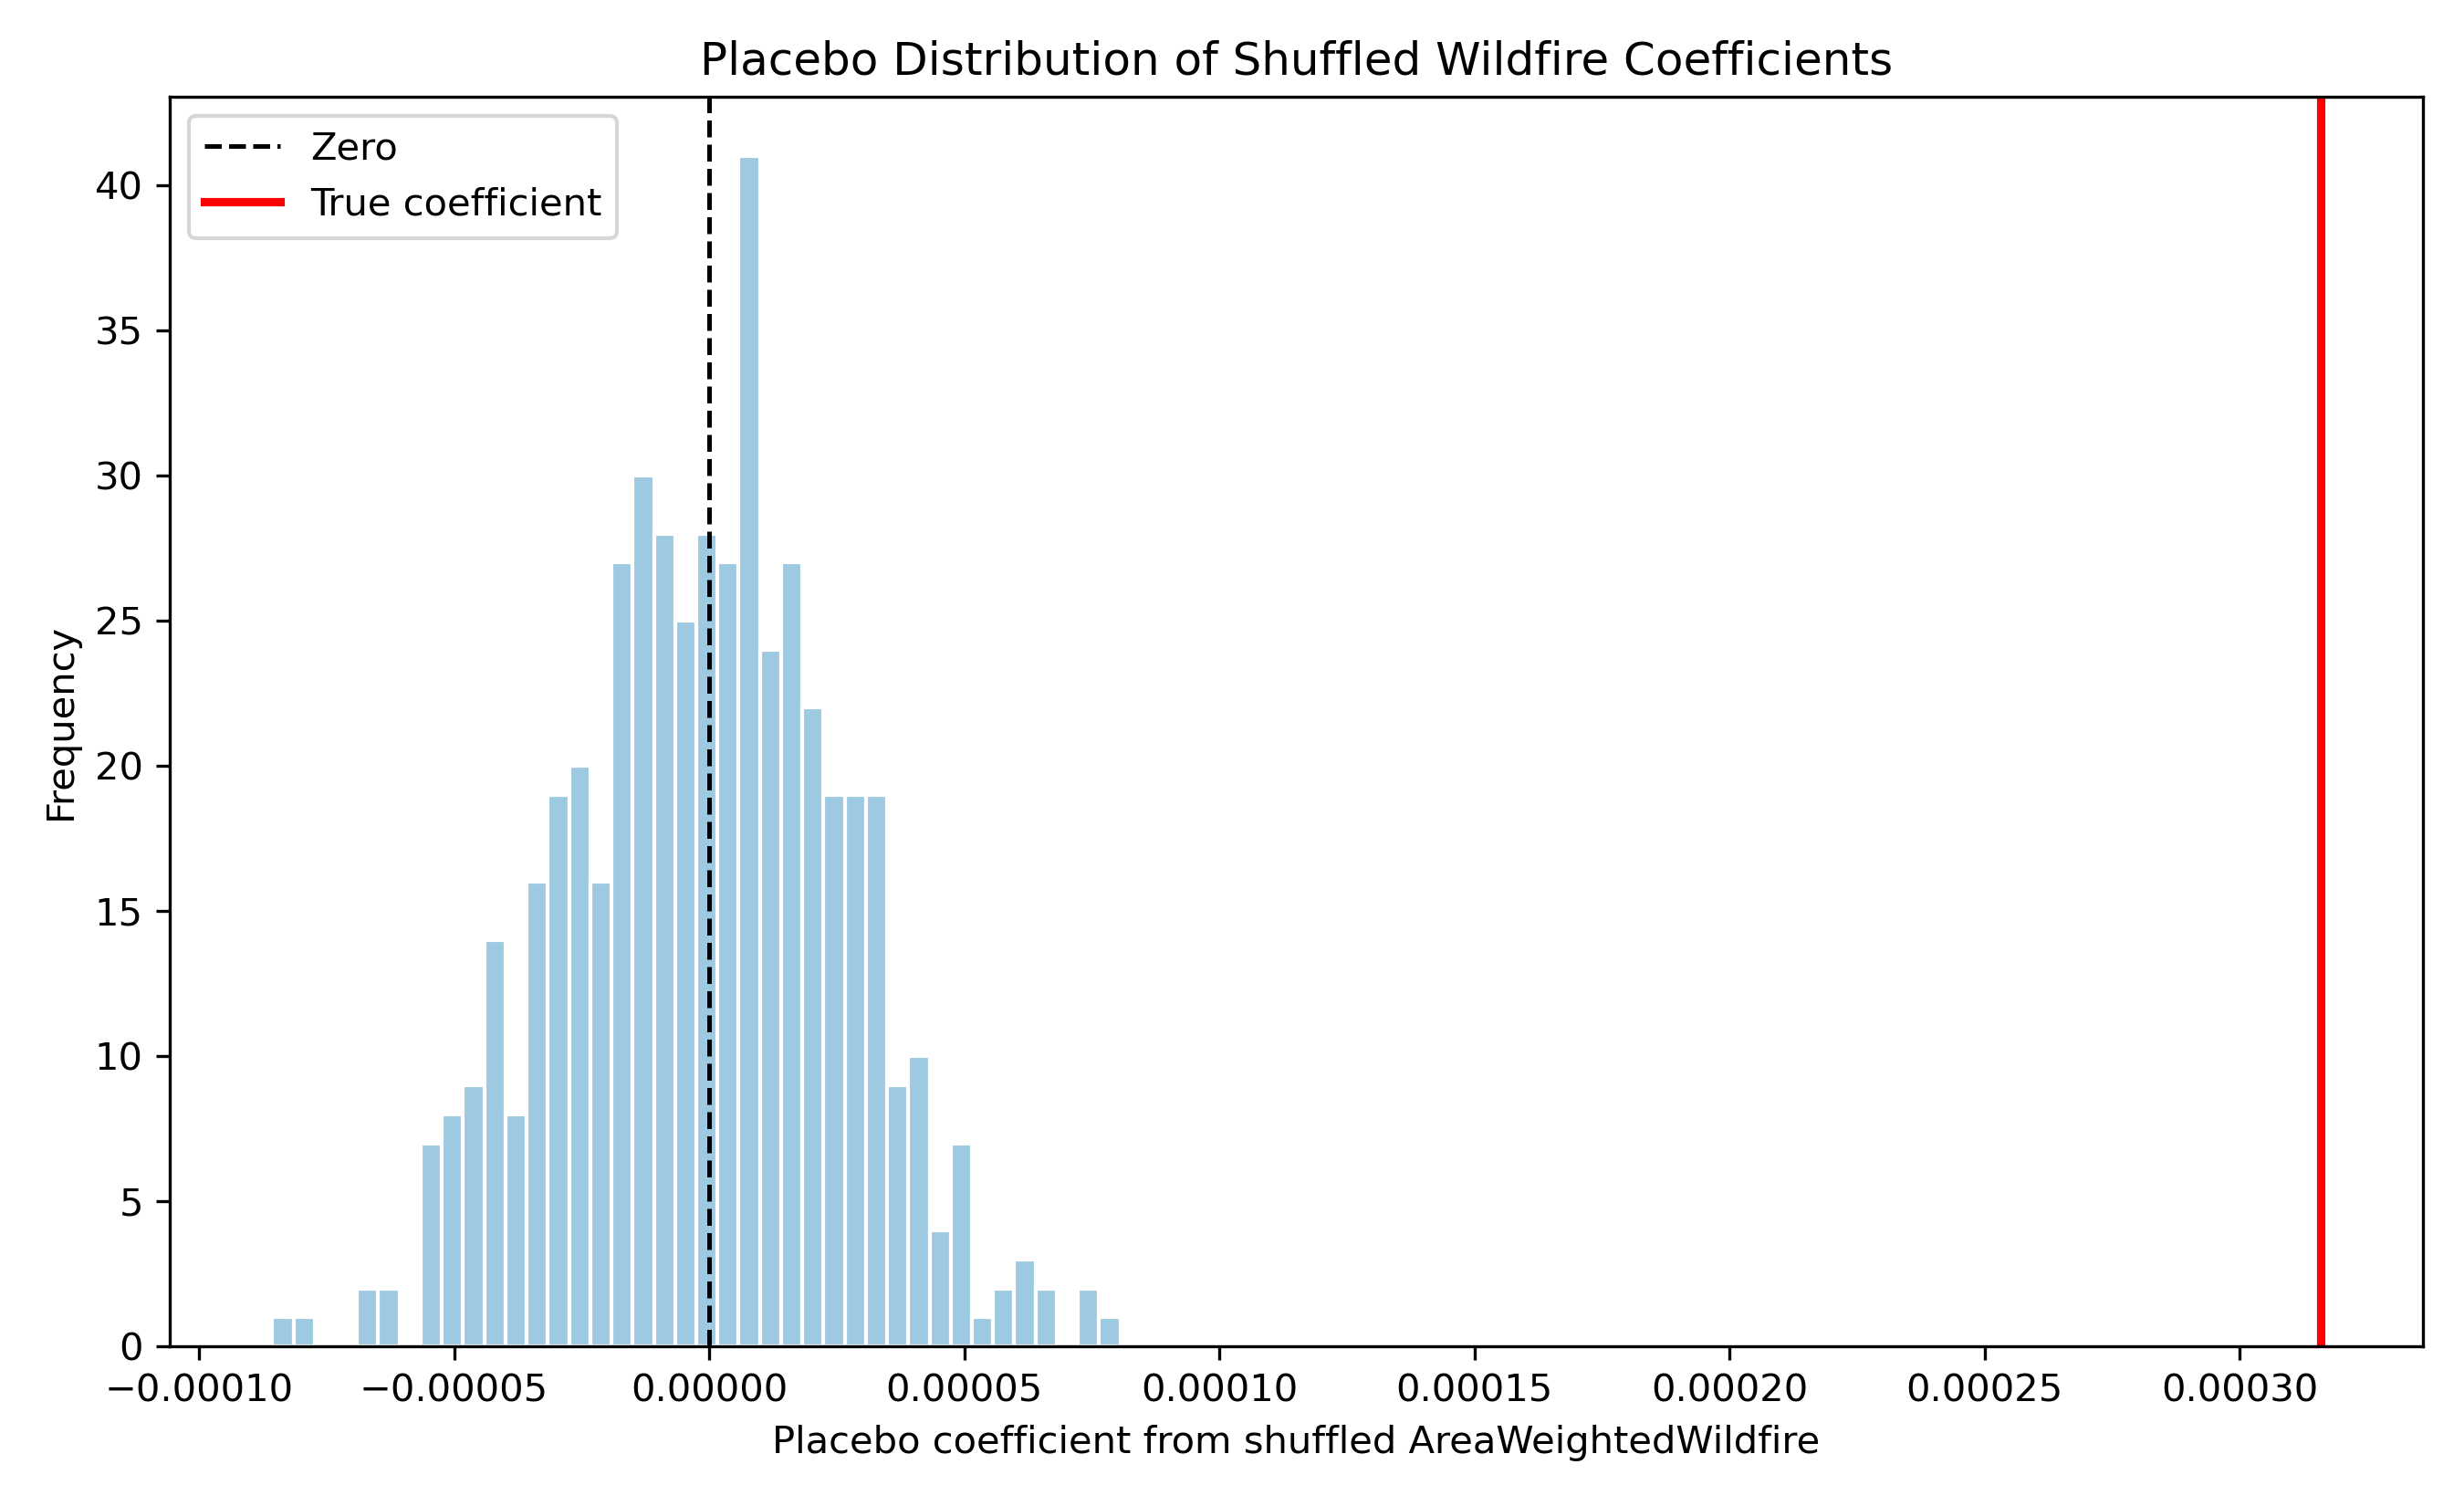

In [153]:
from IPython.display import Image

Image(
    "/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026/placebo_random_shuffle_ppml_histogram.png"
)


In [159]:
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

BASE_DIR = Path("/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026")

DATA_PATH = BASE_DIR / "county_month_replication_ready_temp_bins_income_agriculture_acs2010.csv"

OUT_RESULTS = BASE_DIR / "exact_models_1_to_5_ppmlhdfe_equivalent_results.csv"
OUT_FIRST_STAGE = BASE_DIR / "exact_model5_first_stage_reghdfe_equivalent.csv"

# ---------------- Controls ----------------
temp_bins = [
    "tmax_bin_lt32f",
    "tmax_bin_32_50f",
    # omitted/reference bin: tmax_bin_50_70f
    "tmax_bin_70_80f",
    "tmax_bin_80_90f",
    "tmax_bin_90_100f",
    "tmax_bin_ge100f",
]

main_controls = ["Sunshine"] + temp_bins + ["unemp_rate"]
controls = " + ".join(main_controls)

# Lagged controls for Model 4
lagged_controls = [f"{c}_lag1" for c in main_controls]
lagged_controls_formula = " + ".join(lagged_controls)

# Equivalent to absorb(county_id ym county_id#c.year)
fixed_effects = "C(county_id) + C(ym) + C(county_id):year"


def stars(p):
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""


# ---------------- Load data ----------------
df = pd.read_csv(DATA_PATH, low_memory=False)

needed_numeric = [
    "Fertility",
    "AreaWeightedWildfire",
    "AreaWeightedWildfire_lag1",
    "AreaWeightedWildfire_3mo_sum",
    "AirPollution",
    "county_id",
    "year",
    "month",
] + main_controls

for c in needed_numeric:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["county_id", "year", "month"]).copy()
df["county_id"] = df["county_id"].astype(int)
df["year"] = df["year"].astype(int)
df["month"] = df["month"].astype(int)

df["ym"] = df["year"].astype(str) + "_" + df["month"].astype(str).str.zfill(2)

# Sort before creating lags
df = df.sort_values(["county_id", "year", "month"]).copy()

# Create lagged controls for Model 4
for c in main_controls:
    df[f"{c}_lag1"] = df.groupby("county_id")[c].shift(1)


def fit_ppml(model_name, formula, data, keep_terms, extra_controls=None):
    if extra_controls is None:
        extra_controls = []

    reg_vars = (
        ["Fertility", "county_id", "ym", "year"]
        + keep_terms
        + main_controls
        + extra_controls
    )

    d = data.dropna(subset=list(dict.fromkeys(reg_vars))).copy()
    d = d[d["Fertility"] >= 0].copy()

    print(f"{model_name}: rows={len(d):,}, counties={d['county_id'].nunique():,}")

    res = smf.glm(
        formula=formula,
        data=d,
        family=sm.families.Poisson()
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": d["county_id"]},
        maxiter=200,
        disp=0
    )

    rows = []
    for term in keep_terms + main_controls + extra_controls:
        if term in res.params.index:
            rows.append({
                "model": model_name,
                "term": term,
                "coef": res.params[term],
                "std_error": res.bse[term],
                "z": res.tvalues[term],
                "p_value": res.pvalues[term],
                "stars": stars(res.pvalues[term]),
                "percent_effect": (np.exp(res.params[term]) - 1) * 100,
                "n_obs": int(res.nobs),
                "n_counties": d["county_id"].nunique()
            })

    return res, pd.DataFrame(rows)


# ============================================================
# Model 1
# Current area-weighted wildfire exposure
# ============================================================
m1_formula = f"""
Fertility ~ AreaWeightedWildfire
+ {controls}
+ {fixed_effects}
"""

m1, m1_table = fit_ppml(
    "Model 1",
    m1_formula,
    df,
    ["AreaWeightedWildfire"]
)


# ============================================================
# Model 2
# Current + lagged area-weighted wildfire exposure
# ============================================================
m2_formula = f"""
Fertility ~ AreaWeightedWildfire
+ AreaWeightedWildfire_lag1
+ {controls}
+ {fixed_effects}
"""

m2, m2_table = fit_ppml(
    "Model 2",
    m2_formula,
    df,
    ["AreaWeightedWildfire", "AreaWeightedWildfire_lag1"]
)


# ============================================================
# Model 3
# Current + 3-month cumulative area-weighted wildfire exposure
# ============================================================
m3_formula = f"""
Fertility ~ AreaWeightedWildfire
+ AreaWeightedWildfire_3mo_sum
+ {controls}
+ {fixed_effects}
"""

m3, m3_table = fit_ppml(
    "Model 3",
    m3_formula,
    df,
    ["AreaWeightedWildfire", "AreaWeightedWildfire_3mo_sum"]
)


# ============================================================
# Model 4
# Current wildfire + lagged wildfire + lagged controls
# ============================================================
m4_formula = f"""
Fertility ~ AreaWeightedWildfire
+ AreaWeightedWildfire_lag1
+ {controls}
+ {lagged_controls_formula}
+ {fixed_effects}
"""

m4, m4_table = fit_ppml(
    "Model 4",
    m4_formula,
    df,
    ["AreaWeightedWildfire", "AreaWeightedWildfire_lag1"],
    extra_controls=lagged_controls
)


# ============================================================
# Model 5
# Control-function model using AirPollution as instrument
# First stage: reghdfe equivalent
# ============================================================
first_stage_formula = f"""
AreaWeightedWildfire ~ AirPollution
+ {controls}
+ {fixed_effects}
"""

first_stage_vars = [
    "AreaWeightedWildfire",
    "AirPollution",
    "county_id",
    "ym",
    "year",
] + main_controls

first_df = df.dropna(subset=first_stage_vars).copy()

first_stage = smf.ols(
    formula=first_stage_formula,
    data=first_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": first_df["county_id"]}
)

df["area_wildfire_resid1"] = np.nan
df.loc[first_df.index, "area_wildfire_resid1"] = first_stage.resid

first_stage_table = pd.DataFrame([{
    "model": "Model 5 first stage",
    "term": "AirPollution",
    "coef": first_stage.params["AirPollution"],
    "std_error": first_stage.bse["AirPollution"],
    "t": first_stage.tvalues["AirPollution"],
    "p_value": first_stage.pvalues["AirPollution"],
    "stars": stars(first_stage.pvalues["AirPollution"]),
    "n_obs": int(first_stage.nobs),
    "n_counties": first_df["county_id"].nunique()
}])


# Second stage: PPML with first-stage residual
m5_formula = f"""
Fertility ~ AreaWeightedWildfire
+ area_wildfire_resid1
+ {controls}
+ {fixed_effects}
"""

m5, m5_table = fit_ppml(
    "Model 5",
    m5_formula,
    df,
    ["AreaWeightedWildfire", "area_wildfire_resid1"]
)


# ---------------- Combine and save results ----------------
results = pd.concat(
    [m1_table, m2_table, m3_table, m4_table, m5_table],
    ignore_index=True
)

results.to_csv(OUT_RESULTS, index=False)
first_stage_table.to_csv(OUT_FIRST_STAGE, index=False)

print("Saved:", OUT_RESULTS)
print("Saved:", OUT_FIRST_STAGE)


# ---------------- Show main wildfire results ----------------
main_terms = [
    "AreaWeightedWildfire",
    "AreaWeightedWildfire_lag1",
    "AreaWeightedWildfire_3mo_sum",
    "area_wildfire_resid1"
]

results[results["term"].isin(main_terms)]


Model 1: rows=20,955, counties=358
Model 2: rows=20,902, counties=358
Model 3: rows=20,849, counties=358
Model 4: rows=20,597, counties=358
Model 5: rows=20,955, counties=358
Saved: /Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026/exact_models_1_to_5_ppmlhdfe_equivalent_results.csv
Saved: /Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026/exact_model5_first_stage_reghdfe_equivalent.csv


,model,term,coef,std_error,z,p_value,stars,percent_effect,n_obs,n_counties
0,Model 1,AreaWeightedWildfire,0.000316,0.000070,4.524642,0.000006,***,0.031586,20955,358
9,Model 2,AreaWeightedWildfire,0.000241,0.000066,3.633840,0.000279,***,0.024078,20902,358
10,Model 2,AreaWeightedWildfire_lag1,0.000164,0.000051,3.213979,0.001309,***,0.016388,20902,358
19,Model 3,AreaWeightedWildfire,0.000106,0.000072,1.460826,0.144063,,0.010589,20849,358
20,Model 3,AreaWeightedWildfire_3mo_sum,0.000132,0.000032,4.077735,0.000045,***,0.013201,20849,358
29,Model 4,AreaWeightedWildfire,0.000198,0.000060,3.316925,0.000910,***,0.019776,20597,358
30,Model 4,AreaWeightedWildfire_lag1,0.000024,0.000047,0.507433,0.611851,,0.002381,20597,358
47,Model 5,AreaWeightedWildfire,0.000062,0.000203,0.303538,0.761480,,0.006176,20955,358
48,Model 5,area_wildfire_resid1,0.000292,0.000202,1.444718,0.148537,,0.029217,20955,358


# Fetility and Fertility Rate

In [76]:
import os
print(os.getcwd())

/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026


In [83]:
import pandas as pd

fertility_df = pd.read_csv(
    "/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026/merged_with_Fertility_lag10_plus_LAUS_fixed.csv",
    low_memory=False
)

fertility_rate = pd.read_csv(
    "/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026/State_year_level_FertilityRate.csv"
)

fertility_df.head()


,year,month,state_fips,state_fips_str,state_name,county_fips,county_fips_str,county_name,births,notes,pm25,aqi,n_obs,smoke_days,area_weighted_smoke_days,merge_method,mean_ghi_wm2,total_ghi_kwh_m2,sunshine_hours_proxy,n_files,Fertility,employed,labor_force,unemp_rate,unemployed
0,2022,1,1.0,1.0,Alabama,1001.0,1001.0,Autauga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.985215,90.757,207.0,0.0,NaN,26304.0,27012.0,2.6,708.0
1,2022,2,1.0,1.0,Alabama,1001.0,1001.0,Autauga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,148.910714,100.068,218.0,0.0,NaN,26394.0,27045.0,2.4,651.0
2,2022,3,1.0,1.0,Alabama,1001.0,1001.0,Autauga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,210.051075,156.278,282.0,0.0,NaN,26521.0,27090.0,2.1,569.0
3,2022,4,1.0,1.0,Alabama,1001.0,1001.0,Autauga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,240.684722,173.293,295.0,0.0,NaN,26526.0,26995.0,1.7,469.0
4,2022,5,1.0,1.0,Alabama,1001.0,1001.0,Autauga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,282.560484,210.225,344.0,0.0,NaN,26541.0,27057.0,1.9,516.0


In [84]:
# Map abbreviations to full names
us_states = {
    "AL":"Alabama","AK":"Alaska","AZ":"Arizona","AR":"Arkansas","CA":"California",
    "CO":"Colorado","CT":"Connecticut","DE":"Delaware","FL":"Florida","GA":"Georgia",
    "HI":"Hawaii","ID":"Idaho","IL":"Illinois","IN":"Indiana","IA":"Iowa",
    "KS":"Kansas","KY":"Kentucky","LA":"Louisiana","ME":"Maine","MD":"Maryland",
    "MA":"Massachusetts","MI":"Michigan","MN":"Minnesota","MS":"Mississippi","MO":"Missouri",
    "MT":"Montana","NE":"Nebraska","NV":"Nevada","NH":"New Hampshire","NJ":"New Jersey",
    "NM":"New Mexico","NY":"New York","NC":"North Carolina","ND":"North Dakota","OH":"Ohio",
    "OK":"Oklahoma","OR":"Oregon","PA":"Pennsylvania","RI":"Rhode Island","SC":"South Carolina",
    "SD":"South Dakota","TN":"Tennessee","TX":"Texas","UT":"Utah","VT":"Vermont",
    "VA":"Virginia","WA":"Washington","WV":"West Virginia","WI":"Wisconsin","WY":"Wyoming"
}

fertility_rate ["state"] = fertility_rate["Location"].map(us_states)
fertility_rate

,YEAR,Location,Fertility rate,Births,URL,state
0,2023,AL,57.9,57858,/nchs/pressroom/states/alabama/al.htm,Alabama
1,2023,AK,62.4,9015,/nchs/pressroom/states/alaska/ak.htm,Alaska
2,2023,AZ,54.2,78096,/nchs/pressroom/states/arizona/az.htm,Arizona
3,2023,AR,59.2,35264,/nchs/pressroom/states/arkansas/ar.htm,Arkansas
4,2023,CA,50.4,400108,/nchs/pressroom/states/california/ca.htm,California
5,2023,CO,50.2,61494,/nchs/pressroom/states/colorado/co.htm,Colorado
6,2023,CT,50.2,34559,/nchs/pressroom/states/connecticut/ct.htm,Connecticut
7,2023,DE,54.4,10427,/nchs/pressroom/states/DC/DC1.htm,Delaware
8,2023,District of Columbia,43.0,7896,/nchs/pressroom/states/delaware/de.htm,NaN
9,2023,FL,53.9,221410,/nchs/pressroom/states/florida/fl.htm,Florida


In [85]:
fertility_rate["year"] = fertility_rate["YEAR"]
fertility_rate["state_name"] = fertility_rate["state"]

In [86]:
fertility_df = fertility_df[(fertility_df["year"] >= 2015) & (fertility_df["year"] <= 2023)]
fertility_rate = fertility_rate[(fertility_rate["year"] >= 2015) & (fertility_rate["year"] <= 2023)]
fertility_rate

,YEAR,Location,Fertility rate,Births,URL,state,year,state_name
0,2023,AL,57.9,57858,/nchs/pressroom/states/alabama/al.htm,Alabama,2023,Alabama
1,2023,AK,62.4,9015,/nchs/pressroom/states/alaska/ak.htm,Alaska,2023,Alaska
2,2023,AZ,54.2,78096,/nchs/pressroom/states/arizona/az.htm,Arizona,2023,Arizona
3,2023,AR,59.2,35264,/nchs/pressroom/states/arkansas/ar.htm,Arkansas,2023,Arkansas
4,2023,CA,50.4,400108,/nchs/pressroom/states/california/ca.htm,California,2023,California
5,2023,CO,50.2,61494,/nchs/pressroom/states/colorado/co.htm,Colorado,2023,Colorado
6,2023,CT,50.2,34559,/nchs/pressroom/states/connecticut/ct.htm,Connecticut,2023,Connecticut
7,2023,DE,54.4,10427,/nchs/pressroom/states/DC/DC1.htm,Delaware,2023,Delaware
8,2023,District of Columbia,43.0,7896,/nchs/pressroom/states/delaware/de.htm,NaN,2023,NaN
9,2023,FL,53.9,221410,/nchs/pressroom/states/florida/fl.htm,Florida,2023,Florida


In [12]:
fertility_state = fertility_df.groupby(["year", "month", "state_name"], as_index=False)["Fertility"].sum()
fertility_state

,year,month,state_name,Fertility
0,2015,1,Alabama,5129.0
1,2015,1,Alaska,925.0
2,2015,1,Arizona,7518.0
3,2015,1,Arkansas,3296.0
4,2015,1,California,41997.0
...,...,...,...,...
5678,2023,12,Virginia,0.0
5679,2023,12,Washington,0.0
5680,2023,12,West Virginia,0.0
5681,2023,12,Wisconsin,0.0


In [16]:
# Load files (update paths)
pop_2010_2023 = pd.read_excel("state_population_2010_2023.xlsx")

print(pop_2010_2023.columns)

Index(['sumlev', 'region', 'division', 'state_fips', 'state_name', 'year',
       'population_estimate', 'numeric_population_change',
       'percent_population_change', 'estimates_base_year', 'estimates_base',
       'source_vintage'],
      dtype='object')


In [93]:
import pandas as pd

pop_2010_2023 = pd.read_csv(
    "/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026/state_population_2010_2023.csv"
)

pop_2010_2023.to_excel("pop_df.xlsx", index=False)



In [94]:
import pandas as pd

# Load fertility data
fertility_df = pd.read_csv(
    "/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026/merged_with_Fertility_lag10_plus_LAUS_fixed.csv",
    low_memory=False
)

# Create state-year fertility total
fertility_state = (
    fertility_df
    .groupby(["year", "state_name"], as_index=False)["Fertility"]
    .sum()
)

fertility_state.head()


,year,state_name,Fertility
0,2010,Alabama,59650.0
1,2010,Alaska,11566.0
2,2010,Arizona,85861.0
3,2010,Arkansas,38643.0
4,2010,California,507296.0


In [95]:
fertility_rate = pd.read_csv(
    "/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026/State_year_level_FertilityRate.csv"
)

fertility_rate = fertility_rate.rename(columns={
    "YEAR": "year",
    "Fertility rate": "Fertility rate"
})

state_abbrev_to_name = {
    "AL": "Alabama", "AK": "Alaska", "AZ": "Arizona", "AR": "Arkansas",
    "CA": "California", "CO": "Colorado", "CT": "Connecticut", "DE": "Delaware",
    "FL": "Florida", "GA": "Georgia", "HI": "Hawaii", "ID": "Idaho",
    "IL": "Illinois", "IN": "Indiana", "IA": "Iowa", "KS": "Kansas",
    "KY": "Kentucky", "LA": "Louisiana", "ME": "Maine", "MD": "Maryland",
    "MA": "Massachusetts", "MI": "Michigan", "MN": "Minnesota", "MS": "Mississippi",
    "MO": "Missouri", "MT": "Montana", "NE": "Nebraska", "NV": "Nevada",
    "NH": "New Hampshire", "NJ": "New Jersey", "NM": "New Mexico", "NY": "New York",
    "NC": "North Carolina", "ND": "North Dakota", "OH": "Ohio", "OK": "Oklahoma",
    "OR": "Oregon", "PA": "Pennsylvania", "RI": "Rhode Island", "SC": "South Carolina",
    "SD": "South Dakota", "TN": "Tennessee", "TX": "Texas", "UT": "Utah",
    "VT": "Vermont", "VA": "Virginia", "WA": "Washington", "WV": "West Virginia",
    "WI": "Wisconsin", "WY": "Wyoming"
}

fertility_rate["state_name"] = fertility_rate["Location"].map(state_abbrev_to_name)
fertility_rate["year"] = pd.to_numeric(fertility_rate["year"], errors="coerce")

fertility_rate.head()


,year,Location,Fertility rate,Births,URL,state_name
0,2023,AL,57.9,57858,/nchs/pressroom/states/alabama/al.htm,Alabama
1,2023,AK,62.4,9015,/nchs/pressroom/states/alaska/ak.htm,Alaska
2,2023,AZ,54.2,78096,/nchs/pressroom/states/arizona/az.htm,Arizona
3,2023,AR,59.2,35264,/nchs/pressroom/states/arkansas/ar.htm,Arkansas
4,2023,CA,50.4,400108,/nchs/pressroom/states/california/ca.htm,California


In [96]:
merged_df = pd.merge(
    fertility_state,
    fertility_rate[["year", "state_name", "Fertility rate"]],
    on=["year", "state_name"],
    how="inner"
)

merged_df.head()


,year,state_name,Fertility,Fertility rate
0,2014,Alabama,59909.0,61.8
1,2014,Alaska,11350.0,77.3
2,2014,Arizona,85758.0,66.4
3,2014,Arkansas,39047.0,67.0
4,2014,California,496293.0,62.4


In [97]:
import pandas as pd

# Fertility data
merged_df = pd.read_excel("merged_df.xlsx")

# Population data: state-year level, 2010-2023
pop = pd.read_csv("state_population_2010_2023.csv")

# Keep only needed population columns
pop_state_year = pop[[
    "year",
    "state_name",
    "population_estimate"
]].copy()

# Convert monthly fertility data to state-year level
# Fertility rate is annual/state-level, so use mean across months.
fertility_state_year = (
    merged_df
    .groupby(["year", "state_name"], as_index=False)
    .agg({
        "Fertility rate": "mean",
        "Fertility": "sum"
    })
)

# Merge fertility rate with population
fertility_pop = fertility_state_year.merge(
    pop_state_year,
    on=["year", "state_name"],
    how="left"
)

# Create fertility rate * population
fertility_pop["fertility_rate_x_population_div_1000"] = (
    (fertility_pop["Fertility rate"] / 1000) * fertility_pop["population_estimate"]
)

fertility_pop.head()

,year,state_name,Fertility rate,Fertility,population_estimate,fertility_rate_x_population_div_1000
0,2015,Alabama,62.2,59560,4854803,3.019687e+05
1,2015,Alaska,77.0,11192,738430,5.685911e+04
2,2015,Arizona,64.7,85031,6832810,4.420828e+05
3,2015,Arkansas,67.5,38692,2979732,2.011319e+05
4,2015,California,60.8,489025,38904296,2.365381e+06


In [30]:
fertility_pop.to_excel("fertility_pop.xlsx", index=False)

In [99]:
import pandas as pd
import numpy as np
from pathlib import Path

# ---------------- Paths ----------------
BASE_DIR = Path("/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026")

FERTILITY_RATE_PATH = BASE_DIR / "State_year_level_FertilityRate.csv"
POPULATION_PATH = BASE_DIR / "state_population_2010_2023.csv"
WOMEN_15_44_PATH = BASE_DIR / "women_15_44_state_2010_2023.csv"

OUT_CSV = BASE_DIR / "fertility_with_women_15_44_corrected_proxy.csv"
OUT_XLSX = BASE_DIR / "fertility_with_women_15_44_corrected_proxy.xlsx"

START_YEAR = 2015
END_YEAR = 2023

# ---------------- State abbreviations ----------------
state_abbrev_to_name = {
    "AL": "Alabama", "AK": "Alaska", "AZ": "Arizona", "AR": "Arkansas",
    "CA": "California", "CO": "Colorado", "CT": "Connecticut", "DE": "Delaware",
    "FL": "Florida", "GA": "Georgia", "HI": "Hawaii", "ID": "Idaho",
    "IL": "Illinois", "IN": "Indiana", "IA": "Iowa", "KS": "Kansas",
    "KY": "Kentucky", "LA": "Louisiana", "ME": "Maine", "MD": "Maryland",
    "MA": "Massachusetts", "MI": "Michigan", "MN": "Minnesota", "MS": "Mississippi",
    "MO": "Missouri", "MT": "Montana", "NE": "Nebraska", "NV": "Nevada",
    "NH": "New Hampshire", "NJ": "New Jersey", "NM": "New Mexico", "NY": "New York",
    "NC": "North Carolina", "ND": "North Dakota", "OH": "Ohio", "OK": "Oklahoma",
    "OR": "Oregon", "PA": "Pennsylvania", "RI": "Rhode Island", "SC": "South Carolina",
    "SD": "South Dakota", "TN": "Tennessee", "TX": "Texas", "UT": "Utah",
    "VT": "Vermont", "VA": "Virginia", "WA": "Washington", "WV": "West Virginia",
    "WI": "Wisconsin", "WY": "Wyoming"
}

state_name_to_fips = {
    "Alabama": 1, "Alaska": 2, "Arizona": 4, "Arkansas": 5,
    "California": 6, "Colorado": 8, "Connecticut": 9, "Delaware": 10,
    "Florida": 12, "Georgia": 13, "Hawaii": 15, "Idaho": 16,
    "Illinois": 17, "Indiana": 18, "Iowa": 19, "Kansas": 20,
    "Kentucky": 21, "Louisiana": 22, "Maine": 23, "Maryland": 24,
    "Massachusetts": 25, "Michigan": 26, "Minnesota": 27, "Mississippi": 28,
    "Missouri": 29, "Montana": 30, "Nebraska": 31, "Nevada": 32,
    "New Hampshire": 33, "New Jersey": 34, "New Mexico": 35, "New York": 36,
    "North Carolina": 37, "North Dakota": 38, "Ohio": 39, "Oklahoma": 40,
    "Oregon": 41, "Pennsylvania": 42, "Rhode Island": 44, "South Carolina": 45,
    "South Dakota": 46, "Tennessee": 47, "Texas": 48, "Utah": 49,
    "Vermont": 50, "Virginia": 51, "Washington": 53, "West Virginia": 54,
    "Wisconsin": 55, "Wyoming": 56
}

# ---------------- Load fertility rate data ----------------
fert = pd.read_csv(FERTILITY_RATE_PATH)

fert = fert.rename(columns={
    "YEAR": "year",
    "Location": "state_abbrev",
    "Fertility rate": "fertility_rate",
    "Births": "fertility"
})

fert["year"] = pd.to_numeric(fert["year"], errors="coerce").astype("Int64")
fert["fertility_rate"] = pd.to_numeric(fert["fertility_rate"], errors="coerce")
fert["fertility"] = pd.to_numeric(fert["fertility"], errors="coerce")

fert["state_name"] = fert["state_abbrev"].map(state_abbrev_to_name)
fert["state_fips"] = fert["state_name"].map(state_name_to_fips)

fert = fert[
    (fert["year"] >= START_YEAR) &
    (fert["year"] <= END_YEAR)
].copy()

fert = fert.dropna(subset=[
    "year", "state_name", "state_fips", "fertility_rate", "fertility"
])

fert["year"] = fert["year"].astype(int)
fert["state_fips"] = fert["state_fips"].astype(int)

# ---------------- Load total state population ----------------
pop = pd.read_csv(POPULATION_PATH)

pop["year"] = pd.to_numeric(pop["year"], errors="coerce").astype("Int64")
pop["state_fips"] = pd.to_numeric(pop["state_fips"], errors="coerce").astype("Int64")
pop["population_estimate"] = pd.to_numeric(
    pop["population_estimate"],
    errors="coerce"
)

pop = pop[
    ["state_fips", "state_name", "year", "population_estimate"]
].dropna().copy()

pop["year"] = pop["year"].astype(int)
pop["state_fips"] = pop["state_fips"].astype(int)

# ---------------- Load women ages 15-44 ----------------
women = pd.read_csv(WOMEN_15_44_PATH)

women["year"] = pd.to_numeric(women["year"], errors="coerce").astype("Int64")
women["state_fips"] = pd.to_numeric(women["state_fips"], errors="coerce").astype("Int64")
women["women_15_44"] = pd.to_numeric(women["women_15_44"], errors="coerce")

women = women[
    ["state_fips", "state_name", "year", "women_15_44"]
].dropna().copy()

women["year"] = women["year"].astype(int)
women["state_fips"] = women["state_fips"].astype(int)

# ---------------- Merge datasets ----------------
merged = fert.merge(
    pop[["state_fips", "year", "population_estimate"]],
    on=["state_fips", "year"],
    how="left",
    validate="m:1"
)

merged = merged.merge(
    women[["state_fips", "year", "women_15_44"]],
    on=["state_fips", "year"],
    how="left",
    validate="m:1"
)

# ---------------- Create old and corrected fertility proxies ----------------
# Old proxy: incorrect denominator because fertility rate is NOT per total population
merged["fertility_rate_x_population_div_1000"] = (
    merged["fertility_rate"] / 1000 * merged["population_estimate"]
)

# Correct proxy: fertility rate is births per 1,000 women ages 15-44
merged["implied_births_correct"] = (
    merged["fertility_rate"] / 1000 * merged["women_15_44"]
)

merged["old_proxy"] = merged["fertility_rate_x_population_div_1000"]

merged["ratio_fertility_to_old_proxy"] = (
    merged["fertility"] / merged["old_proxy"]
)

merged["ratio_fertility_to_correct_proxy"] = (
    merged["fertility"] / merged["implied_births_correct"]
)

# ---------------- Final column order ----------------
final_cols = [
    "year",
    "state_name",
    "fertility_rate",
    "fertility",
    "population_estimate",
    "fertility_rate_x_population_div_1000",
    "state_fips",
    "women_15_44",
    "implied_births_correct",
    "old_proxy",
    "ratio_fertility_to_old_proxy",
    "ratio_fertility_to_correct_proxy"
]

merged = merged[final_cols].sort_values(["year", "state_name"]).reset_index(drop=True)

# ---------------- Save outputs ----------------
merged.to_csv(OUT_CSV, index=False)
merged.to_excel(OUT_XLSX, index=False)

print("Saved CSV:", OUT_CSV)
print("Saved Excel:", OUT_XLSX)
print("Rows:", len(merged))
print("Years:", merged["year"].min(), "to", merged["year"].max())
print("States:", merged["state_name"].nunique())

print("\nCheck ratios:")
print(
    merged[
        ["ratio_fertility_to_old_proxy", "ratio_fertility_to_correct_proxy"]
    ].describe()
)

merged.head()


Saved CSV: /Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026/fertility_with_women_15_44_corrected_proxy.csv
Saved Excel: /Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026/fertility_with_women_15_44_corrected_proxy.xlsx
Rows: 450
Years: 2015 to 2023
States: 50

Check ratios:
       ratio_fertility_to_old_proxy  ratio_fertility_to_correct_proxy
count                    450.000000                        450.000000
mean                       0.193070                          0.999230
std                        0.008626                          0.013704
min                        0.138235                          0.743283
25%                        0.188241                          0.999023
50%                        0.193246                          1.000018
75%                        0.197617                          1.001521
max                        0.221010                          1.037143


,year,state_name,fertility_rate,fertility,population_estimate,fertility_rate_x_population_div_1000,state_fips,women_15_44,implied_births_correct,old_proxy,ratio_fertility_to_old_proxy,ratio_fertility_to_correct_proxy
0,2015,Alabama,62.2,59657,4854803,3.019687e+05,1,956592,59500.0224,3.019687e+05,0.197560,1.002638
1,2015,Alaska,77.0,11282,738430,5.685911e+04,2,146494,11280.0380,5.685911e+04,0.198420,1.000174
2,2015,Arizona,64.7,85351,6832810,4.420828e+05,4,1324531,85697.1557,4.420828e+05,0.193066,0.995961
3,2015,Arkansas,67.5,38886,2979732,2.011319e+05,5,576825,38935.6875,2.011319e+05,0.193336,0.998724
4,2015,California,60.8,491748,38904296,2.365381e+06,6,8046266,489212.9728,2.365381e+06,0.207894,1.005182


Rows: 400
States: 50
Years: 2015 to 2022

1. Correlation
Correlation: 0.9999595630526786
p-value: 0.0
Observations: 400

2. Ratio check
count    400.000000
mean       0.999142
std        0.014534
min        0.743283
1%         0.971738
5%         0.990413
10%        0.994069
25%        0.998663
50%        1.000100
75%        1.001913
90%        1.004894
95%        1.007675
99%        1.016693
max        1.037143
Name: ratio_fertility_implied, dtype: float64

3. Difference check: raw difference
count     400.000000
mean        6.522254
std       779.844739
min     -8846.439200
1%      -2310.440783
5%       -566.256010
10%      -291.744880
25%       -73.355950
50%         1.971100
75%        78.010675
90%       339.052700
95%       531.988110
99%      2756.165298
max      4723.776600
Name: diff_fertility_implied, dtype: float64

3. Difference check: percent difference
count    400.000000
mean      -0.112738
std        1.859291
min      -34.538271
1%        -2.908538
5%        -0.967941
1

/Users/dipanwitabarai/opt/anaconda3/envs/geo/lib/python3.10/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 50, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/Users/dipanwitabarai/opt/anaconda3/envs/geo/lib/python3.10/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 57, but rank is 8
  warnings.warn('covariance of constraints does not have full '


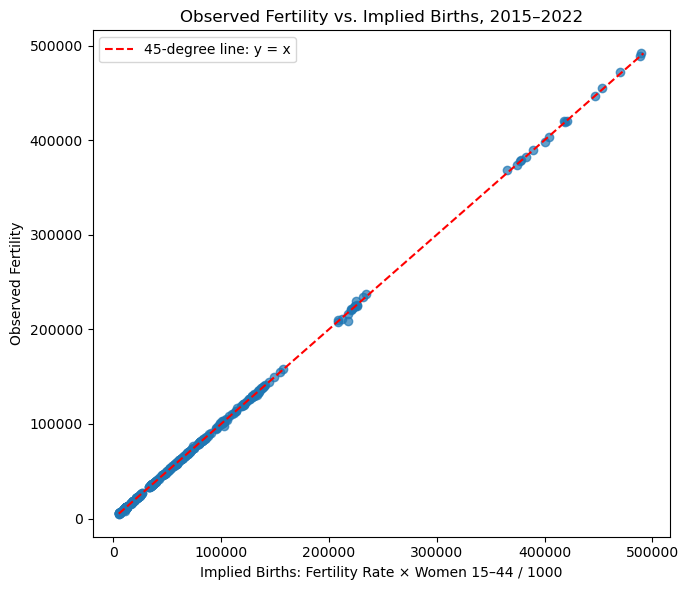

In [100]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt

# ---------------- Load data ----------------
df = pd.read_csv(
    "/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026/fertility_with_women_15_44_corrected_proxy.csv"
)

# ---------------- Use comparable full-year period ----------------
df = df[df["year"] <= 2022].copy()

# Make sure variables are numeric
for col in ["fertility", "implied_births_correct", "state_fips", "year"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=[
    "fertility",
    "implied_births_correct",
    "state_fips",
    "year"
]).copy()

df["state_fips"] = df["state_fips"].astype(int)
df["year"] = df["year"].astype(int)

print("Rows:", len(df))
print("States:", df["state_fips"].nunique())
print("Years:", df["year"].min(), "to", df["year"].max())

# ============================================================
# 1. Correlation
# Stata: pwcorr fertility implied_births_correct, sig obs
# ============================================================

corr, pval = stats.pearsonr(
    df["fertility"],
    df["implied_births_correct"]
)

print("\n1. Correlation")
print("Correlation:", corr)
print("p-value:", pval)
print("Observations:", len(df))

# ============================================================
# 2. Ratio check
# Stata:
# gen ratio_fertility_implied = fertility / implied_births_correct
# summ ratio_fertility_implied, detail
# ============================================================

df["ratio_fertility_implied"] = (
    df["fertility"] / df["implied_births_correct"]
)

print("\n2. Ratio check")
print(df["ratio_fertility_implied"].describe(percentiles=[
    .01, .05, .10, .25, .50, .75, .90, .95, .99
]))

# ============================================================
# 3. Difference check
# Stata:
# gen diff_fertility_implied = fertility - implied_births_correct
# gen pct_diff_fertility_implied = 100 * diff_fertility_implied / fertility
# summ diff_fertility_implied pct_diff_fertility_implied, detail
# ============================================================

df["diff_fertility_implied"] = (
    df["fertility"] - df["implied_births_correct"]
)

df["pct_diff_fertility_implied"] = (
    100 * df["diff_fertility_implied"] / df["fertility"]
)

print("\n3. Difference check: raw difference")
print(df["diff_fertility_implied"].describe(percentiles=[
    .01, .05, .10, .25, .50, .75, .90, .95, .99
]))

print("\n3. Difference check: percent difference")
print(df["pct_diff_fertility_implied"].describe(percentiles=[
    .01, .05, .10, .25, .50, .75, .90, .95, .99
]))

# ============================================================
# Helper function for regression output and test beta = 1
# ============================================================

def run_model(name, formula, data):
    model = smf.ols(
        formula=formula,
        data=data
    )

    res = model.fit(
        cov_type="cluster",
        cov_kwds={"groups": data["state_fips"]}
    )

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print(res.summary())

    beta = res.params["implied_births_correct"]
    se = res.bse["implied_births_correct"]

    # Test H0: beta = 1
    t_stat = (beta - 1) / se
    df_resid = data["state_fips"].nunique() - 1
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=df_resid))

    print("\nTest H0: implied_births_correct coefficient = 1")
    print("beta:", beta)
    print("std error:", se)
    print("t-stat:", t_stat)
    print("cluster df:", df_resid)
    print("p-value:", p_value)

    return res

# ============================================================
# 4. Simple regression
# Stata:
# reg fertility implied_births_correct, vce(cluster state_fips)
# test implied_births_correct = 1
# ============================================================

m1 = run_model(
    "4. Simple regression",
    "fertility ~ implied_births_correct",
    df
)

# ============================================================
# 5. State fixed effects
# Stata:
# reghdfe fertility implied_births_correct, absorb(state_fips) vce(cluster state_fips)
# test implied_births_correct = 1
# ============================================================

m2 = run_model(
    "5. State fixed effects",
    "fertility ~ implied_births_correct + C(state_fips)",
    df
)

# ============================================================
# 6. State and year fixed effects
# Stata:
# reghdfe fertility implied_births_correct, absorb(state_fips year) vce(cluster state_fips)
# test implied_births_correct = 1
# ============================================================

m3 = run_model(
    "6. State and year fixed effects",
    "fertility ~ implied_births_correct + C(state_fips) + C(year)",
    df
)

# ============================================================
# 7. Visual validation
# Stata:
# twoway scatter + y=x line
# ============================================================

plt.figure(figsize=(7, 6))

plt.scatter(
    df["implied_births_correct"],
    df["fertility"],
    alpha=0.7
)

min_val = min(df["implied_births_correct"].min(), df["fertility"].min())
max_val = max(df["implied_births_correct"].max(), df["fertility"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="red",
    label="45-degree line: y = x"
)

plt.xlabel("Implied Births: Fertility Rate × Women 15–44 / 1000")
plt.ylabel("Observed Fertility")
plt.title("Observed Fertility vs. Implied Births, 2015–2022")
plt.legend()
plt.tight_layout()

plt.savefig(
    "/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026/fertility_vs_implied_births_2015_2022.png",
    dpi=300
)

plt.show()


In [102]:
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats

# ---------------- Load data ----------------
df = pd.read_csv(
    "/Users/dipanwitabarai/Google Drive/UNH/Research/Health_Fertility_AirPollution/AAEA_2026/fertility_with_women_15_44_corrected_proxy.csv"
)

# ---------------- Keep comparable period ----------------
df = df[df["year"] <= 2022].copy()

# ---------------- Clean variables ----------------
for col in ["fertility", "implied_births_correct", "state_fips", "year"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=[
    "fertility",
    "implied_births_correct",
    "state_fips",
    "year"
]).copy()

df["state_fips"] = df["state_fips"].astype(int)
df["year"] = df["year"].astype(int)

print("Rows:", len(df))
print("States:", df["state_fips"].nunique())
print("Years:", df["year"].min(), "to", df["year"].max())

# ---------------- State + year fixed effects ----------------
# Stata equivalent:
# reghdfe fertility implied_births_correct, absorb(state_fips year) vce(cluster state_fips)

model = smf.ols(
    "fertility ~ implied_births_correct + C(state_fips) + C(year)",
    data=df
)

res = model.fit(
    cov_type="cluster",
    cov_kwds={"groups": df["state_fips"]}
)

print(res.summary())

# ---------------- Extract coefficient table for implied_births_correct ----------------
coef = res.params["implied_births_correct"]
se = res.bse["implied_births_correct"]
t_stat = res.tvalues["implied_births_correct"]
p_value = res.pvalues["implied_births_correct"]
ci_low, ci_high = res.conf_int().loc["implied_births_correct"]

print("\nMain coefficient:")
print("Coefficient:", coef)
print("Std. error:", se)
print("t-stat:", t_stat)
print("p-value:", p_value)
print("95% CI:", ci_low, "to", ci_high)

# ---------------- Test coefficient = 1 ----------------
# Stata equivalent:
# test implied_births_correct = 1

cluster_df = df["state_fips"].nunique() - 1
t_test_1 = (coef - 1) / se
p_test_1 = 2 * (1 - stats.t.cdf(abs(t_test_1), df=cluster_df))

print("\nTest H0: implied_births_correct = 1")
print("t-stat:", t_test_1)
print("df:", cluster_df)
print("p-value:", p_test_1)


Rows: 400
States: 50
Years: 2015 to 2022
                            OLS Regression Results                            
Dep. Variable:              fertility   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                     3.668
Date:                Mon, 18 May 2026   Prob (F-statistic):            0.00202
Time:                        17:14:21   Log-Likelihood:                -3208.3
No. Observations:                 400   AIC:                             6533.
Df Residuals:                     342   BIC:                             6764.
Df Model:                          57                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

/Users/dipanwitabarai/opt/anaconda3/envs/geo/lib/python3.10/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 57, but rank is 8
  warnings.warn('covariance of constraints does not have full '


In [103]:
result_table = pd.DataFrame({
    "term": ["implied_births_correct"],
    "coefficient": [coef],
    "std_error": [se],
    "t_stat": [t_stat],
    "p_value": [p_value],
    "ci_low": [ci_low],
    "ci_high": [ci_high],
    "test_coef_equals_1_t": [t_test_1],
    "test_coef_equals_1_p": [p_test_1]
})

result_table


,term,coefficient,std_error,t_stat,p_value,ci_low,ci_high,test_coef_equals_1_t,test_coef_equals_1_p
0,implied_births_correct,1.000682,0.019244,51.998705,0.0,0.962964,1.038401,0.035451,0.971864
